## Import

In [1]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import GridSearchCV 

from sklearn.metrics import make_scorer
from ML.utils.utils import max_error_single, gaussian

import pandas as pd

In [2]:
from ML.utils.utils import *
from ML.utils.Data_preparator import Data_preparator
from ML.utils.Model_evaluator import Model_evaluator
from physics.Iso_data_handler import Iso_data_handler

In [3]:
pre_path = "../../../../../../"
physical_model = "PARSEC"
path_to_data = pre_path + "data/PARSEC/"
path_to_results = pre_path + "results/model_A_partial/fine_tuned_models/"
path_to_predictions = pre_path + "predictions/model_A_partial/fine_tuned_models/"
output_parameters = ["mass", "radius"]
categories_name = ["label"]
scoring = ["neg_root_mean_squared_error", "neg_mean_absolute_error"] # RMSE and MAE
max_err_scorer = make_scorer(max_error_single, greater_is_better=False)

In [25]:
override = True
use_preds = False
save = True
show = True

In [5]:
def display_grid_search(gscv):
    df = pd.DataFrame.from_dict(gscv.cv_results_)
    pd.set_option('display.max_columns', None)
    display(df)
    print(f"Best parameters {gscv.best_params_}")
    print(f"Best score {gscv.best_score_}")

## Data preparation

In [6]:
iso_handler = Iso_data_handler(path_to_data, 
                              ['logAge', 'logTe', 'logg', 'label', 'metallicity', 'Mass', 'Rpol'], 
                              physical_model, rescale=True)

iso_df = iso_handler.get_isochrone_dataframe()

Reading PARSEC dataframe from PARSEC_rescaled_iso_full_data.csv file...


In [7]:
phase_filtered_iso_df = Data_preparator.filter_data(iso_df, {'label':[1, 2, 3, 4, 5, 6]})

In [8]:
X_train, X_ivs, y_train, y_ivs, categories_train, categories_ivs = \
    Data_preparator.split_data(phase_filtered_iso_df, x_cols=['logAge', 'logTe', 'logg', 'metallicity'], 
                               y_cols=['Mass', 'Rpol'], categories_cols=['label'], random_state=12, print_stats=True)

print(X_train.shape, X_ivs.shape)
print(y_train.shape, y_ivs.shape)

Training set statistics:
Range in train data for the Mass parameter : 0.09 - 13.943
Median value in train data for the Mass parameter: 1.427
Mean value in train data for the Mass parameter: 2.674483292715276

Range in train data for the Rpol parameter : -0.9763360818022064 - 2.8372727025023003
Median value in train data for the Rpol parameter: 1.015778756389041
Mean value in train data for the Rpol parameter: 0.9646120024510401

Testing set statistics:
Range in test data for the Mass parameter : 0.09 - 13.952
Median value in test data for the Mass parameter: 1.43
Mean value in test data for the Mass parameter: 2.6664658683974936

Range in test data for the Rpol parameter : -0.9763360818022064 - 2.831997677235896
Median value in test data for the Rpol parameter: 1.015778756389041
Mean value in test data for the Rpol parameter: 0.9652648999427869

(241272, 4) (80424, 4)
(241272, 2) (80424, 2)


In [9]:
X_train_standard, X_ivs_standard = Data_preparator.scale_data(X_train, X_ivs, "standard")

print(X_train_standard.shape, X_ivs_standard.shape)

(241272, 4) (80424, 4)


In [10]:
X_train_quantile, X_ivs_quantile = Data_preparator.scale_data(X_train, X_ivs, "quantile")

print(X_train_quantile.shape, X_ivs_quantile.shape)

(241272, 4) (80424, 4)


# Faire le fine-tuning

Random forest with Base, Decision tree with scale_quantile and KNN with scale_standard

## Fine-tuning

### Decision tree

In [ ]:
tag = "scale_quantile"

#### Tuning the criterion and splitter parameter

In [12]:
cv_params = {'criterion' : ["squared_error", "friedman_mse"], # absolute_error prend beaucoup de temps et poisson n'est pas possible avec des valeurs négatives
             'splitter' : ["best", "random"]
            }

gscv_rmse = GridSearchCV(DecisionTreeRegressor(),
                         param_grid = cv_params,
                         scoring = scoring,
                         cv = 10,
                         verbose = 2,
                         n_jobs = 10,
                         refit="neg_root_mean_squared_error"
)

gscv_rmse.fit(X_train_quantile, y_train)
display_grid_search(gscv_rmse)

Fitting 10 folds for each of 4 candidates, totalling 40 fits


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_splitter,params,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,split3_test_neg_root_mean_squared_error,split4_test_neg_root_mean_squared_error,split5_test_neg_root_mean_squared_error,split6_test_neg_root_mean_squared_error,split7_test_neg_root_mean_squared_error,split8_test_neg_root_mean_squared_error,split9_test_neg_root_mean_squared_error,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,split0_test_neg_mean_absolute_error,split1_test_neg_mean_absolute_error,split2_test_neg_mean_absolute_error,split3_test_neg_mean_absolute_error,split4_test_neg_mean_absolute_error,split5_test_neg_mean_absolute_error,split6_test_neg_mean_absolute_error,split7_test_neg_mean_absolute_error,split8_test_neg_mean_absolute_error,split9_test_neg_mean_absolute_error,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
0,0.808188,0.014249,0.016067,0.005324,squared_error,best,"{'criterion': 'squared_error', 'splitter': 'be...",-0.021939,-0.021539,-0.020681,-0.022623,-0.020477,-0.019701,-0.019975,-0.022540,-0.022060,-0.020379,-0.021191,0.001022,1,-0.004553,-0.004471,-0.004262,-0.004656,-0.004322,-0.004277,-0.004293,-0.004701,-0.004501,-0.004425,-0.004446,0.000150,1
1,0.341845,0.011465,0.015773,0.001573,squared_error,random,"{'criterion': 'squared_error', 'splitter': 'ra...",-0.021791,-0.047194,-0.023141,-0.023884,-0.022310,-0.024465,-0.020617,-0.024546,-0.022189,-0.022439,-0.025258,0.007405,3,-0.004784,-0.005074,-0.004910,-0.005148,-0.004858,-0.004967,-0.004599,-0.005172,-0.004966,-0.005011,-0.004949,0.000164,2
2,0.798418,0.008673,0.013252,0.004684,friedman_mse,best,"{'criterion': 'friedman_mse', 'splitter': 'best'}",-0.024161,-0.024144,-0.023494,-0.025583,-0.022725,-0.023820,-0.023310,-0.025591,-0.024687,-0.023197,-0.024071,0.000924,2,-0.005207,-0.005201,-0.004946,-0.005409,-0.004988,-0.005235,-0.005205,-0.005511,-0.005361,-0.005280,-0.005234,0.000165,3
3,0.332513,0.016374,0.013415,0.004453,friedman_mse,random,"{'criterion': 'friedman_mse', 'splitter': 'ran...",-0.025169,-0.026012,-0.023889,-0.027374,-0.024411,-0.024727,-0.026420,-0.028343,-0.024761,-0.025065,-0.025617,0.001334,4,-0.005577,-0.005508,-0.005216,-0.006130,-0.005471,-0.005351,-0.005661,-0.006075,-0.005624,-0.005707,-0.005632,0.000273,4


Best parameters {'criterion': 'squared_error', 'splitter': 'best'}
Best score -0.021191482087236032


In [13]:
cv_params = {'criterion' : ["squared_error", "friedman_mse"], # absolute_error prend beaucoup de temps et poisson n'est pas possible avec des valeurs négatives
             'splitter' : ["best", "random"]
            }

gscv_max_er = GridSearchCV(DecisionTreeRegressor(),
                         param_grid = cv_params,
                         scoring = max_err_scorer,
                         cv = 10,
                         verbose = 2,
                         n_jobs = 10,
                         refit=True
)

gscv_max_er.fit(X_train_quantile, y_train)
display_grid_search(gscv_max_er)

Fitting 10 folds for each of 4 candidates, totalling 40 fits


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_splitter,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score,rank_test_score
0,0.797147,0.013283,0.014307,0.003167,squared_error,best,"{'criterion': 'squared_error', 'splitter': 'be...",-0.833,-1.025,-1.320,-1.661,-0.849,-0.958,-0.833,-0.851,-0.992,-0.942,-1.0264,0.252774,2
1,0.351442,0.012523,0.018572,0.003648,squared_error,random,"{'criterion': 'squared_error', 'splitter': 'ra...",-2.206,-1.760,-0.800,-0.900,-1.052,-1.265,-1.181,-1.025,-1.303,-1.103,-1.2595,0.402165,4
2,0.840734,0.018430,0.013865,0.003410,friedman_mse,best,"{'criterion': 'friedman_mse', 'splitter': 'best'}",-0.833,-0.947,-1.006,-1.206,-0.852,-0.845,-0.833,-1.073,-1.098,-0.800,-0.9493,0.132746,1
3,0.331865,0.011094,0.012308,0.002109,friedman_mse,random,"{'criterion': 'friedman_mse', 'splitter': 'ran...",-1.976,-1.504,-1.013,-0.952,-0.918,-1.232,-0.937,-0.935,-0.958,-1.272,-1.1697,0.326431,3


Best parameters {'criterion': 'friedman_mse', 'splitter': 'best'}
Best score -0.9493000000000004


Best parameters {'criterion': 'squared_error', 'splitter': 'best'}

Best rmse -0.021191482087236032

Best parameters {'criterion': 'friedman_mse', 'splitter': 'best'}

Best MAX_ER -0.9493000000000004

Chosen parameters {'criterion': 'friedman_mse', 'splitter': 'best'}

#### Tuning the max_depth, min_samples_split and min_samples_leaf parameter

In [33]:
cv_params = {'max_depth' : [25, 50, 75, 100, None],
             'min_samples_split' : [2, 4, 6, 8, 10],
             'min_samples_leaf' : [1, 2, 3, 4, 5],
            }

gscv_rmse = GridSearchCV(DecisionTreeRegressor(criterion="friedman_mse",
                                               splitter="best"
                                               ),
                         param_grid = cv_params,
                         scoring = scoring,
                         cv = 10,
                         verbose = 2,
                         n_jobs = 10,
                         refit="neg_root_mean_squared_error"
)

gscv_rmse.fit(X_train_quantile, y_train)
display_grid_search(gscv_rmse)

Fitting 10 folds for each of 125 candidates, totalling 1250 fits


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_min_samples_leaf,param_min_samples_split,params,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,split3_test_neg_root_mean_squared_error,split4_test_neg_root_mean_squared_error,split5_test_neg_root_mean_squared_error,split6_test_neg_root_mean_squared_error,split7_test_neg_root_mean_squared_error,split8_test_neg_root_mean_squared_error,split9_test_neg_root_mean_squared_error,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,split0_test_neg_mean_absolute_error,split1_test_neg_mean_absolute_error,split2_test_neg_mean_absolute_error,split3_test_neg_mean_absolute_error,split4_test_neg_mean_absolute_error,split5_test_neg_mean_absolute_error,split6_test_neg_mean_absolute_error,split7_test_neg_mean_absolute_error,split8_test_neg_mean_absolute_error,split9_test_neg_mean_absolute_error,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
0,0.808937,0.018273,0.013652,0.002724,25,1,2,"{'max_depth': 25, 'min_samples_leaf': 1, 'min_...",-0.024535,-0.024322,-0.023719,-0.025872,-0.023373,-0.023652,-0.023331,-0.025479,-0.024373,-0.023481,-0.024214,0.000841,5,-0.005318,-0.005231,-0.005071,-0.005486,-0.005169,-0.005215,-0.005231,-0.005538,-0.005331,-0.005397,-0.005299,0.000137,5
1,0.889790,0.017009,0.015158,0.002991,25,1,4,"{'max_depth': 25, 'min_samples_leaf': 1, 'min_...",-0.024420,-0.024878,-0.023507,-0.026123,-0.023355,-0.024351,-0.023323,-0.026320,-0.024771,-0.024018,-0.024507,0.001005,7,-0.005608,-0.005628,-0.005306,-0.005873,-0.005483,-0.005581,-0.005534,-0.005905,-0.005769,-0.005736,-0.005642,0.000174,10
2,0.815313,0.016631,0.012824,0.001869,25,1,6,"{'max_depth': 25, 'min_samples_leaf': 1, 'min_...",-0.025493,-0.025756,-0.024782,-0.027060,-0.024333,-0.025167,-0.024193,-0.026633,-0.025946,-0.024648,-0.025401,0.000912,26,-0.006200,-0.006084,-0.005869,-0.006342,-0.006008,-0.006109,-0.005981,-0.006351,-0.006311,-0.006231,-0.006149,0.000157,25
3,0.725392,0.024127,0.009628,0.001780,25,1,8,"{'max_depth': 25, 'min_samples_leaf': 1, 'min_...",-0.026771,-0.026524,-0.025686,-0.028526,-0.025493,-0.026253,-0.025433,-0.027715,-0.026329,-0.025666,-0.026440,0.000960,46,-0.006888,-0.006757,-0.006472,-0.007115,-0.006693,-0.006806,-0.006682,-0.006999,-0.006925,-0.006855,-0.006819,0.000172,50
4,0.717492,0.022030,0.010355,0.002581,25,1,10,"{'max_depth': 25, 'min_samples_leaf': 1, 'min_...",-0.028060,-0.027800,-0.026976,-0.029598,-0.026728,-0.027312,-0.026671,-0.029076,-0.027516,-0.027163,-0.027690,0.000929,82,-0.007596,-0.007505,-0.007266,-0.007889,-0.007455,-0.007461,-0.007431,-0.007779,-0.007628,-0.007680,-0.007569,0.000174,65
5,0.753485,0.023419,0.011102,0.001652,25,2,2,"{'max_depth': 25, 'min_samples_leaf': 2, 'min_...",-0.024347,-0.025685,-0.024104,-0.025105,-0.023808,-0.024734,-0.023451,-0.026129,-0.025151,-0.024768,-0.024728,0.000788,15,-0.005869,-0.006009,-0.005653,-0.006071,-0.005802,-0.005921,-0.005786,-0.006134,-0.006082,-0.006156,-0.005948,0.000160,19
6,0.741542,0.018157,0.009493,0.001538,25,2,4,"{'max_depth': 25, 'min_samples_leaf': 2, 'min_...",-0.024830,-0.025558,-0.024370,-0.025600,-0.024149,-0.024575,-0.023633,-0.026209,-0.025034,-0.024264,-0.024822,0.000746,19,-0.005944,-0.005983,-0.005699,-0.006139,-0.005831,-0.005870,-0.005773,-0.006155,-0.006013,-0.006085,-0.005949,0.000147,20
7,0.726582,0.018350,0.011362,0.001837,25,2,6,"{'max_depth': 25, 'min_samples_leaf': 2, 'min_...",-0.025179,-0.025525,-0.025135,-0.025840,-0.024593,-0.025375,-0.024494,-0.026624,-0.025912,-0.024788,-0.025346,0.000625,21,-0.006371,-0.006304,-0.006115,-0.006489,-0.006242,-0.006320,-0.006215,-0.006542,-0.006437,-0.006482,-0.006352,0.000130,30
8,0.733106,0.014175,0.010255,0.001818,25,2,8,"{'max_depth': 25, 'min_samples_leaf': 2, 'min_...",-0.026477,-0.026802,-0.026057,-0.027673,-0.025812,-0.026369,-0.025385,-0.0

Best parameters {'max_depth': 100, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best score -0.024067628763308722


In [34]:
df = pd.DataFrame.from_dict(gscv_rmse.cv_results_)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
display(df.sort_values("rank_test_neg_root_mean_squared_error"))

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_min_samples_leaf,param_min_samples_split,params,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,split3_test_neg_root_mean_squared_error,split4_test_neg_root_mean_squared_error,split5_test_neg_root_mean_squared_error,split6_test_neg_root_mean_squared_error,split7_test_neg_root_mean_squared_error,split8_test_neg_root_mean_squared_error,split9_test_neg_root_mean_squared_error,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,split0_test_neg_mean_absolute_error,split1_test_neg_mean_absolute_error,split2_test_neg_mean_absolute_error,split3_test_neg_mean_absolute_error,split4_test_neg_mean_absolute_error,split5_test_neg_mean_absolute_error,split6_test_neg_mean_absolute_error,split7_test_neg_mean_absolute_error,split8_test_neg_mean_absolute_error,split9_test_neg_mean_absolute_error,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
75,0.817188,0.038391,0.014260,0.002355,100,1,2,"{'max_depth': 100, 'min_samples_leaf': 1, 'min...",-0.024328,-0.024366,-0.023191,-0.026019,-0.022867,-0.023705,-0.022886,-0.025405,-0.024557,-0.023352,-0.024068,0.001012,1,-0.005230,-0.005216,-0.004911,-0.005429,-0.004992,-0.005228,-0.005143,-0.005477,-0.005349,-0.005327,-0.005230,0.000170,2
50,0.893381,0.018721,0.015621,0.006030,75,1,2,"{'max_depth': 75, 'min_samples_leaf': 1, 'min_...",-0.024239,-0.024712,-0.023096,-0.026057,-0.022571,-0.023452,-0.023526,-0.025552,-0.024302,-0.023404,-0.024091,0.001046,2,-0.005222,-0.005272,-0.004965,-0.005444,-0.004971,-0.005123,-0.005256,-0.005481,-0.005313,-0.005292,-0.005234,0.000164,3
100,0.859987,0.008720,0.013776,0.002361,None,1,2,"{'max_depth': None, 'min_samples_leaf': 1, 'mi...",-0.024634,-0.024224,-0.023619,-0.026120,-0.022887,-0.023847,-0.023295,-0.025061,-0.024452,-0.023165,-0.024130,0.000933,3,-0.005314,-0.005180,-0.004980,-0.005414,-0.005024,-0.005215,-0.005171,-0.005393,-0.005345,-0.005267,-0.005230,0.000139,1
25,0.790950,0.018949,0.011615,0.001706,50,1,2,"{'max_depth': 50, 'min_samples_leaf': 1, 'min_...",-0.024205,-0.024467,-0.022908,-0.025845,-0.022959,-0.023924,-0.023162,-0.025470,-0.024605,-0.023921,-0.024147,0.000947,4,-0.005287,-0.005230,-0.004911,-0.005435,-0.005049,-0.005197,-0.005162,-0.005496,-0.005393,-0.005382,-0.005254,0.000173,4
0,0.808937,0.018273,0.013652,0.002724,25,1,2,"{'max_depth': 25, 'min_samples_leaf': 1, 'min_...",-0.024535,-0.024322,-0.023719,-0.025872,-0.023373,-0.023652,-0.023331,-0.025479,-0.024373,-0.023481,-0.024214,0.000841,5,-0.005318,-0.005231,-0.005071,-0.005486,-0.005169,-0.005215,-0.005231,-0.005538,-0.005331,-0.005397,-0.005299,0.000137,5
51,0.885114,0.020871,0.013323,0.002193,75,1,4,"{'max_depth': 75, 'min_samples_leaf': 1, 'min_...",-0.024966,-0.025026,-0.023691,-0.025941,-0.023016,-0.024156,-0.023329,-0.025799,-0.025053,-0.024065,-0.024504,0.000954,6,-0.005646,-0.005592,-0.005309,-0.005799,-0.005385,-0.005513,-0.005460,-0.005800,-0.005729,-0.005722,-0.005596,0.000165,6
1,0.889790,0.017009,0.015158,0.002991,25,1,4,"{'max_depth': 25, 'min_samples_leaf': 1, 'min_...",-0.024420,-0.024878,-0.023507,-0.026123,-0.023355,-0.024351,-0.023323,-0.026320,-0.024771,-0.024018,-0.024507,0.001005,7,-0.005608,-0.005628,-0.005306,-0.005873,-0.005483,-0.005581,-0.005534,-0.005905,-0.005769,-0.005736,-0.005642,0.000174,10
101,0.855212,0.009277,0.013197,0.002181,None,1,4,"{'max_depth': None, 'min_samples_leaf': 1, 'mi...",-0.024552,-0.025672,-0.023719,-0.025917,-0.022843,-0.024397,-0.023075,-0.026024,-0.024667,-0.024235,-0.024510,0.001058,8,-0.005609,-0.005668,-0.005323,-0.005811,-0.005353,-0.005557,-0.005432,-0.005830,-0.005692,-0.005760,-0.005604,0.000174,7
26,0.770552,0.028975,0.010707,0.001203,50,1,4,"{'max_depth': 50, 'min_samples_leaf': 1, 'min_...",-0.024793,-0.025012,-0.023939,-0.026121,-0.023397,-0.024536,-0.023418,-0.

In [35]:
cv_params = {'max_depth' : [25, 50, 75, 100, None],
             'min_samples_split' : [2, 4, 6, 8, 10],
             'min_samples_leaf' : [1, 2, 3, 4, 5],
            }

gscv_max_er = GridSearchCV(DecisionTreeRegressor(criterion="friedman_mse",
                                               splitter="best"
                                               ),
                         param_grid = cv_params,
                         scoring = max_err_scorer,
                         cv = 10,
                         verbose = 2,
                         n_jobs = 10,
                         refit=True
)

gscv_max_er.fit(X_train_quantile, y_train)
display_grid_search(gscv_max_er)

Fitting 10 folds for each of 125 candidates, totalling 1250 fits


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_min_samples_leaf,param_min_samples_split,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score,rank_test_score
0,0.946465,0.008820,0.017092,0.003895,25,1,2,"{'max_depth': 25, 'min_samples_leaf': 1, 'min_...",-0.990000,-0.97800,-1.006000,-1.342000,-0.852500,-0.861000,-1.259000,-0.891000,-1.098000,-0.800000,-1.007750,0.169301,101
1,0.893417,0.010377,0.011972,0.003157,25,1,4,"{'max_depth': 25, 'min_samples_leaf': 1, 'min_...",-0.892500,-1.01700,-1.217000,-1.342000,-0.846000,-0.861500,-0.835000,-0.905500,-1.139500,-0.828333,-0.988433,0.173938,65
2,0.821744,0.007381,0.010145,0.001749,25,1,6,"{'max_depth': 25, 'min_samples_leaf': 1, 'min_...",-0.833200,-0.96440,-1.217000,-1.409250,-0.887400,-0.838000,-0.902600,-0.903500,-1.139500,-0.828333,-0.992318,0.187010,68
3,0.799076,0.007462,0.010649,0.002336,25,1,8,"{'max_depth': 25, 'min_samples_leaf': 1, 'min_...",-0.916500,-0.86260,-1.217000,-1.342000,-0.887400,-0.960333,-1.015714,-0.966667,-1.139500,-0.994000,-1.030171,0.146938,115
4,0.782501,0.006061,0.008699,0.001264,25,1,10,"{'max_depth': 25, 'min_samples_leaf': 1, 'min_...",-1.040889,-1.13650,-1.217000,-1.342000,-0.887400,-0.960333,-1.015714,-1.190222,-1.139500,-0.994000,-1.092356,0.130093,123
5,0.817246,0.010773,0.010455,0.001178,25,2,2,"{'max_depth': 25, 'min_samples_leaf': 2, 'min_...",-0.774500,-1.01700,-1.217000,-1.080000,-0.852500,-0.814500,-0.835000,-0.905500,-0.848000,-0.828333,-0.917233,0.134544,13
6,0.813489,0.009560,0.009868,0.001032,25,2,4,"{'max_depth': 25, 'min_samples_leaf': 2, 'min_...",-0.774500,-1.01700,-1.217000,-1.080000,-0.851000,-0.861500,-0.970500,-0.905500,-1.139500,-0.828333,-0.964483,0.138610,44
7,0.804084,0.008332,0.009444,0.000952,25,2,6,"{'max_depth': 25, 'min_samples_leaf': 2, 'min_...",-0.833200,-0.96440,-1.217000,-1.080000,-0.887400,-0.838000,-0.902600,-0.903500,-1.139500,-0.828333,-0.959393,0.131431,36
8,0.783991,0.008137,0.008803,0.000857,25,2,8,"{'max_depth': 25, 'min_samples_leaf': 2, 'min_...",-0.916500,-0.86260,-1.217000,-1.092143,-0.887400,-0.960333,-1.015714,-0.966667,-0.949667,-0.994000,-0.986202,0.098846,63
9,0.776014,0.011569,0.008346,0.001034,25,2,10,"{'max_depth': 25, 'min_samples_leaf': 2, 'min_...",-1.040889,-1.13650,-1.217000,-1.111500,-0.887400,-0.960333,-1.015714,-1.190222,-1.139500,-0.994000,-1.069306,0.100981,120


Best parameters {'max_depth': 75, 'min_samples_leaf': 3, 'min_samples_split': 2}
Best score -0.8900933333333338


In [39]:
df = pd.DataFrame.from_dict(gscv_max_er.cv_results_)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
display(df.sort_values("rank_test_score"))

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_min_samples_leaf,param_min_samples_split,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score,rank_test_score
60,0.782673,0.013824,0.009912,0.001581,75,3,2,"{'max_depth': 75, 'min_samples_leaf': 3, 'min_...",-0.861333,-0.86260,-0.803333,-1.085667,-0.887400,-0.830000,-0.902600,-0.899333,-0.933333,-0.835333,-0.890093,0.074892,1
112,0.783470,0.009711,0.010097,0.001399,None,3,6,"{'max_depth': None, 'min_samples_leaf': 3, 'mi...",-0.861333,-0.86260,-0.810400,-1.085667,-0.887400,-0.830000,-0.902600,-0.899333,-0.933333,-0.835333,-0.890800,0.074099,2
85,0.745744,0.024141,0.009686,0.001136,100,3,2,"{'max_depth': 100, 'min_samples_leaf': 3, 'min...",-0.861333,-0.86260,-0.810400,-1.085667,-0.887400,-0.830000,-0.902600,-0.899333,-0.933333,-0.835333,-0.890800,0.074099,3
61,0.777667,0.004454,0.009324,0.001499,75,3,4,"{'max_depth': 75, 'min_samples_leaf': 3, 'min_...",-0.862333,-0.86260,-0.868250,-1.085667,-0.887400,-0.830000,-0.902600,-0.899333,-0.933333,-0.835333,-0.896685,0.069675,4
12,0.792283,0.012464,0.009420,0.000979,25,3,6,"{'max_depth': 25, 'min_samples_leaf': 3, 'min_...",-0.848667,-0.98225,-0.810400,-1.085667,-0.887400,-0.830000,-0.902600,-0.899333,-0.933333,-0.835333,-0.901498,0.078890,5
37,0.776307,0.004867,0.008845,0.000824,50,3,6,"{'max_depth': 50, 'min_samples_leaf': 3, 'min_...",-0.861333,-0.98225,-0.801333,-1.085667,-0.887400,-0.830000,-0.902600,-0.899333,-0.933333,-0.835333,-0.901858,0.079241,6
62,0.799462,0.021544,0.010689,0.001928,75,3,6,"{'max_depth': 75, 'min_samples_leaf': 3, 'min_...",-0.862333,-0.98225,-0.801333,-1.085667,-0.887400,-0.830000,-0.902600,-0.899333,-0.933333,-0.835333,-0.901958,0.079191,7
86,0.726453,0.022847,0.009916,0.001443,100,3,4,"{'max_depth': 100, 'min_samples_leaf': 3, 'min...",-0.862333,-0.98225,-0.801333,-1.085667,-0.887400,-0.830000,-0.902600,-0.899333,-0.933333,-0.835333,-0.901958,0.079191,8
110,0.787614,0.011767,0.010453,0.001478,None,3,2,"{'max_depth': None, 'min_samples_leaf': 3, 'mi...",-0.861333,-0.98225,-0.803333,-1.085667,-0.887400,-0.830000,-0.902600,-0.899333,-0.933333,-0.835333,-0.902058,0.078989,9
10,0.788685,0.008232,0.009443,0.001561,25,3,2,"{'max_depth': 25, 'min_samples_leaf': 3, 'min_...",-0.862333,-0.98225,-0.803333,-1.085667,-0.887400,-0.830000,-0.902600,-0.899333,-0.933333,-0.835333,-0.902158,0.078938,10


Best parameters {'max_depth': 100, 'min_samples_leaf': 1, 'min_samples_split': 2} (75, 3, 2 is 39th) (100, 3, 2 is 3rd)

Best rmse -0.024090839424364557

Best parameters {'max_depth': 75, 'min_samples_leaf': 3, 'min_samples_split': 2} (100, 1, 2 is 24th) (100, 3, 2 is 3rd)
Best score -0.8899933333333339

Chosen parameters {'max_depth': 100, 'min_samples_leaf': 3, 'min_samples_split': 2}

#### Tuning the max_features and max_leaf_nodes parameter

In [40]:
cv_params = {'max_features' : ["sqrt", "log2", None],
             'max_leaf_nodes' : [50, 100, 150, 200, None]
            }

gscv_rmse = GridSearchCV(DecisionTreeRegressor(criterion="friedman_mse",
                                               splitter="best",
                                               max_depth=100,
                                               min_samples_leaf=3,
                                               min_samples_split=2
                                               ),
                         param_grid = cv_params,
                         scoring = scoring,
                         cv = 10,
                         verbose = 2,
                         n_jobs = 10,
                         refit="neg_root_mean_squared_error"
)

gscv_rmse.fit(X_train_quantile, y_train)
display_grid_search(gscv_rmse)

Fitting 10 folds for each of 15 candidates, totalling 150 fits


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_features,param_max_leaf_nodes,params,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,split3_test_neg_root_mean_squared_error,split4_test_neg_root_mean_squared_error,split5_test_neg_root_mean_squared_error,split6_test_neg_root_mean_squared_error,split7_test_neg_root_mean_squared_error,split8_test_neg_root_mean_squared_error,split9_test_neg_root_mean_squared_error,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,split0_test_neg_mean_absolute_error,split1_test_neg_mean_absolute_error,split2_test_neg_mean_absolute_error,split3_test_neg_mean_absolute_error,split4_test_neg_mean_absolute_error,split5_test_neg_mean_absolute_error,split6_test_neg_mean_absolute_error,split7_test_neg_mean_absolute_error,split8_test_neg_mean_absolute_error,split9_test_neg_mean_absolute_error,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
0,0.334090,0.023805,0.004989,0.000568,sqrt,50,"{'max_features': 'sqrt', 'max_leaf_nodes': 50}",-0.377526,-0.272395,-0.325785,-0.289876,-0.304112,-0.389599,-0.316985,-0.298605,-0.290339,-0.350547,-0.321577,0.037239,15,-0.217438,-0.164871,-0.192136,-0.186256,-0.188973,-0.214985,-0.196137,-0.179425,-0.179568,-0.224810,-0.194460,0.018164,14
1,0.383031,0.030151,0.004012,0.000548,sqrt,100,"{'max_features': 'sqrt', 'max_leaf_nodes': 100}",-0.248468,-0.228105,-0.247702,-0.219891,-0.237854,-0.223057,-0.305053,-0.236418,-0.223408,-0.202472,-0.237243,0.026117,13,-0.150647,-0.153035,-0.151899,-0.136235,-0.143335,-0.133832,-0.177673,-0.144119,-0.131836,-0.128854,-0.145146,0.013603,12
2,0.375218,0.018802,0.003942,0.000393,sqrt,150,"{'max_features': 'sqrt', 'max_leaf_nodes': 150}",-0.155691,-0.164156,-0.219640,-0.235093,-0.197132,-0.196125,-0.202752,-0.201339,-0.176385,-0.183852,-0.193217,0.022927,9,-0.098052,-0.105494,-0.131484,-0.138111,-0.117872,-0.123226,-0.116316,-0.126058,-0.111448,-0.112827,-0.118089,0.011425,9
3,0.393980,0.024710,0.004253,0.000461,sqrt,200,"{'max_features': 'sqrt', 'max_leaf_nodes': 200}",-0.170562,-0.176642,-0.155121,-0.189633,-0.206126,-0.166961,-0.168142,-0.165059,-0.169129,-0.204480,-0.177185,0.016330,7,-0.107512,-0.109583,-0.093988,-0.107152,-0.117562,-0.102419,-0.107030,-0.103816,-0.104966,-0.113815,-0.106784,0.006075,6
4,0.510337,0.011007,0.012166,0.001366,sqrt,None,"{'max_features': 'sqrt', 'max_leaf_nodes': None}",-0.057454,-0.033169,-0.040108,-0.044810,-0.032718,-0.037691,-0.033313,-0.031800,-0.041325,-0.037056,-0.038944,0.007376,3,-0.011021,-0.008592,-0.009966,-0.010447,-0.008890,-0.009604,-0.008730,-0.008622,-0.010181,-0.009574,-0.009563,0.000802,3
5,0.315990,0.025354,0.003854,0.000714,log2,50,"{'max_features': 'log2', 'max_leaf_nodes': 50}",-0.362400,-0.268952,-0.383146,-0.292401,-0.292843,-0.357158,-0.271330,-0.266140,-0.300398,-0.298604,-0.309337,0.040306,14,-0.210148,-0.184188,-0.236382,-0.212603,-0.186474,-0.209273,-0.171804,-0.172180,-0.196048,-0.204489,-0.198359,0.019189,15
6,0.361618,0.008995,0.004379,0.000587,log2,100,"{'max_features': 'log2', 'max_leaf_nodes': 100}",-0.234964,-0.218852,-0.269088,-0.208993,-0.240616,-0.196008,-0.203627,-0.215302,-0.226407,-0.219342,-0.223320,0.019945,11,-0.149955,-0.134453,-0.158198,-0.134660,-0.141973,-0.127712,-0.121252,-0.127011,-0.143551,-0.133919,-0.137268,0.010675,11
7,0.369678,0.023174,0.003819,0.000752,log2,150,"{'max_features': 'log2', 'max_leaf_nodes': 150}",-0.215376,-0.163935,-0.197338,-0.213797,-0.189011,-0.182133,-0.222035,-0.184429,-0.189363,-0.206777,-0.196419,0.017127,10,-0.128220,-0.098300,-0.117850,-0.129310,-0.117022,-0.115219,-0.135372,-0.112776,-0.115827,-0.123319,-0.119321,0.009868,10
8,0.387751,0.028109,0.004347,0.000563,log2,200,"{'max_features': 'log2', 'max_leaf_nodes': 200}",-0.178346,-0.165349,-0.199876,-0.151094,-0.197905,-0.165005,-0.230283,-0.197191,-0.158273,-0.180560,-0.

Best parameters {'max_features': None, 'max_leaf_nodes': None}
Best score -0.02578414503936775


In [41]:
cv_params = {'max_features' : ["sqrt", "log2", None],
             'max_leaf_nodes' : [50, 100, 150, 200, None]
            }

gscv_max_er = GridSearchCV(DecisionTreeRegressor(criterion="friedman_mse",
                                               splitter="best",
                                               max_depth=100,
                                               min_samples_leaf=3,
                                               min_samples_split=2
                                               ),
                         param_grid = cv_params,
                         scoring = max_err_scorer,
                         cv = 10,
                         verbose = 2,
                         n_jobs = 10,
                         refit=True
)

gscv_max_er.fit(X_train_quantile, y_train)
display_grid_search(gscv_max_er)

Fitting 10 folds for each of 15 candidates, totalling 150 fits


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_features,param_max_leaf_nodes,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score,rank_test_score
0,0.319231,0.023501,0.002480,0.000405,sqrt,50,"{'max_features': 'sqrt', 'max_leaf_nodes': 50}",-4.638642,-6.357789,-5.143780,-5.066656,-6.090907,-9.176075,-3.055990,-2.992172,-5.311828,-7.215044,-5.504888,1.757670,15
1,0.353205,0.022050,0.002726,0.000397,sqrt,100,"{'max_features': 'sqrt', 'max_leaf_nodes': 100}",-5.150701,-5.567529,-9.165800,-3.645529,-4.304089,-4.737745,-4.592226,-3.832507,-3.512107,-4.674869,-4.918310,1.544943,14
2,0.370754,0.019374,0.002922,0.000706,sqrt,150,"{'max_features': 'sqrt', 'max_leaf_nodes': 150}",-4.408071,-4.097357,-2.908658,-6.301475,-5.087387,-2.993011,-4.453096,-3.906704,-3.940355,-3.526550,-4.162266,0.950719,12
3,0.481784,0.025829,0.003332,0.000637,sqrt,200,"{'max_features': 'sqrt', 'max_leaf_nodes': 200}",-3.805268,-3.596152,-3.492981,-5.640468,-3.174407,-2.403059,-2.876908,-8.505886,-3.083515,-3.741000,-4.031964,1.698299,10
4,0.529444,0.016130,0.012470,0.002155,sqrt,None,"{'max_features': 'sqrt', 'max_leaf_nodes': None}",-3.734333,-4.432750,-4.339000,-2.533667,-3.167800,-2.044333,-1.330000,-3.293000,-1.602000,-1.410000,-2.788688,1.116001,6
5,0.332159,0.024741,0.002667,0.000907,log2,50,"{'max_features': 'log2', 'max_leaf_nodes': 50}",-4.074605,-3.678314,-4.460959,-5.249504,-4.606148,-3.710695,-5.752128,-4.419209,-3.843116,-4.736181,-4.453086,0.639789,13
6,0.355565,0.017099,0.002909,0.000441,log2,100,"{'max_features': 'log2', 'max_leaf_nodes': 100}",-5.759999,-3.798545,-3.693731,-3.921628,-3.266857,-3.864543,-6.517815,-4.298292,-3.274929,-2.893137,-4.128948,1.086598,11
7,0.374156,0.019439,0.002359,0.000637,log2,150,"{'max_features': 'log2', 'max_leaf_nodes': 150}",-3.583299,-2.953124,-3.001651,-3.113644,-2.862373,-5.669298,-3.567940,-4.469676,-3.703275,-2.171393,-3.509567,0.925556,8
8,0.376427,0.020600,0.002801,0.000562,log2,200,"{'max_features': 'log2', 'max_leaf_nodes': 200}",-5.130393,-2.684932,-2.411744,-2.997162,-3.585565,-2.875532,-5.367213,-2.458420,-2.908124,-5.024482,-3.544357,1.112790,9
9,0.504671,0.021608,0.010167,0.001809,log2,None,"{'max_features': 'log2', 'max_leaf_nodes': None}",-1.981000,-1.503250,-1.937400,-2.460000,-1.980000,-1.245250,-1.531000,-1.011833,-1.702750,-1.292500,-1.664498,0.411391,2


Best parameters {'max_features': None, 'max_leaf_nodes': None}
Best score -0.9234583333333335


Best parameters {'max_features': None, 'max_leaf_nodes': None}

Best rmse -0.02578414503936775

Best parameters {'max_features': None, 'max_leaf_nodes': None}

Best MAX_ER -0.9234583333333335

Chosen parameters {'max_features': None, 'max_leaf_nodes': None}

ccp_alpha met trop longtemps (20 minutes pour 1 split de K-fold)

#### Training the model with all the fine-tuned parameters and checking the results

../../../../../../results/model_A_partial/fine_tuned_models/

scale_quantile_14 train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...


c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:4671: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)



mass results for the label category with a value of 1.0
  value range :  0.09 - 13.943
  RVE :  0.9995360353626185
  RMSE :  0.06499840691776254
  MAE :  0.017556343964577996
  MedAE :  1.1102230246251565e-16
  CORR :  0.9997680331919139
  MAX_ER :  1.471
  Percentiles : 
    75th percentile :  0.004999999999999893
    90th percentile :  0.037800000000000056
    95th percentile :  0.09725
    99th percentile :  0.32759666666666526

mass results for the label category with a value of 2.0
  value range :  0.726 - 13.901
  RVE :  0.9999120126736784
  RMSE :  0.03145021721723825
  MAE :  0.011958249380037232
  MedAE :  1.7763568394002505e-15
  CORR :  0.9999561277119888
  MAX_ER :  0.9947500000000016
  Percentiles : 
    75th percentile :  0.01200000000000001
    90th percentile :  0.03866666666666609
    95th percentile :  0.058333333333333494
    99th percentile :  0.12097666666666676

mass results for the label category with a value of 3.0
  value range :  0.655 - 13.903
  RVE :  0.999

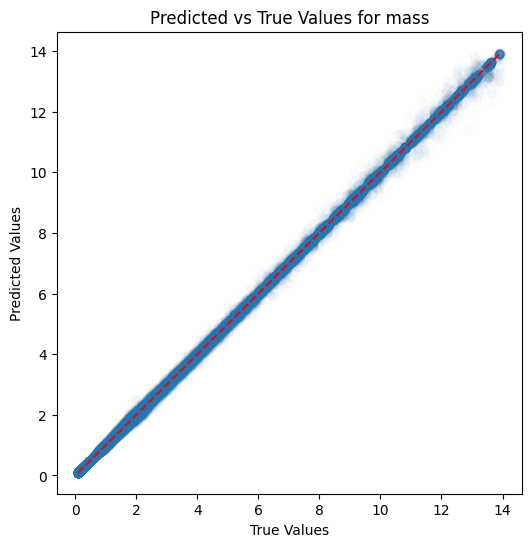

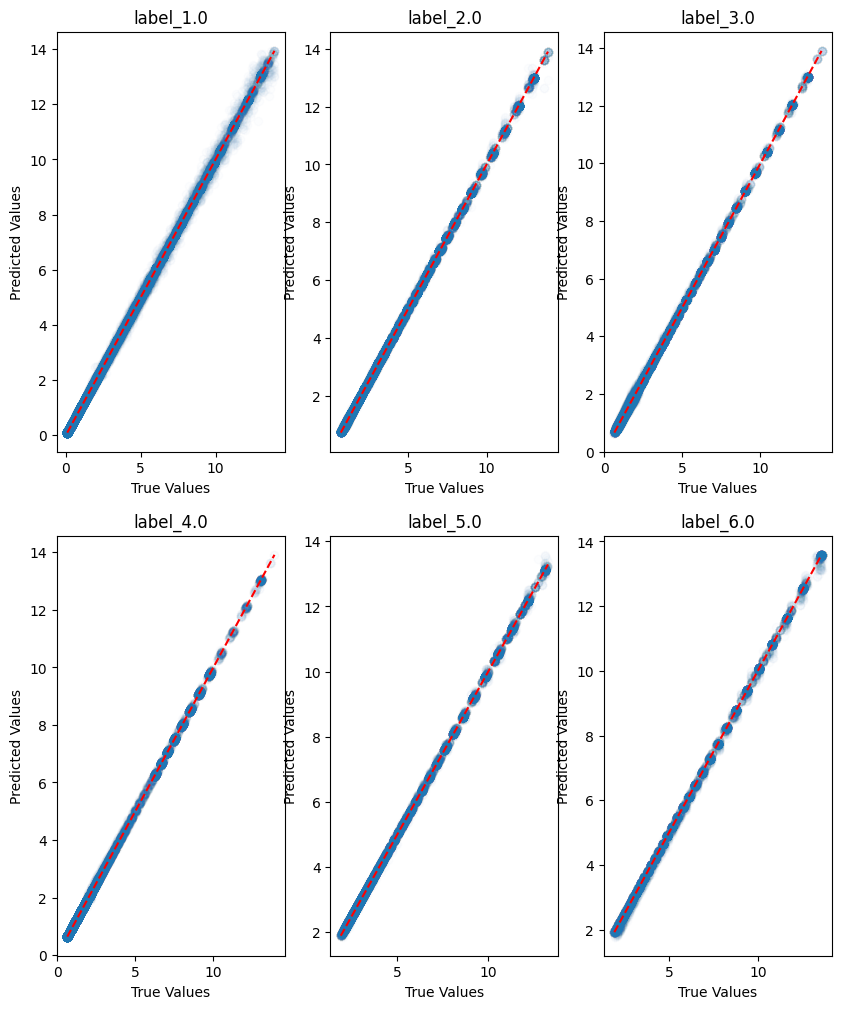

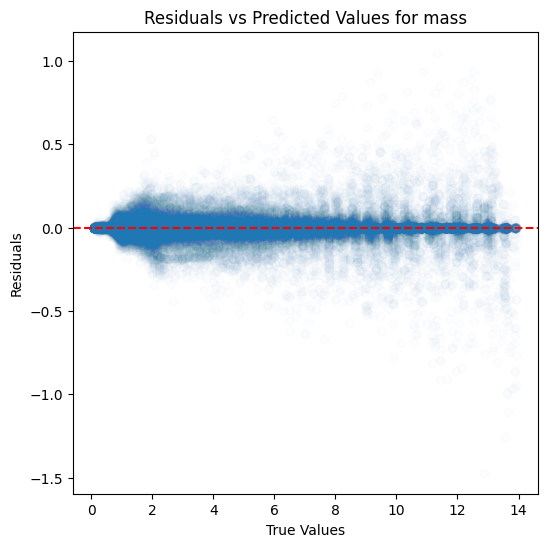

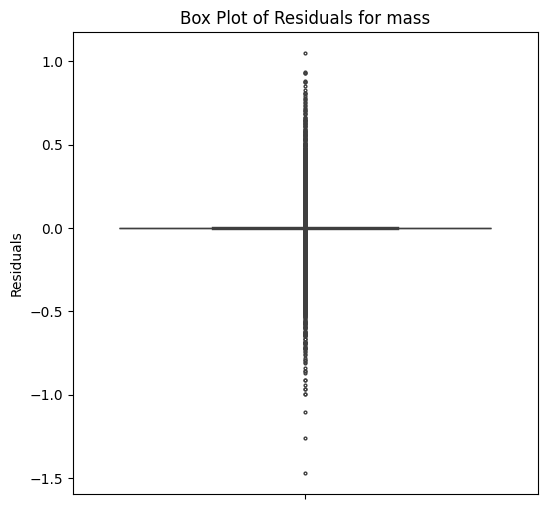

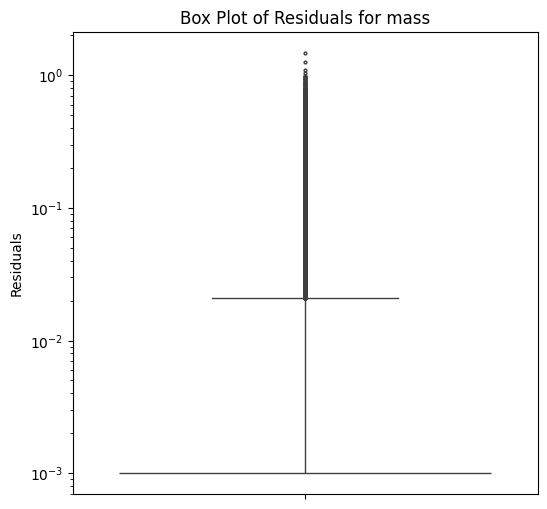

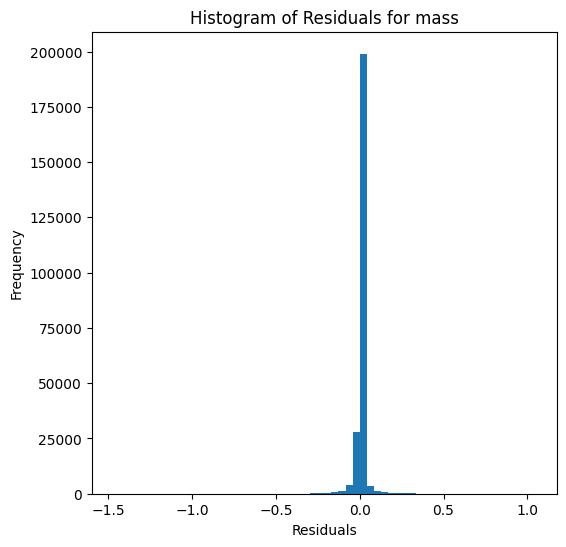

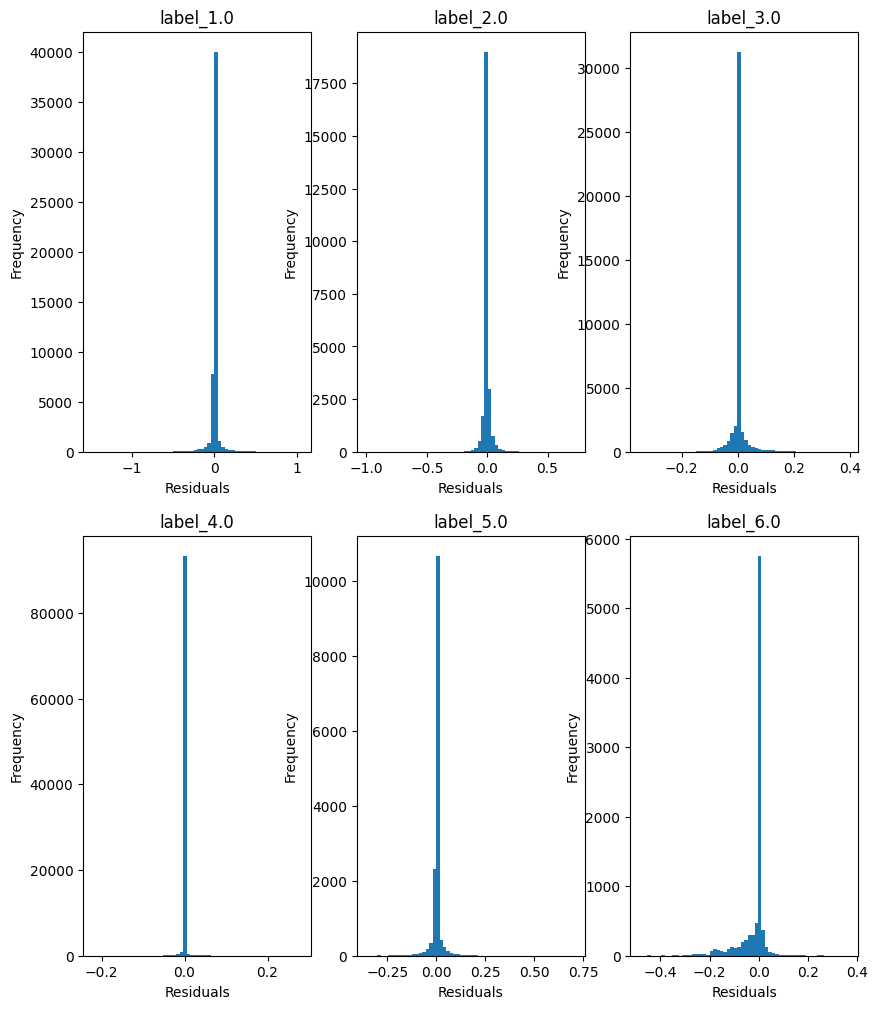

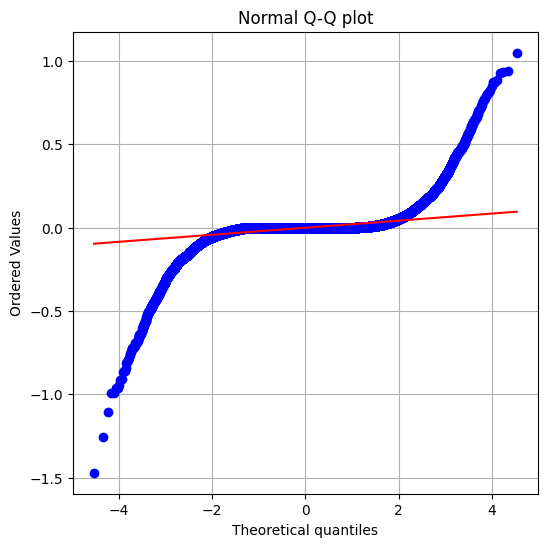

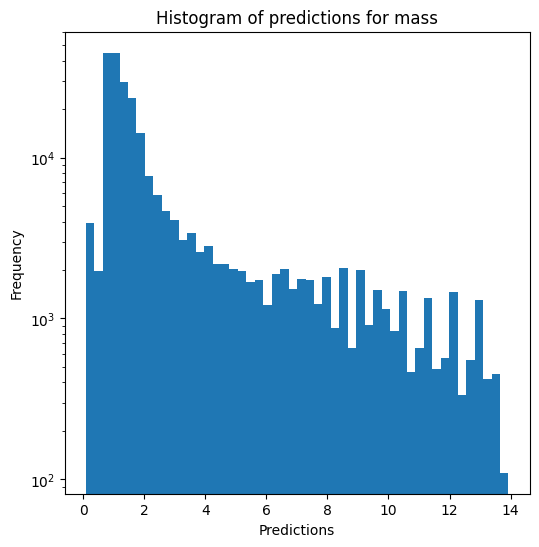

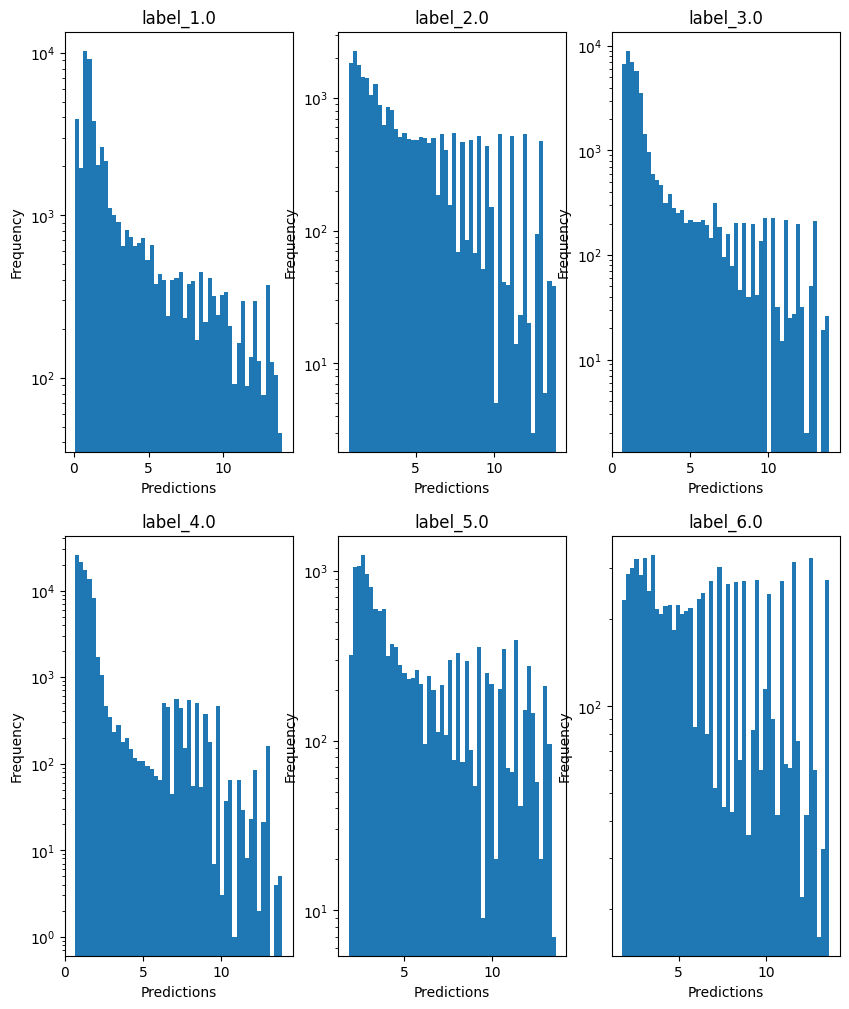

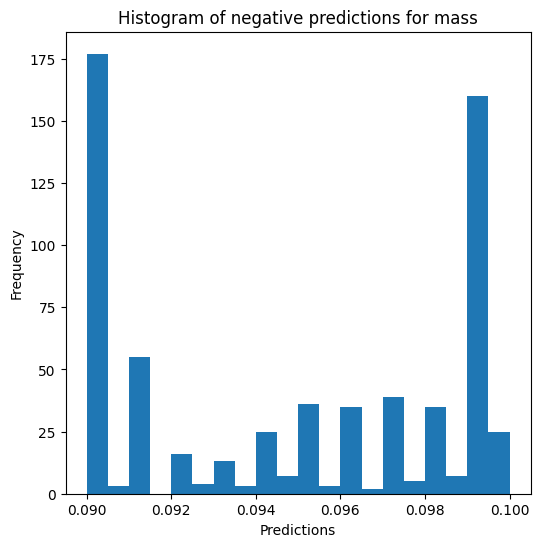

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:4671: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)



radius results for the label category with a value of 1.0
  value range :  -0.9763360818022064 - 1.1687920203141815
  RVE :  0.9995151841417518
  RMSE :  0.008059041902312577
  MAE :  0.00345899878505987
  MedAE :  0.00013196429512894736
  CORR :  0.9997580253699098
  MAX_ER :  0.1103322196253178
  Percentiles : 
    75th percentile :  0.00344690814817342
    90th percentile :  0.011230700304433044
    95th percentile :  0.0179177080555757
    99th percentile :  0.034511360683536836

radius results for the label category with a value of 2.0
  value range :  0.0199466816788423 - 2.458486763798206
  RVE :  0.9986143968871183
  RMSE :  0.020140224452220107
  MAE :  0.008813268260413837
  MedAE :  0.0012547519245196814
  CORR :  0.9993130035330656
  MAX_ER :  0.33740703053157595
  Percentiles : 
    75th percentile :  0.010293401488036036
    90th percentile :  0.026047150531011296
    95th percentile :  0.04110943113164995
    99th percentile :  0.0819117191291129

radius results for the

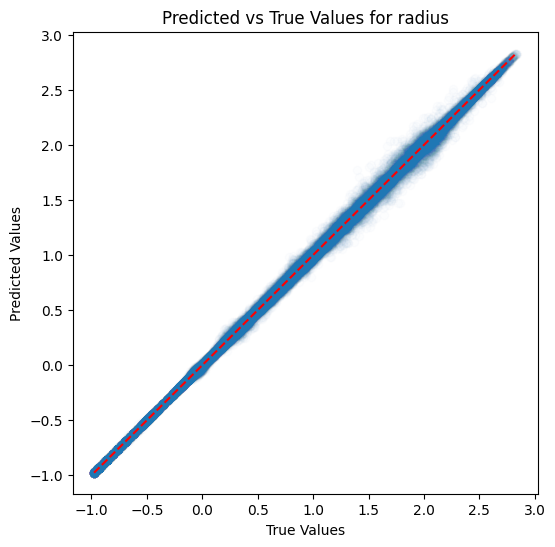

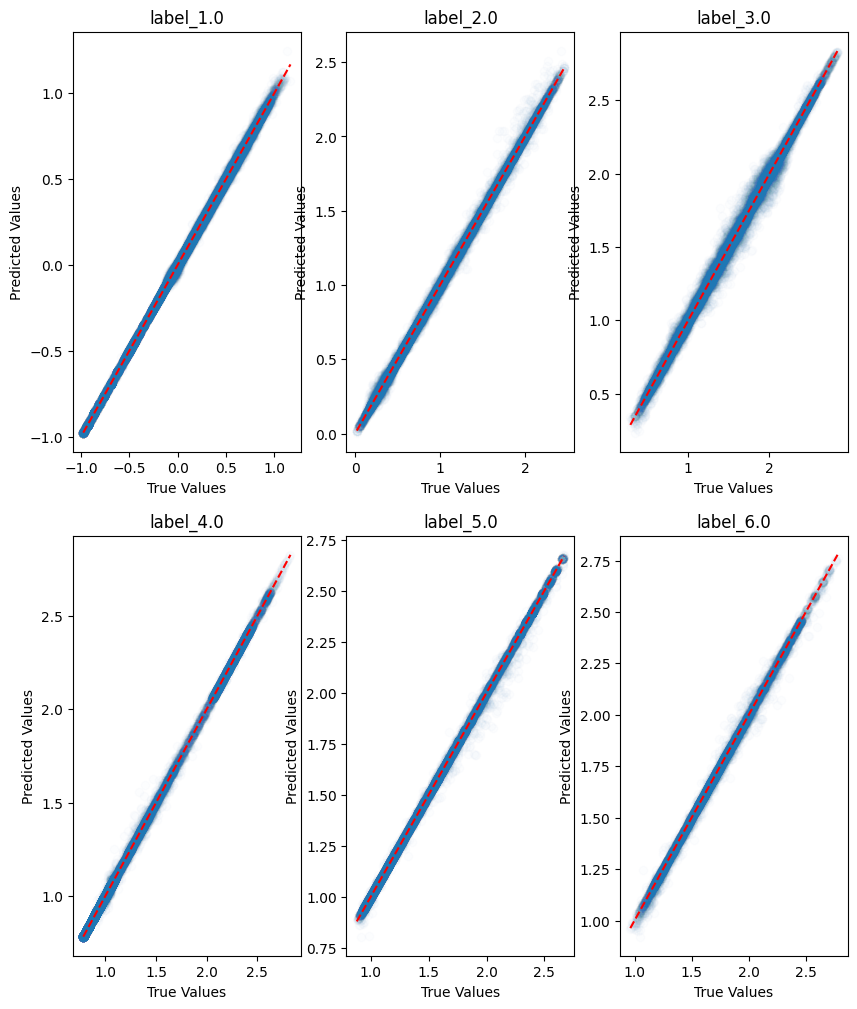

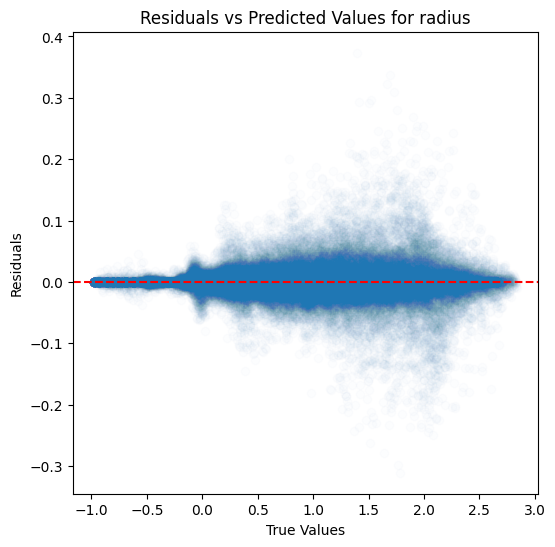

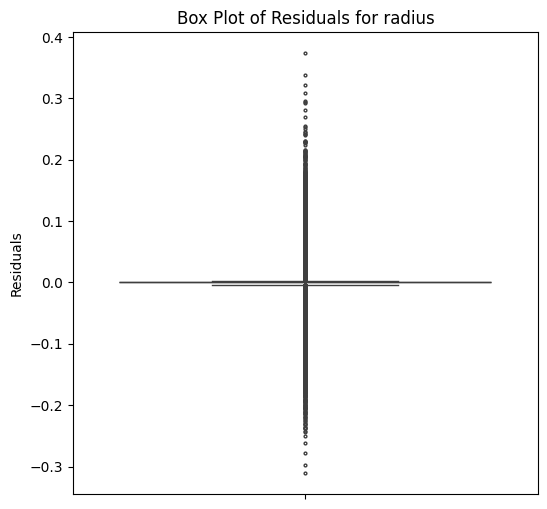

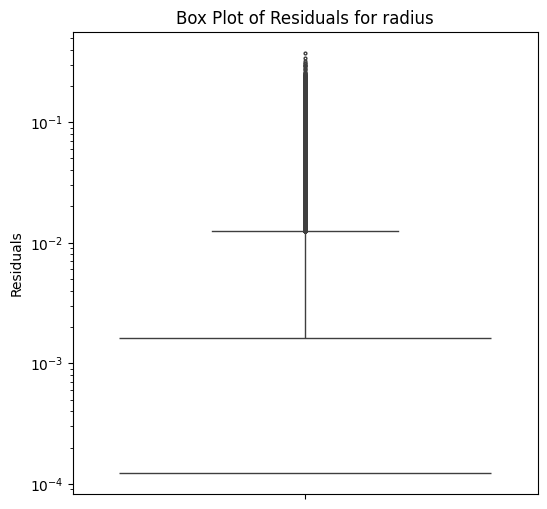

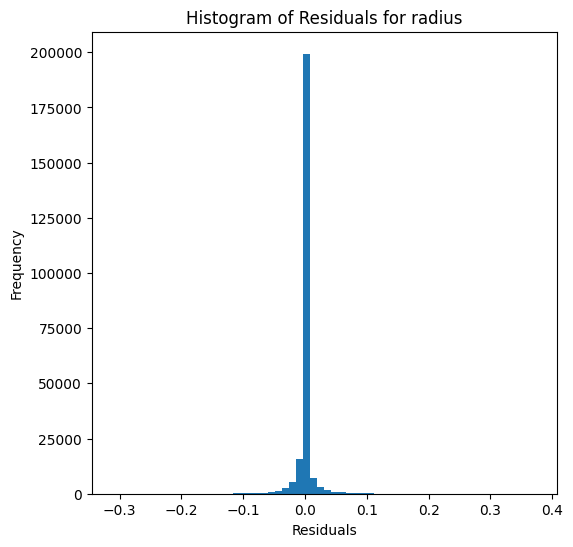

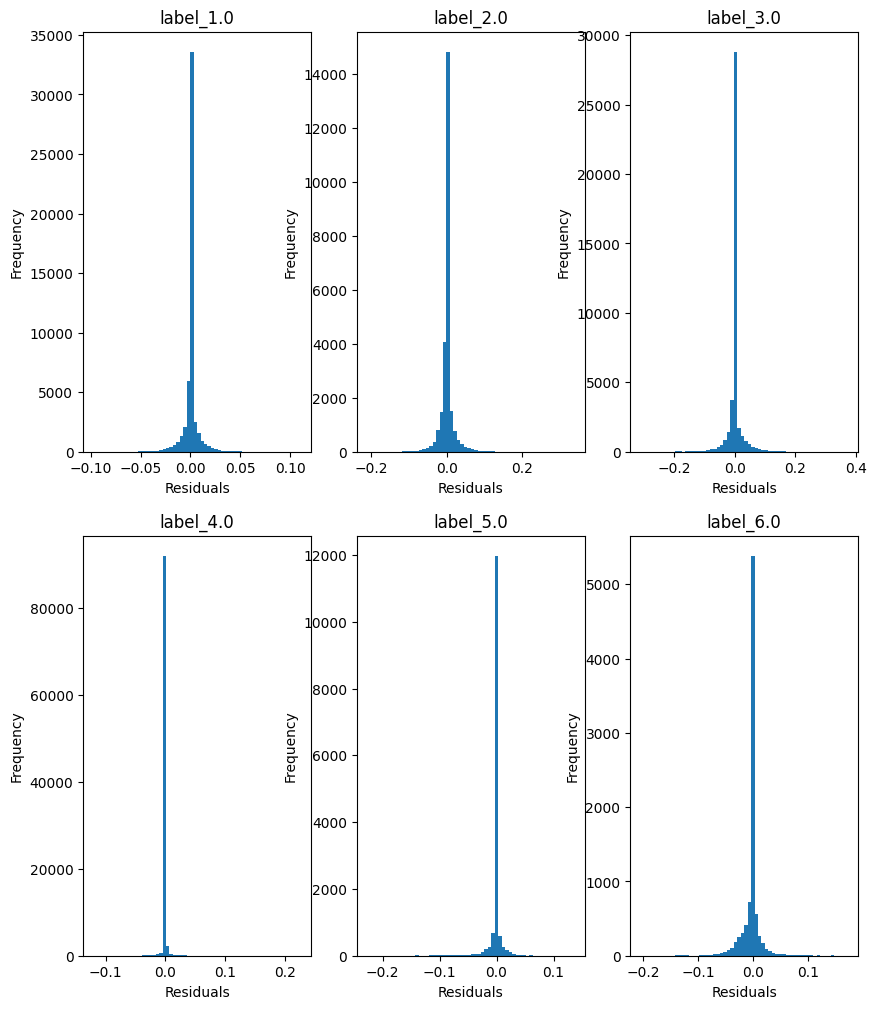

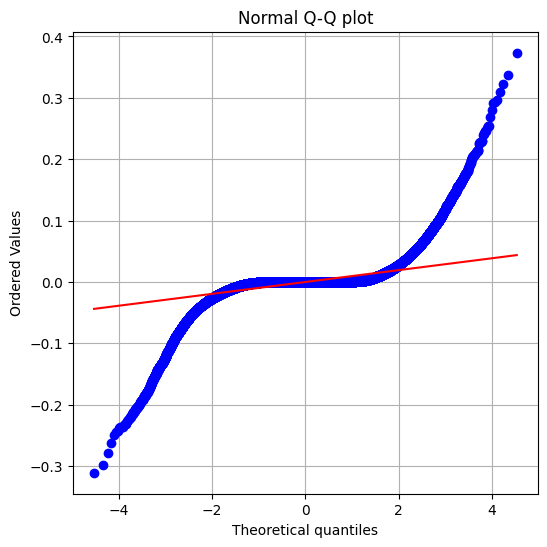

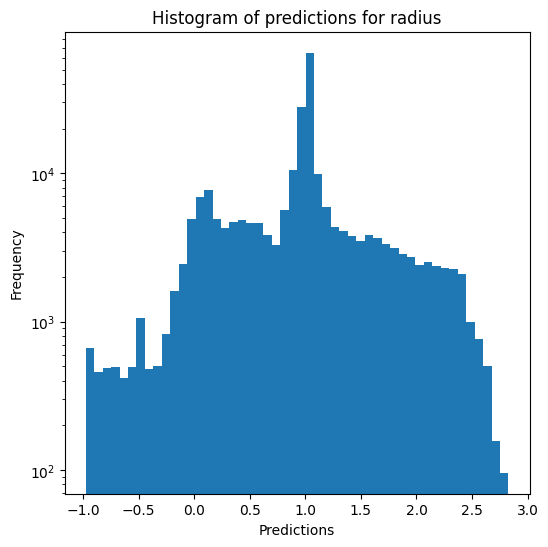

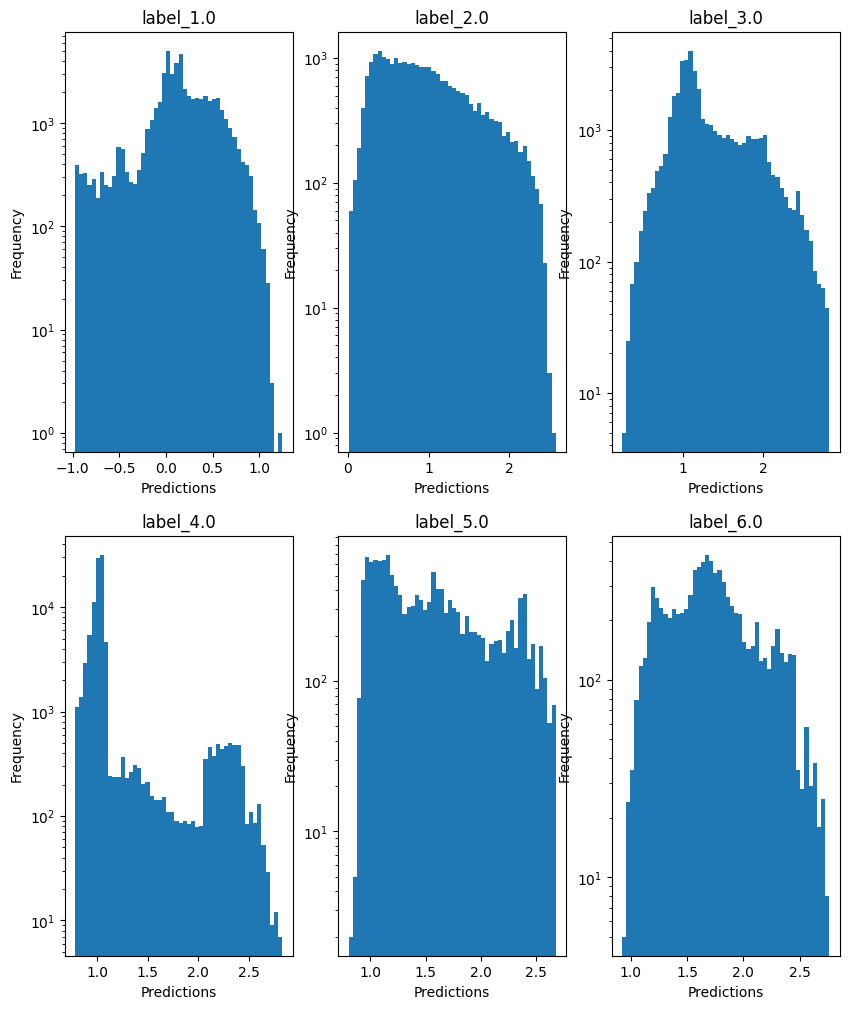

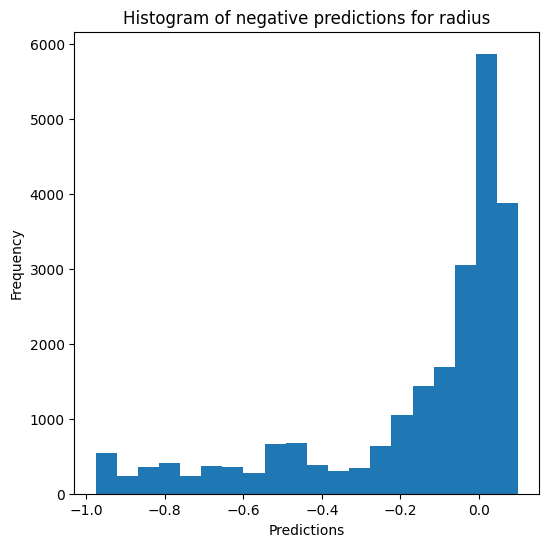

Saving predictions and results...


In [43]:
best_params_DT = {'criterion': 'friedman_mse', 'splitter': "best", 'max_depth': 100, 'min_samples_leaf': 3, 'min_samples_split': 2, 'max_features': None, 'max_leaf_nodes': None}

print(path_to_results)
dt_evaluator = Model_evaluator("decision_tree", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)
dt_evaluator.evaluate_Kfold_results(DecisionTreeRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name="quantile", **best_params_DT)

### Random forest

In [ ]:
tag = "Base"

#### Tuning the n_estimators and criterion parameters

In [ ]:
cv_params = {'criterion' : ["squared_error", "friedman_mse"], # absolute_error prend beaucoup de temps et poisson n'est pas possible avec des valeurs négatives
             'n_estimators' : [50, 100, 200, 400, 600]
            }

gscv_rmse = GridSearchCV(RandomForestRegressor(n_jobs = 10,
                                             ),
                         param_grid = cv_params,
                         scoring = scoring,
                         cv = 10,
                         verbose = 2,
                         refit="neg_root_mean_squared_error"
)

gscv_rmse.fit(X_train, y_train)
display_grid_search(gscv_rmse)

Fitting 10 folds for each of 10 candidates, totalling 100 fits
[CV] END ...........criterion=squared_error, n_estimators=50; total time=   2.7s
[CV] END ...........criterion=squared_error, n_estimators=50; total time=   2.9s
[CV] END ...........criterion=squared_error, n_estimators=50; total time=   2.6s
[CV] END ...........criterion=squared_error, n_estimators=50; total time=   2.9s
[CV] END ...........criterion=squared_error, n_estimators=50; total time=   2.7s
[CV] END ...........criterion=squared_error, n_estimators=50; total time=   2.6s
[CV] END ...........criterion=squared_error, n_estimators=50; total time=   2.6s
[CV] END ...........criterion=squared_error, n_estimators=50; total time=   2.6s
[CV] END ...........criterion=squared_error, n_estimators=50; total time=   2.6s
[CV] END ...........criterion=squared_error, n_estimators=50; total time=   2.6s
[CV] END ..........criterion=squared_error, n_estimators=100; total time=   5.3s
[CV] END ..........criterion=squared_error, n_

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_n_estimators,params,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,split3_test_neg_root_mean_squared_error,split4_test_neg_root_mean_squared_error,split5_test_neg_root_mean_squared_error,split6_test_neg_root_mean_squared_error,split7_test_neg_root_mean_squared_error,split8_test_neg_root_mean_squared_error,split9_test_neg_root_mean_squared_error,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,split0_test_neg_mean_absolute_error,split1_test_neg_mean_absolute_error,split2_test_neg_mean_absolute_error,split3_test_neg_mean_absolute_error,split4_test_neg_mean_absolute_error,split5_test_neg_mean_absolute_error,split6_test_neg_mean_absolute_error,split7_test_neg_mean_absolute_error,split8_test_neg_mean_absolute_error,split9_test_neg_mean_absolute_error,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
0,2.714721,0.101866,0.073111,0.013978,squared_error,50,"{'criterion': 'squared_error', 'n_estimators':...",-0.013031,-0.013177,-0.012876,-0.014214,-0.013244,-0.012278,-0.012016,-0.013536,-0.012842,-0.012428,-0.012964,0.000608,5,-0.003349,-0.003292,-0.003215,-0.003484,-0.003348,-0.003188,-0.003229,-0.003433,-0.003360,-0.003336,-0.003323,0.000090,5
1,5.285130,0.097186,0.126600,0.009042,squared_error,100,"{'criterion': 'squared_error', 'n_estimators':...",-0.012997,-0.013164,-0.012526,-0.013962,-0.012923,-0.012046,-0.011665,-0.013184,-0.012600,-0.012375,-0.012744,0.000617,4,-0.003312,-0.003267,-0.003128,-0.003423,-0.003277,-0.003129,-0.003157,-0.003376,-0.003285,-0.003287,-0.003264,0.000095,4
2,10.335328,0.115558,0.238389,0.008274,squared_error,200,"{'criterion': 'squared_error', 'n_estimators':...",-0.012821,-0.013108,-0.012378,-0.013676,-0.012826,-0.011998,-0.011811,-0.013128,-0.012332,-0.012289,-0.012637,0.000546,3,-0.003268,-0.003234,-0.003093,-0.003362,-0.003224,-0.003088,-0.003162,-0.003344,-0.003233,-0.003246,-0.003225,0.000087,3
3,20.362957,0.315754,0.451176,0.017064,squared_error,400,"{'criterion': 'squared_error', 'n_estimators':...",-0.012781,-0.013030,-0.012262,-0.013749,-0.012761,-0.011966,-0.011769,-0.013135,-0.012469,-0.012245,-0.012617,0.000565,2,-0.003255,-0.003206,-0.003064,-0.003371,-0.003222,-0.003089,-0.003142,-0.003336,-0.003234,-0.003234,-0.003215,0.000092,2
4,30.216506,0.396651,0.664806,0.026203,squared_error,600,"{'criterion': 'squared_error', 'n_estimators':...",-0.012717,-0.013052,-0.012316,-0.013703,-0.012800,-0.011887,-0.011716,-0.013171,-0.012462,-0.012246,-0.012607,0.000576,1,-0.003248,-0.003200,-0.003073,-0.003350,-0.003217,-0.003062,-0.003132,-0.003329,-0.003232,-0.003224,-0.003207,0.000091,1
5,2.694130,0.064335,0.076431,0.015330,friedman_mse,50,"{'criterion': 'friedman_mse', 'n_estimators': 50}",-0.015017,-0.015151,-0.014314,-0.015559,-0.014602,-0.014344,-0.014339,-0.014981,-0.014748,-0.014534,-0.014759,0.000391,10,-0.003884,-0.003862,-0.003695,-0.004006,-0.003823,-0.003783,-0.003837,-0.003939,-0.003905,-0.003949,-0.003868,0.000085,10
6,5.269291,0.083929,0.125865,0.004280,friedman_mse,100,"{'criterion': 'friedman_mse', 'n_estimators': ...",-0.014527,-0.015112,-0.014285,-0.015033,-0.014562,-0.014060,-0.014021,-0.014648,-0.014366,-0.014343,-0.014496,0.000346,9,-0.003797,-0.003802,-0.003644,-0.003879,-0.003783,-0.003711,-0.003745,-0.003827,-0.003839,-0.003878,-0.003791,0.000070,9
7,10.437952,0.097656,0.238241,0.008580,friedman_mse,200,"{'criterion': 'friedman_mse', 'n_estimators': ...",-0.014703,-0.014826,-0.013974,-0.015019,-0.014165,-0.014074,-0.013922,-0.014661,-0.014306,-0.014215,-0.014386,0.000366,8,-0.003796,-0.003738,-0.003586,-0.003843,-0.003714,-0.003694,-0.003710,-0.003826,-0.003818,-0.003833,-0.003756,0.000078,8
8,20.189794,0.245624,0.446032,0.014548,friedman_mse,400,"{'criterion': 'friedman_mse', 'n_estimators': ...",-0.014500,-0.014

Best parameters {'criterion': 'squared_error', 'n_estimators': 600}
Best score -0.012607066747960203


In [16]:
cv_params = {'criterion' : ["squared_error", "friedman_mse"], # absolute_error prend beaucoup de temps et poisson n'est pas possible avec des valeurs négatives
             'n_estimators' : [50, 100, 200, 400, 600]
            }

gscv_max_er = GridSearchCV(RandomForestRegressor(n_jobs = 10,
                                             ),
                         param_grid = cv_params,
                         scoring = max_err_scorer,
                         cv = 10,
                         verbose = 2,
                         refit=True
)

gscv_max_er.fit(X_train, y_train)
display_grid_search(gscv_max_er)

Fitting 10 folds for each of 10 candidates, totalling 100 fits
[CV] END ...........criterion=squared_error, n_estimators=50; total time=   2.8s
[CV] END ...........criterion=squared_error, n_estimators=50; total time=   2.9s
[CV] END ...........criterion=squared_error, n_estimators=50; total time=   2.7s
[CV] END ...........criterion=squared_error, n_estimators=50; total time=   2.7s
[CV] END ...........criterion=squared_error, n_estimators=50; total time=   2.6s
[CV] END ...........criterion=squared_error, n_estimators=50; total time=   2.6s
[CV] END ...........criterion=squared_error, n_estimators=50; total time=   2.6s
[CV] END ...........criterion=squared_error, n_estimators=50; total time=   2.5s
[CV] END ...........criterion=squared_error, n_estimators=50; total time=   2.6s
[CV] END ...........criterion=squared_error, n_estimators=50; total time=   2.6s
[CV] END ..........criterion=squared_error, n_estimators=100; total time=   5.3s
[CV] END ..........criterion=squared_error, n_

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score,rank_test_score
0,2.685557,0.084743,0.073125,0.011426,squared_error,50,"{'criterion': 'squared_error', 'n_estimators':...",-0.549060,-0.676060,-0.749120,-0.778220,-0.699780,-0.612300,-0.682480,-0.531480,-0.560180,-0.614660,-0.645334,0.080767,3
1,5.255325,0.124889,0.122711,0.005183,squared_error,100,"{'criterion': 'squared_error', 'n_estimators':...",-0.556130,-0.626590,-0.752150,-0.781230,-0.703500,-0.621990,-0.594160,-0.573770,-0.587340,-0.559070,-0.635593,0.077273,1
2,11.415959,0.273378,0.247221,0.018615,squared_error,200,"{'criterion': 'squared_error', 'n_estimators':...",-0.593590,-0.639075,-0.737325,-0.764955,-0.687670,-0.629290,-0.636665,-0.544360,-0.608065,-0.587640,-0.642863,0.065165,2
3,22.911138,0.149853,0.479277,0.013113,squared_error,400,"{'criterion': 'squared_error', 'n_estimators':...",-0.557098,-0.646352,-0.748370,-0.822820,-0.714498,-0.614187,-0.612710,-0.552918,-0.617203,-0.589505,-0.647566,0.083139,5
4,34.157823,0.370207,0.723262,0.022712,squared_error,600,"{'criterion': 'squared_error', 'n_estimators':...",-0.508630,-0.642102,-0.738180,-0.844865,-0.707388,-0.642887,-0.657788,-0.531560,-0.608767,-0.589698,-0.647187,0.094067,4
5,2.943480,0.043985,0.078384,0.011700,friedman_mse,50,"{'criterion': 'friedman_mse', 'n_estimators': 50}",-0.548840,-0.626960,-0.716800,-0.835320,-0.743000,-0.643300,-0.703420,-0.555280,-0.650460,-0.691380,-0.671476,0.081969,9
6,5.828833,0.089212,0.147948,0.017722,friedman_mse,100,"{'criterion': 'friedman_mse', 'n_estimators': ...",-0.518050,-0.663960,-0.724340,-0.797530,-0.738290,-0.705850,-0.748180,-0.542120,-0.624830,-0.682730,-0.674588,0.085292,10
7,11.591163,0.160113,0.247458,0.005241,friedman_mse,200,"{'criterion': 'friedman_mse', 'n_estimators': ...",-0.516905,-0.646255,-0.702330,-0.747105,-0.757745,-0.709670,-0.748725,-0.609625,-0.652190,-0.609930,-0.670048,0.073508,8
8,22.916517,0.246072,0.503804,0.029474,friedman_mse,400,"{'criterion': 'friedman_mse', 'n_estimators': ...",-0.508045,-0.649115,-0.728285,-0.785655,-0.728790,-0.685005,-0.741910,-0.557015,-0.649688,-0.660265,-0.669377,0.080969,7
9,34.630520,0.292131,0.734047,0.014259,friedman_mse,600,"{'criterion': 'friedman_mse', 'n_estimators': ...",-0.498342,-0.658850,-0.742367,-0.785188,-0.732800,-0.690857,-0.757632,-0.551082,-0.630862,-0.616095,-0.666407,0.088659,6


Best parameters {'criterion': 'squared_error', 'n_estimators': 100}
Best score -0.6355929999999977


Best parameters {'criterion': 'squared_error', 'n_estimators': 600}

Best RMSE -0.012607066747960203

Best parameters {'criterion': 'squared_error', 'n_estimators': 100}

Best MAX_ER -0.6355929999999977

Chosen parameters {'criterion': 'squared_error', 'n_estimators': 400}

#### Tuning the max_depth, min_samples_split and min_samples_leaf parameters

In [17]:
cv_params = {'max_depth' : [50, 100, None],
             'min_samples_split' : [2, 6, 10],
             'min_samples_leaf' : [1, 3, 5],
            }

gscv_rmse = GridSearchCV(RandomForestRegressor(n_jobs = 10,
                                             criterion="squared_error",
                                             n_estimators=100, # results with more estimators are better but take more time, doing gridsearchcv with 100 is comparable to more
                                            ),
                         param_grid = cv_params,
                         scoring = scoring,
                         cv = 10,
                         verbose = 2,
                         refit="neg_root_mean_squared_error"
)

gscv_rmse.fit(X_train, y_train)
display_grid_search(gscv_rmse)

Fitting 10 folds for each of 27 candidates, totalling 270 fits
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=   5.6s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=   5.8s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=   6.0s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=   5.9s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=   6.0s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=   6.0s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=   5.9s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=   6.0s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=   6.1s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=   5.9s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=6; total time=   5.2s
[CV] END max_depth=50, m

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_min_samples_leaf,param_min_samples_split,params,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,split3_test_neg_root_mean_squared_error,split4_test_neg_root_mean_squared_error,split5_test_neg_root_mean_squared_error,split6_test_neg_root_mean_squared_error,split7_test_neg_root_mean_squared_error,split8_test_neg_root_mean_squared_error,split9_test_neg_root_mean_squared_error,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,split0_test_neg_mean_absolute_error,split1_test_neg_mean_absolute_error,split2_test_neg_mean_absolute_error,split3_test_neg_mean_absolute_error,split4_test_neg_mean_absolute_error,split5_test_neg_mean_absolute_error,split6_test_neg_mean_absolute_error,split7_test_neg_mean_absolute_error,split8_test_neg_mean_absolute_error,split9_test_neg_mean_absolute_error,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
0,5.878988,0.113115,0.137039,0.010440,50,1,2,"{'max_depth': 50, 'min_samples_leaf': 1, 'min_...",-0.012941,-0.013161,-0.012553,-0.013665,-0.012853,-0.012049,-0.011845,-0.013330,-0.012514,-0.012498,-0.012741,0.000534,1,-0.003311,-0.003249,-0.003155,-0.003384,-0.003263,-0.003126,-0.003183,-0.003386,-0.003291,-0.003299,-0.003265,0.000084,2
1,5.244834,0.055103,0.104641,0.009094,50,1,6,"{'max_depth': 50, 'min_samples_leaf': 1, 'min_...",-0.014229,-0.014406,-0.013575,-0.015059,-0.014387,-0.013472,-0.013134,-0.014371,-0.014000,-0.013619,-0.014025,0.000545,4,-0.003970,-0.003902,-0.003785,-0.004044,-0.003968,-0.003787,-0.003835,-0.004007,-0.003962,-0.003926,-0.003918,0.000086,4
2,4.976299,0.097061,0.089991,0.009827,50,1,10,"{'max_depth': 50, 'min_samples_leaf': 1, 'min_...",-0.016597,-0.016695,-0.016027,-0.017156,-0.016964,-0.015588,-0.015350,-0.016617,-0.016402,-0.016018,-0.016341,0.000555,15,-0.005161,-0.005034,-0.004960,-0.005209,-0.005220,-0.004934,-0.005020,-0.005177,-0.005122,-0.005089,-0.005093,0.000097,14
3,5.128181,0.062645,0.101371,0.012232,50,3,2,"{'max_depth': 50, 'min_samples_leaf': 3, 'min_...",-0.015575,-0.015645,-0.015029,-0.016181,-0.015714,-0.014690,-0.014455,-0.015577,-0.015165,-0.014663,-0.015269,0.000529,7,-0.004676,-0.004596,-0.004472,-0.004747,-0.004700,-0.004462,-0.004517,-0.004694,-0.004658,-0.004610,-0.004613,0.000095,8
4,4.944119,0.164860,0.100092,0.005899,50,3,6,"{'max_depth': 50, 'min_samples_leaf': 3, 'min_...",-0.015527,-0.015643,-0.015092,-0.016223,-0.015715,-0.014629,-0.014455,-0.015636,-0.015321,-0.014658,-0.015290,0.000541,9,-0.004679,-0.004601,-0.004500,-0.004761,-0.004705,-0.004440,-0.004537,-0.004669,-0.004695,-0.004604,-0.004619,0.000096,11
5,4.622108,0.100785,0.084432,0.011658,50,3,10,"{'max_depth': 50, 'min_samples_leaf': 3, 'min_...",-0.017220,-0.017574,-0.016571,-0.017767,-0.017717,-0.016326,-0.016095,-0.017244,-0.016988,-0.016427,-0.016993,0.000577,16,-0.005465,-0.005424,-0.005275,-0.005554,-0.005590,-0.005264,-0.005321,-0.005494,-0.005482,-0.005433,-0.005430,0.000106,16
6,5.476151,2.230029,0.092115,0.044237,50,5,2,"{'max_depth': 50, 'min_samples_leaf': 5, 'min_...",-0.018579,-0.018605,-0.017992,-0.019397,-0.019216,-0.017549,-0.017813,-0.018507,-0.018346,-0.017820,-0.018383,0.000576,23,-0.006148,-0.006085,-0.005970,-0.006256,-0.006307,-0.005934,-0.006086,-0.006166,-0.006152,-0.006072,-0.006118,0.000109,24
7,4.330961,0.038707,0.077589,0.010871,50,5,6,"{'max_depth': 50, 'min_samples_leaf': 5, 'min_...",-0.018672,-0.018710,-0.017997,-0.019103,-0.019143,-0.017565,-0.017884,-0.018450,-0.018285,-0.017764,-0.018357,0.000524,21,-0.006185,-0.006040,-0.005926,-0.006234,-0.006306,-0.005939,-0.006092,-0.006160,-0.006165,-0.006075,-0.006112,0.000116,23
8,4.357152,0.045682,0.074604,0.008542,50,5,10,"{'max_depth': 50, 'min_samples_leaf': 5, 'min_...",-0.018533,-0.018667,-0.017918,-0.019077,-0.019065,-0.017635,-0.017349,-0.018

Best parameters {'max_depth': 50, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best score -0.012740825416903879


In [18]:
cv_params = {'max_depth' : [50, 100, None],
             'min_samples_split' : [2, 6, 10],
             'min_samples_leaf' : [1, 3, 5],
            }

gscv_max_er = GridSearchCV(RandomForestRegressor(n_jobs = 10,
                                             criterion="squared_error",
                                             n_estimators=100, # results with more estimators are better but take more time, doing gridsearchcv with 100 is comparable to more
                                            ),
                         param_grid = cv_params,
                         scoring = max_err_scorer,
                         cv = 10,
                         verbose = 2,
                         refit=True
)

gscv_max_er.fit(X_train, y_train)
display_grid_search(gscv_max_er)

Fitting 10 folds for each of 27 candidates, totalling 270 fits
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=   5.3s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=   5.3s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=   5.1s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=   5.3s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=   5.2s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=   5.2s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=   5.1s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=   5.0s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=   5.2s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=   5.0s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=6; total time=   4.6s
[CV] END max_depth=50, m

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_min_samples_leaf,param_min_samples_split,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score,rank_test_score
0,5.142660,0.111379,0.125348,0.009576,50,1,2,"{'max_depth': 50, 'min_samples_leaf': 1, 'min_...",-0.594120,-0.665840,-0.731860,-0.791230,-0.709580,-0.622060,-0.647700,-0.535720,-0.649180,-0.646740,-0.659403,0.068223,3
1,4.605766,0.070957,0.094544,0.006188,50,1,6,"{'max_depth': 50, 'min_samples_leaf': 1, 'min_...",-0.678953,-0.631500,-0.754737,-0.734389,-0.736817,-0.650203,-0.749848,-0.589495,-0.652190,-0.699406,-0.687754,0.053509,6
2,4.419985,0.068837,0.081817,0.007133,50,1,10,"{'max_depth': 50, 'min_samples_leaf': 1, 'min_...",-0.739923,-0.726328,-0.763268,-0.792614,-0.752862,-0.725064,-0.807874,-0.610116,-0.763265,-0.811196,-0.749251,0.054878,15
3,4.548646,0.078996,0.089071,0.004233,50,3,2,"{'max_depth': 50, 'min_samples_leaf': 3, 'min_...",-0.608418,-0.663884,-0.774815,-0.812411,-0.753049,-0.688633,-0.839603,-0.566638,-0.666674,-0.702486,-0.707661,0.082869,7
4,4.550884,0.057154,0.093954,0.011012,50,3,6,"{'max_depth': 50, 'min_samples_leaf': 3, 'min_...",-0.677521,-0.687135,-0.773693,-0.760939,-0.747050,-0.691340,-0.836769,-0.567555,-0.696260,-0.731996,-0.717026,0.068184,12
5,4.296039,0.071314,0.077409,0.007455,50,3,10,"{'max_depth': 50, 'min_samples_leaf': 3, 'min_...",-0.785063,-0.753995,-0.757175,-0.777469,-0.772848,-0.688799,-0.816235,-0.617905,-0.767862,-0.797283,-0.753463,0.055308,18
6,4.226020,0.044102,0.074141,0.010736,50,5,2,"{'max_depth': 50, 'min_samples_leaf': 5, 'min_...",-0.781199,-0.708915,-0.797745,-0.770489,-0.774239,-0.746326,-0.876411,-0.589982,-0.818813,-0.813035,-0.767715,0.072882,23
7,4.238541,0.079725,0.075702,0.012226,50,5,6,"{'max_depth': 50, 'min_samples_leaf': 5, 'min_...",-0.816534,-0.727961,-0.783129,-0.804049,-0.784241,-0.681049,-0.849413,-0.654904,-0.762893,-0.807051,-0.767123,0.058544,22
8,4.203774,0.055298,0.073973,0.010671,50,5,10,"{'max_depth': 50, 'min_samples_leaf': 5, 'min_...",-0.785577,-0.690131,-0.767823,-0.776960,-0.780073,-0.784342,-0.851382,-0.602403,-0.822749,-0.876336,-0.773778,0.074593,26
9,5.188966,0.117096,0.118192,0.003155,100,1,2,"{'max_depth': 100, 'min_samples_leaf': 1, 'min...",-0.511200,-0.640930,-0.708990,-0.813790,-0.690310,-0.674220,-0.625280,-0.532530,-0.601150,-0.615620,-0.641402,0.083130,1


Best parameters {'max_depth': 100, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best score -0.6414019999999994


Best parameters {'max_depth': 50, 'min_samples_leaf': 1, 'min_samples_split': 2}

Best RMSE -0.012740825416903879

Best parameters {'max_depth': 100, 'min_samples_leaf': 1, 'min_samples_split': 2}

Best MAX_ER -0.6414019999999994

Chosen parameters {'max_depth': 100, 'min_samples_leaf': 1, 'min_samples_split': 2}

#### Tuning the max_features and max_leaf_nodes parameters

In [19]:
cv_params = {"max_features" : ["sqrt", "log2", None], 
             "max_leaf_nodes" : [50, 100, 200, None]
            }

gscv_rmse = GridSearchCV(RandomForestRegressor(n_jobs = 10,
                                             criterion="squared_error",
                                             n_estimators=100,
                                             max_depth=100,
                                             min_samples_leaf=1,
                                             min_samples_split=2
                                            ),
                         param_grid = cv_params,
                         scoring = scoring,
                         cv = 10,
                         verbose = 2,
                         refit="neg_root_mean_squared_error"
)

gscv_rmse.fit(X_train, y_train)
display_grid_search(gscv_rmse)

Fitting 10 folds for each of 12 candidates, totalling 120 fits
[CV] END ...............max_features=sqrt, max_leaf_nodes=50; total time=   1.5s
[CV] END ...............max_features=sqrt, max_leaf_nodes=50; total time=   1.5s
[CV] END ...............max_features=sqrt, max_leaf_nodes=50; total time=   1.4s
[CV] END ...............max_features=sqrt, max_leaf_nodes=50; total time=   1.4s
[CV] END ...............max_features=sqrt, max_leaf_nodes=50; total time=   1.4s
[CV] END ...............max_features=sqrt, max_leaf_nodes=50; total time=   1.6s
[CV] END ...............max_features=sqrt, max_leaf_nodes=50; total time=   1.4s
[CV] END ...............max_features=sqrt, max_leaf_nodes=50; total time=   1.4s
[CV] END ...............max_features=sqrt, max_leaf_nodes=50; total time=   1.4s
[CV] END ...............max_features=sqrt, max_leaf_nodes=50; total time=   1.4s
[CV] END ..............max_features=sqrt, max_leaf_nodes=100; total time=   1.5s
[CV] END ..............max_features=sqrt, max_

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_features,param_max_leaf_nodes,params,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,split3_test_neg_root_mean_squared_error,split4_test_neg_root_mean_squared_error,split5_test_neg_root_mean_squared_error,split6_test_neg_root_mean_squared_error,split7_test_neg_root_mean_squared_error,split8_test_neg_root_mean_squared_error,split9_test_neg_root_mean_squared_error,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,split0_test_neg_mean_absolute_error,split1_test_neg_mean_absolute_error,split2_test_neg_mean_absolute_error,split3_test_neg_mean_absolute_error,split4_test_neg_mean_absolute_error,split5_test_neg_mean_absolute_error,split6_test_neg_mean_absolute_error,split7_test_neg_mean_absolute_error,split8_test_neg_mean_absolute_error,split9_test_neg_mean_absolute_error,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
0,1.518424,0.056384,0.027928,0.005032,sqrt,50,"{'max_features': 'sqrt', 'max_leaf_nodes': 50}",-0.158878,-0.161573,-0.160185,-0.161305,-0.159643,-0.156236,-0.159725,-0.160379,-0.159306,-0.159592,-0.159682,0.001401,11,-0.103428,-0.103748,-0.103121,-0.103055,-0.103945,-0.102126,-0.102746,-0.104879,-0.104069,-0.104325,-0.103544,0.000771,11
1,1.676287,0.031989,0.029985,0.007561,sqrt,100,"{'max_features': 'sqrt', 'max_leaf_nodes': 100}",-0.107989,-0.106151,-0.106396,-0.107833,-0.106791,-0.105053,-0.106931,-0.105845,-0.107518,-0.107002,-0.106751,0.000871,8,-0.069346,-0.068139,-0.069915,-0.070007,-0.069174,-0.068226,-0.069205,-0.069398,-0.069415,-0.069070,-0.069189,0.000580,8
2,1.803671,0.026036,0.032349,0.004785,sqrt,200,"{'max_features': 'sqrt', 'max_leaf_nodes': 200}",-0.074459,-0.074829,-0.072940,-0.073848,-0.073394,-0.072828,-0.072555,-0.072901,-0.071795,-0.073437,-0.073299,0.000857,5,-0.047298,-0.047256,-0.046552,-0.047227,-0.046820,-0.046123,-0.046525,-0.046606,-0.046273,-0.046724,-0.046740,0.000390,4
3,3.426616,0.050899,0.131010,0.006296,sqrt,None,"{'max_features': 'sqrt', 'max_leaf_nodes': None}",-0.012425,-0.013238,-0.012232,-0.012784,-0.012156,-0.011676,-0.011265,-0.012399,-0.011788,-0.011871,-0.012183,0.000542,1,-0.003459,-0.003479,-0.003335,-0.003545,-0.003415,-0.003377,-0.003322,-0.003500,-0.003473,-0.003502,-0.003441,0.000072,3
4,1.473171,0.030051,0.028951,0.005708,log2,50,"{'max_features': 'log2', 'max_leaf_nodes': 50}",-0.159359,-0.161608,-0.157308,-0.155872,-0.161144,-0.157969,-0.158584,-0.158066,-0.158240,-0.159185,-0.158734,0.001618,10,-0.102808,-0.103544,-0.102258,-0.101408,-0.103794,-0.102594,-0.102950,-0.102495,-0.102098,-0.103150,-0.102710,0.000668,10
5,1.652306,0.030140,0.029360,0.006717,log2,100,"{'max_features': 'log2', 'max_leaf_nodes': 100}",-0.104550,-0.107590,-0.106759,-0.105893,-0.107410,-0.105521,-0.105243,-0.105933,-0.106105,-0.106721,-0.106172,0.000908,7,-0.066879,-0.069549,-0.068849,-0.069144,-0.069982,-0.068923,-0.068538,-0.069184,-0.069120,-0.068980,-0.068915,0.000775,7
6,1.813137,0.037555,0.039858,0.011475,log2,200,"{'max_features': 'log2', 'max_leaf_nodes': 200}",-0.072821,-0.074241,-0.072598,-0.072638,-0.073826,-0.072432,-0.072265,-0.073898,-0.071889,-0.073865,-0.073047,0.000786,4,-0.046425,-0.046864,-0.046358,-0.047148,-0.047018,-0.046683,-0.046583,-0.047207,-0.046352,-0.046908,-0.046755,0.000305,5
7,3.424226,0.069626,0.130133,0.009316,log2,None,"{'max_features': 'log2', 'max_leaf_nodes': None}",-0.012599,-0.013151,-0.012250,-0.012926,-0.012407,-0.011683,-0.011272,-0.012360,-0.011392,-0.011855,-0.012190,0.000597,2,-0.003460,-0.003494,-0.003352,-0.003515,-0.003455,-0.003353,-0.003378,-0.003471,-0.003382,-0.003441,-0.003430,0.000056,2
8,2.322938,0.028985,0.027066,0.003880,None,50,"{'max_features': None, 'max_leaf_nodes': 50}",-0.194604,-0.197352,-0.197446,-0.199048,-0.203529,-0.196359,-0.198998,-0.199173,-0.196981,-0.195944,-0.197943,0

Best parameters {'max_features': 'sqrt', 'max_leaf_nodes': None}
Best score -0.012183331232629456


In [20]:
cv_params = {"max_features" : ["sqrt", "log2", None], 
             "max_leaf_nodes" : [50, 100, 200, None]
            }

gscv_max_er = GridSearchCV(RandomForestRegressor(n_jobs = 10,
                                             criterion="squared_error",
                                             n_estimators=100,
                                             max_depth=100,
                                             min_samples_leaf=1,
                                             min_samples_split=2
                                            ),
                         param_grid = cv_params,
                         scoring = max_err_scorer,
                         cv = 10,
                         verbose = 2,
                         refit=True
)

gscv_max_er.fit(X_train, y_train)
display_grid_search(gscv_max_er)

Fitting 10 folds for each of 12 candidates, totalling 120 fits
[CV] END ...............max_features=sqrt, max_leaf_nodes=50; total time=   1.3s
[CV] END ...............max_features=sqrt, max_leaf_nodes=50; total time=   1.3s
[CV] END ...............max_features=sqrt, max_leaf_nodes=50; total time=   1.3s
[CV] END ...............max_features=sqrt, max_leaf_nodes=50; total time=   1.4s
[CV] END ...............max_features=sqrt, max_leaf_nodes=50; total time=   1.3s
[CV] END ...............max_features=sqrt, max_leaf_nodes=50; total time=   1.3s
[CV] END ...............max_features=sqrt, max_leaf_nodes=50; total time=   1.5s
[CV] END ...............max_features=sqrt, max_leaf_nodes=50; total time=   1.3s
[CV] END ...............max_features=sqrt, max_leaf_nodes=50; total time=   1.3s
[CV] END ...............max_features=sqrt, max_leaf_nodes=50; total time=   1.4s
[CV] END ..............max_features=sqrt, max_leaf_nodes=100; total time=   1.5s
[CV] END ..............max_features=sqrt, max_

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_features,param_max_leaf_nodes,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score,rank_test_score
0,1.420294,0.068646,0.025432,0.002869,sqrt,50,"{'max_features': 'sqrt', 'max_leaf_nodes': 50}",-2.148292,-2.441462,-2.161312,-2.388559,-2.805324,-2.467115,-2.291556,-2.954486,-2.453090,-2.256433,-2.436763,0.249018,11
1,1.562318,0.041192,0.026317,0.004131,sqrt,100,"{'max_features': 'sqrt', 'max_leaf_nodes': 100}",-1.818277,-1.828830,-1.638953,-1.934780,-2.050354,-1.785885,-1.719507,-1.881204,-1.817412,-1.864157,-1.833936,0.106827,8
2,1.742379,0.037238,0.036321,0.009209,sqrt,200,"{'max_features': 'sqrt', 'max_leaf_nodes': 200}",-1.424237,-1.549806,-1.343409,-1.598770,-1.525317,-1.592961,-1.369450,-1.910639,-1.410883,-1.409601,-1.513507,0.158662,6
3,3.347105,0.069473,0.128656,0.007559,sqrt,None,"{'max_features': 'sqrt', 'max_leaf_nodes': None}",-0.660180,-0.806050,-0.758980,-0.800580,-0.701670,-0.655070,-0.638090,-0.930340,-0.704750,-0.618890,-0.727460,0.091869,2
4,1.402801,0.035844,0.027602,0.004554,log2,50,"{'max_features': 'log2', 'max_leaf_nodes': 50}",-2.184661,-2.369051,-2.363808,-2.211474,-2.701192,-2.532702,-2.351004,-2.483431,-2.331485,-2.211786,-2.374059,0.153381,10
5,1.562725,0.064441,0.026311,0.004493,log2,100,"{'max_features': 'log2', 'max_leaf_nodes': 100}",-1.622171,-1.866962,-1.631339,-1.935446,-1.984357,-1.858146,-1.779384,-1.899982,-1.845309,-1.815845,-1.823894,0.112820,7
6,1.730128,0.048316,0.031509,0.004837,log2,200,"{'max_features': 'log2', 'max_leaf_nodes': 200}",-1.368756,-1.521550,-1.299032,-1.581460,-1.480331,-1.432713,-1.357974,-1.724824,-1.468700,-1.395706,-1.463105,0.117724,5
7,3.328688,0.077668,0.123627,0.007236,log2,None,"{'max_features': 'log2', 'max_leaf_nodes': None}",-0.652820,-0.884060,-0.736260,-0.749580,-0.690540,-0.689460,-0.667040,-1.111180,-0.704010,-0.644590,-0.752954,0.136117,3
8,2.226958,0.026999,0.030095,0.006915,None,50,"{'max_features': None, 'max_leaf_nodes': 50}",-2.910410,-3.110142,-2.717948,-2.725603,-3.039728,-2.758342,-3.024287,-2.967912,-2.843780,-2.622064,-2.872022,0.154938,12
9,2.594598,0.071760,0.032663,0.009501,None,100,"{'max_features': None, 'max_leaf_nodes': 100}",-1.527522,-1.923583,-2.447114,-1.881537,-2.000618,-1.575565,-1.889833,-1.880705,-2.097343,-2.414785,-1.963860,0.286006,9


Best parameters {'max_features': None, 'max_leaf_nodes': None}
Best score -0.6657659999999987


Best parameters {'max_features': 'sqrt', 'max_leaf_nodes': None}

Best RMSE -0.012183331232629456

Best parameters {'max_features': None, 'max_leaf_nodes': None}

Best MAX_ER -0.6657659999999987

Chosen parameters {'max_features': sqrt, 'max_leaf_nodes': None}

#### Training the model with all the fine-tuned parameters and checking the results

../../../../../../results/model_A_partial/fine_tuned_models/

mass_smaller_14 train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...

mass results for the label category with a value of 1.0
  value range :  0.09 - 13.943
  RVE :  0.9999212351812974
  RMSE :  0.026781152140232967
  MAE :  0.006935360402567258
  MedAE :  0.0006900000000057416
  CORR :  0.9999608361109207
  MAX_ER :  1.1485975000000597
  Percentiles : 
    75th percentile :  0.0039043749999576605
    90th percentile :  0.01581624999999809
    95th percentile :  0.033092499999999414
    99th percentile :  0.09977487499999527

mass results for the label category with a value of 2.0
  value range :  0.726 - 13.901
  RVE :  0.999953004175475
  RMSE :  0.02304397209418369
  MAE :  0.009005517656485412
  MedAE :  0.0020437500000085596
  CORR :  0.9999765019957918
  MAX_ER :  0.5413100000000242
  Percentiles : 
    75th percentile :  0.00935812499999955
    90th percentile :  0.023461249999998827

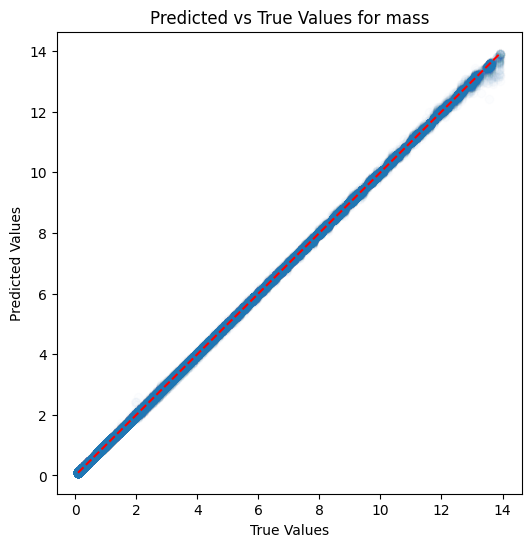

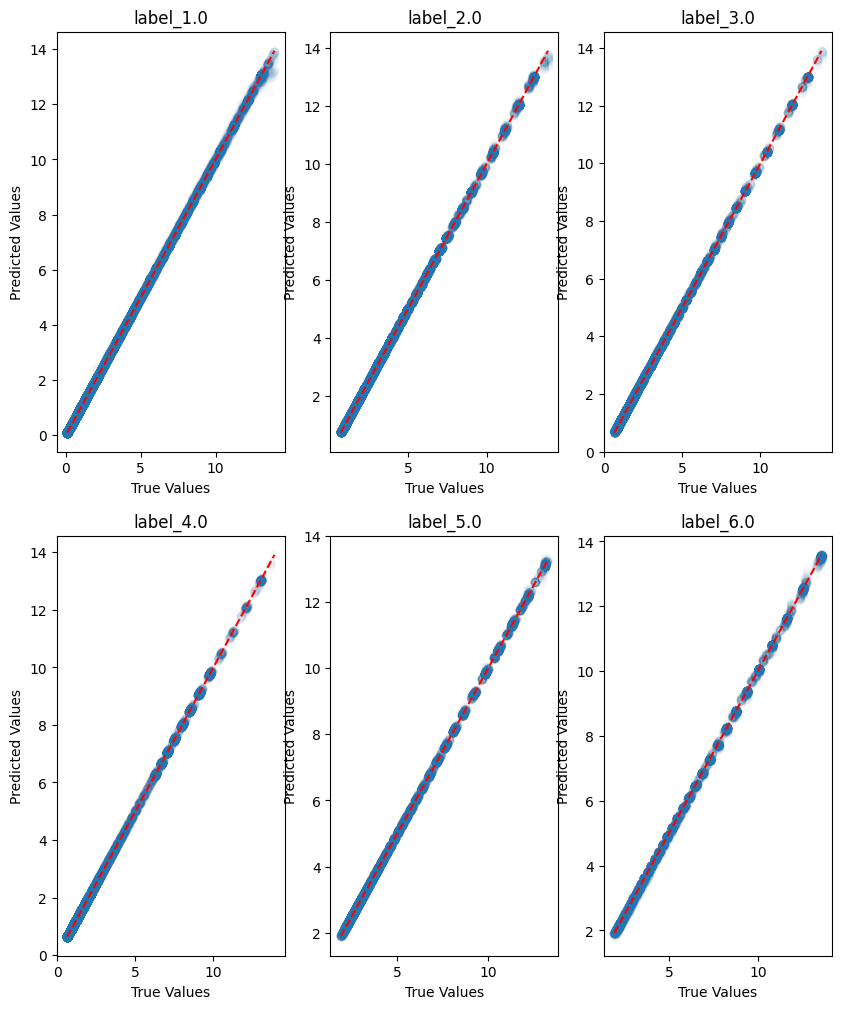

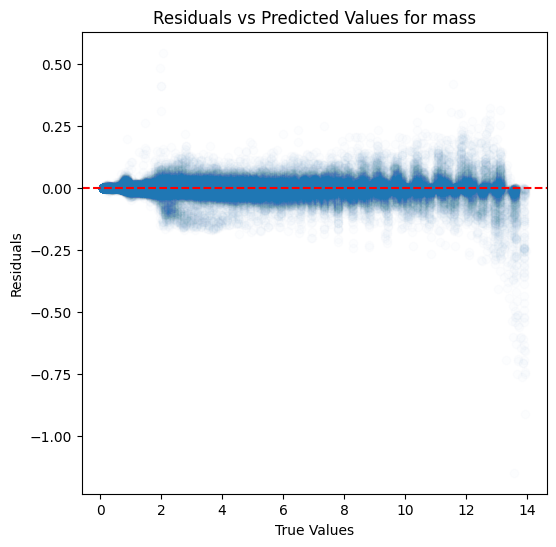

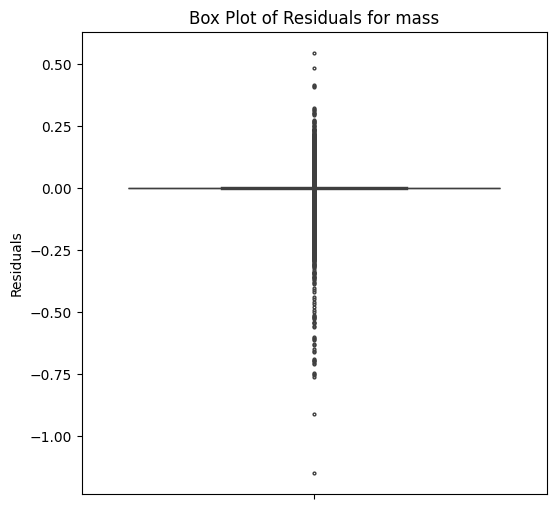

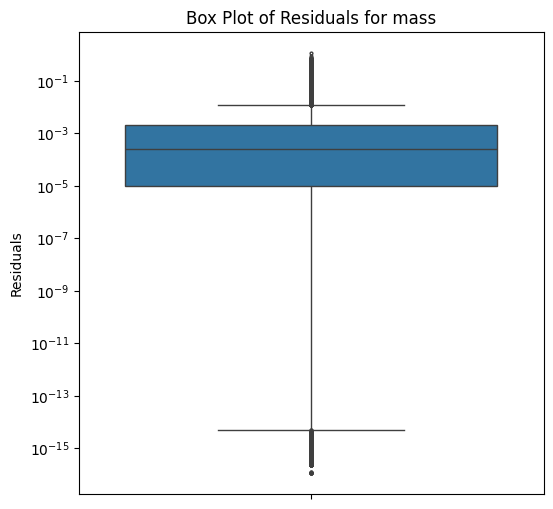

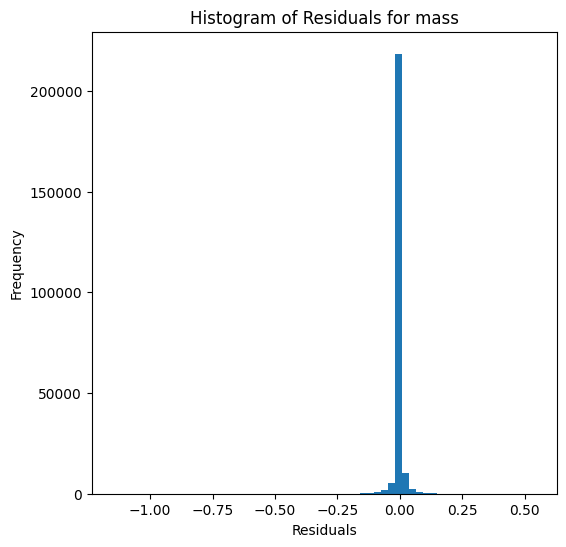

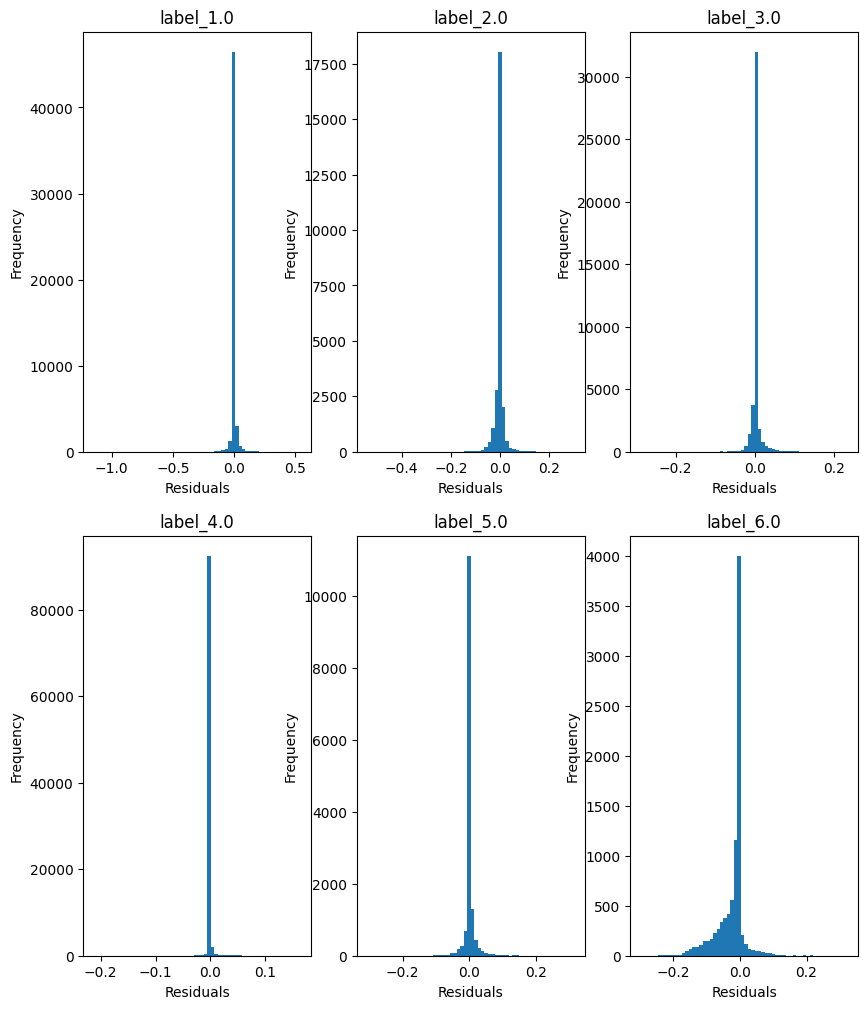

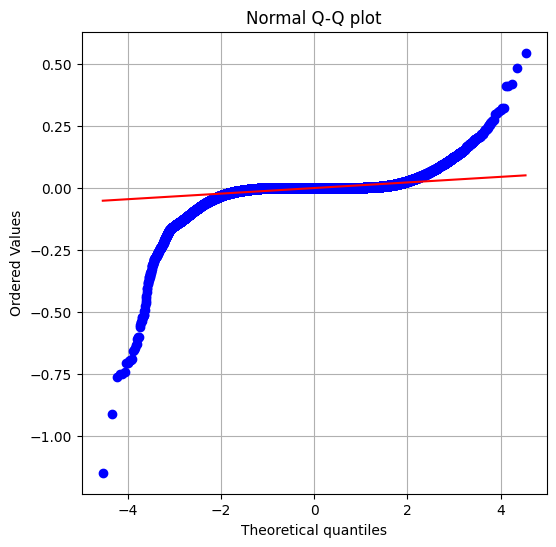

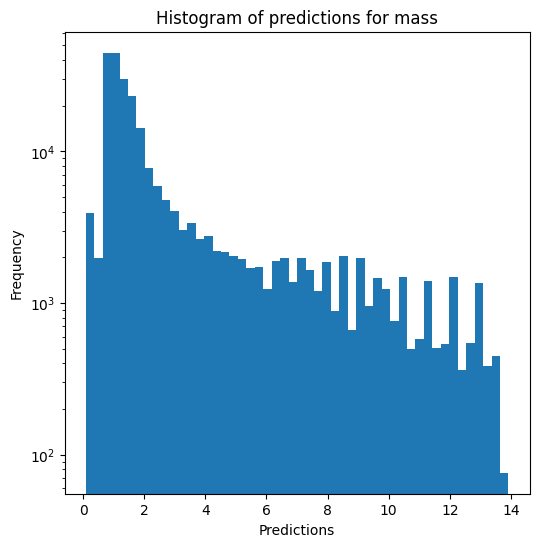

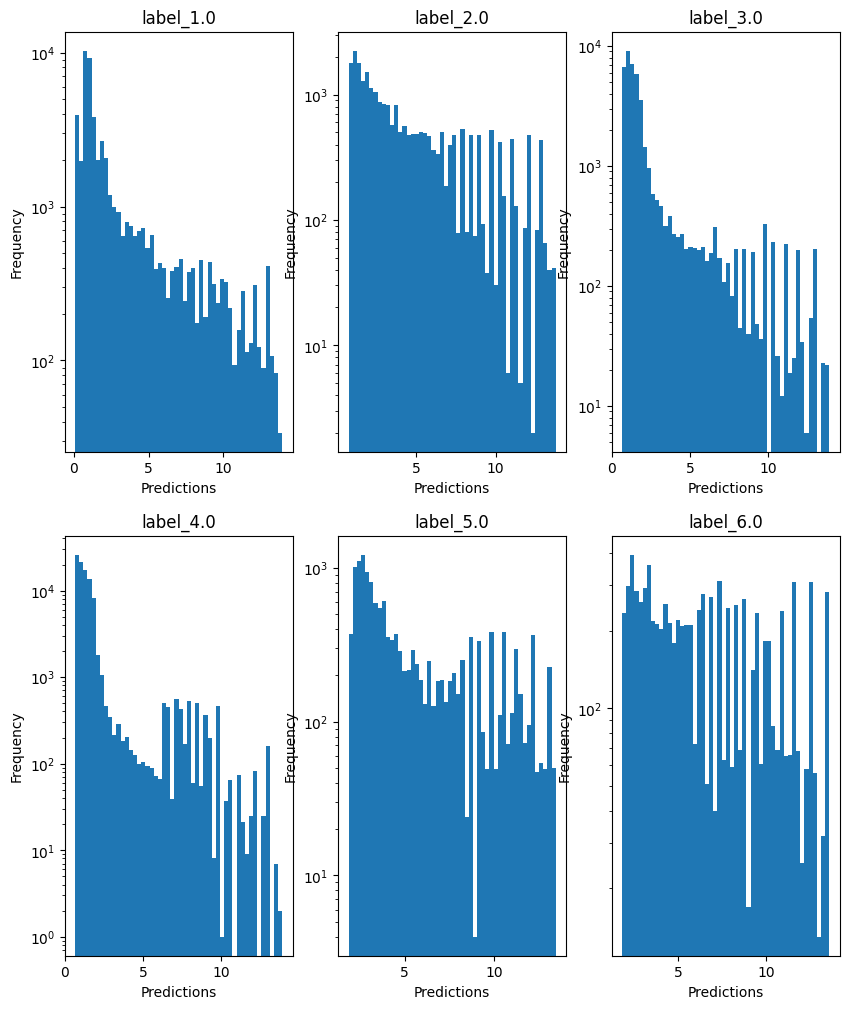

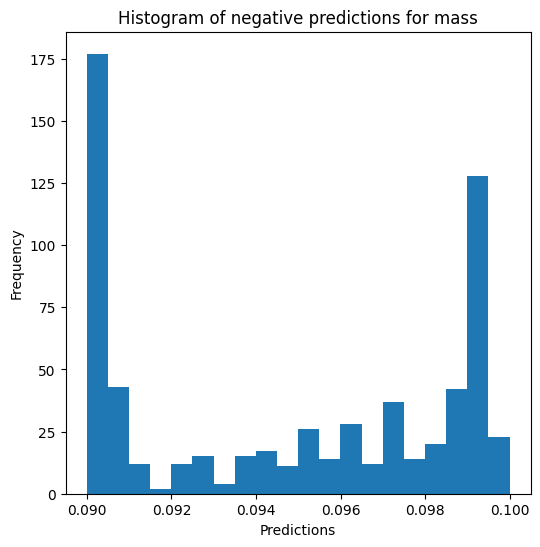


radius results for the label category with a value of 1.0
  value range :  -0.9763360818022064 - 1.1687920203141815
  RVE :  0.999946245719329
  RMSE :  0.0026943216430393904
  MAE :  0.001131552698957229
  MedAE :  0.00027549895772979727
  CORR :  0.9999732216174783
  MAX_ER :  0.10070950212057839
  Percentiles : 
    75th percentile :  0.0010712521329648977
    90th percentile :  0.0031167754963525307
    95th percentile :  0.00516577552029459
    99th percentile :  0.01151641586205563

radius results for the label category with a value of 2.0
  value range :  0.0199466816788423 - 2.458486763798206
  RVE :  0.9998393268091578
  RMSE :  0.0069387342302438286
  MAE :  0.002673895868527987
  MedAE :  0.0007087099651679474
  CORR :  0.9999302978473399
  MAX_ER :  0.1817154715514524
  Percentiles : 
    75th percentile :  0.002573843311380969
    90th percentile :  0.006887738102158076
    95th percentile :  0.01109193481667007
    99th percentile :  0.026065857441234196

radius results 

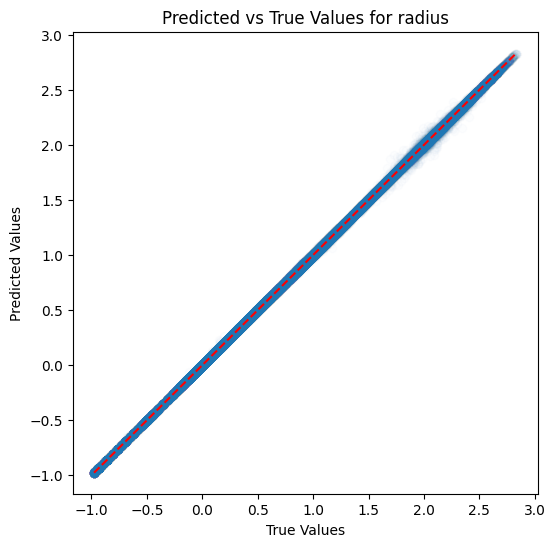

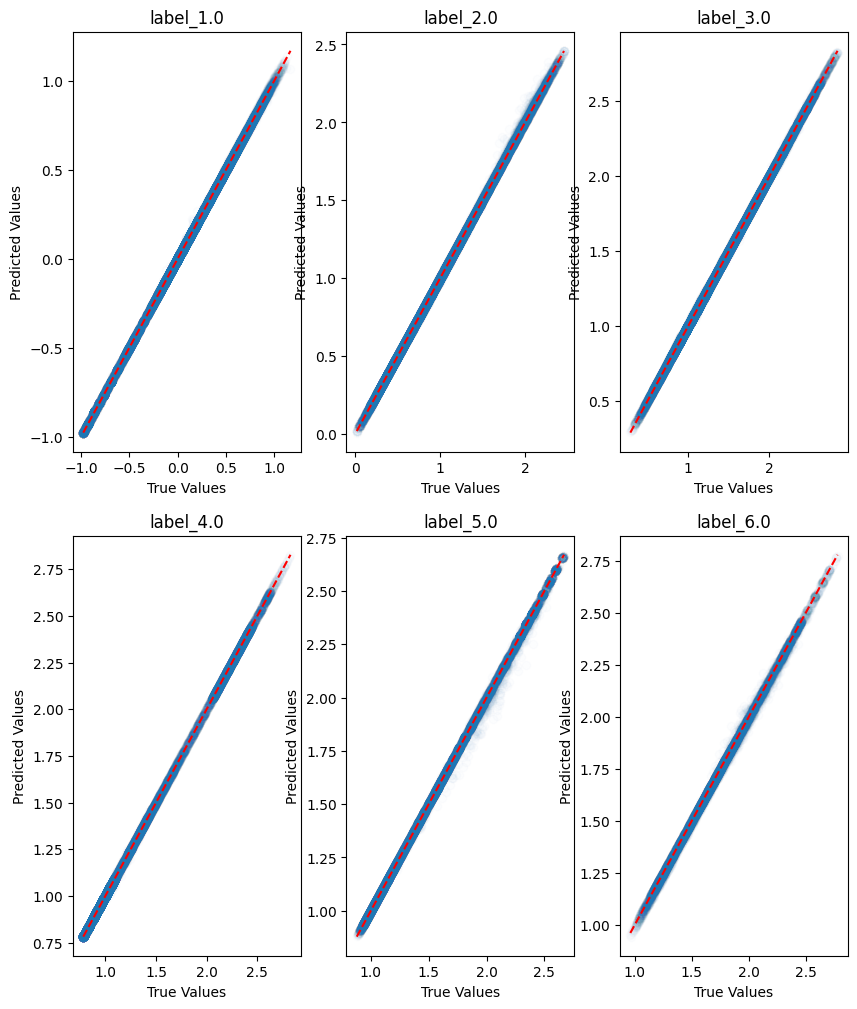

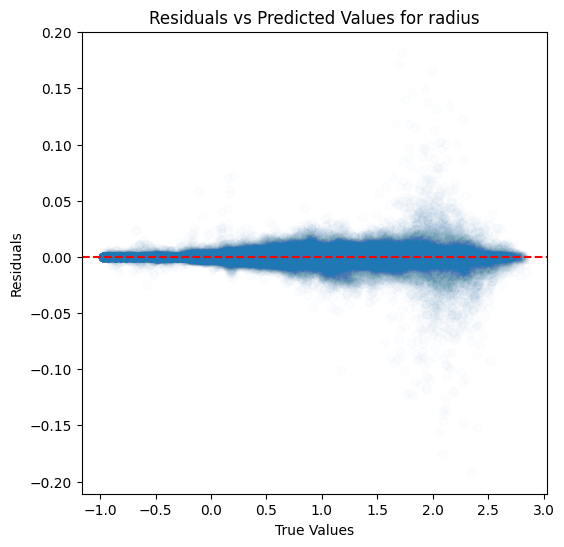

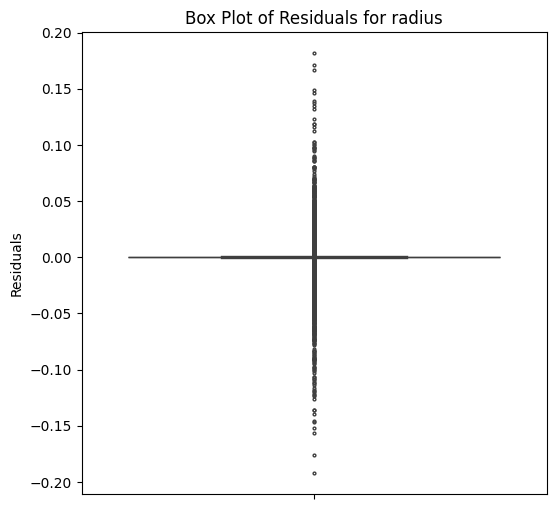

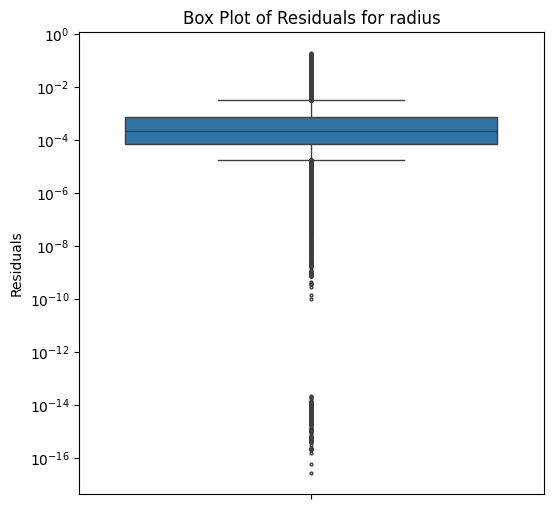

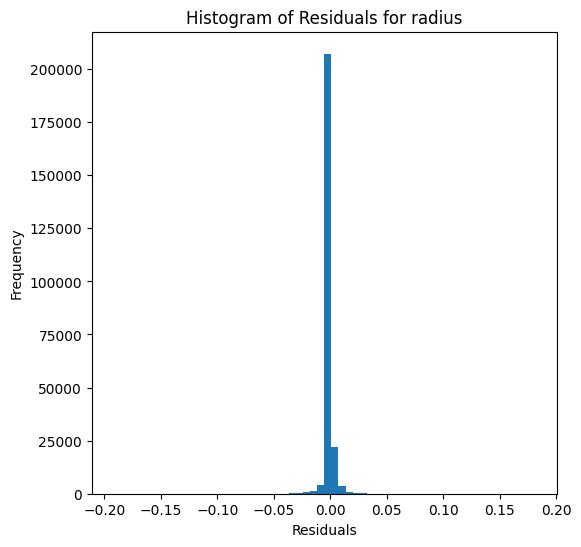

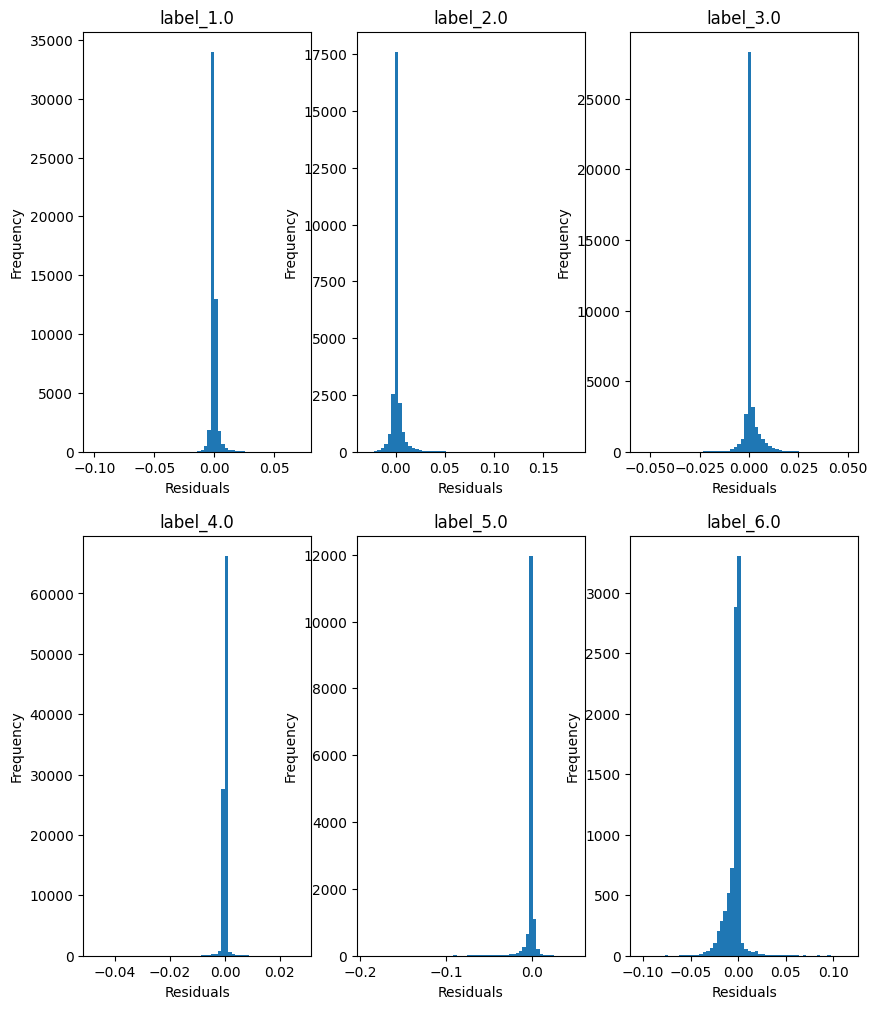

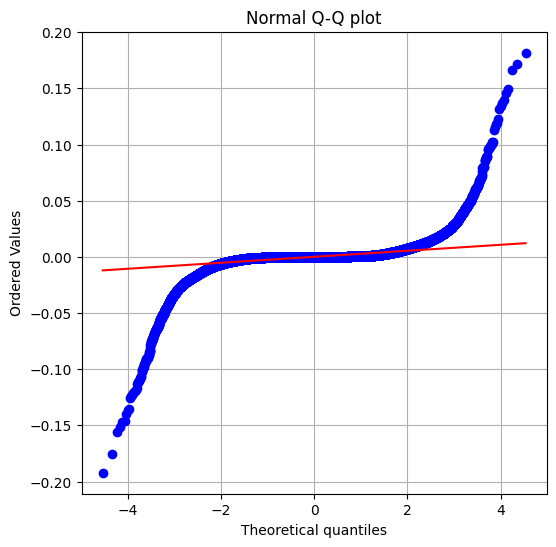

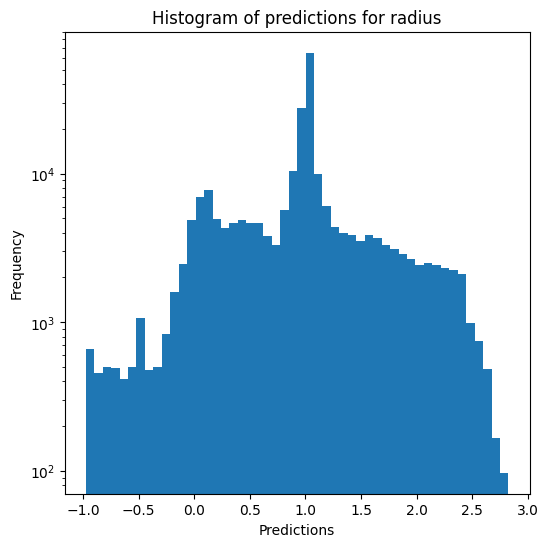

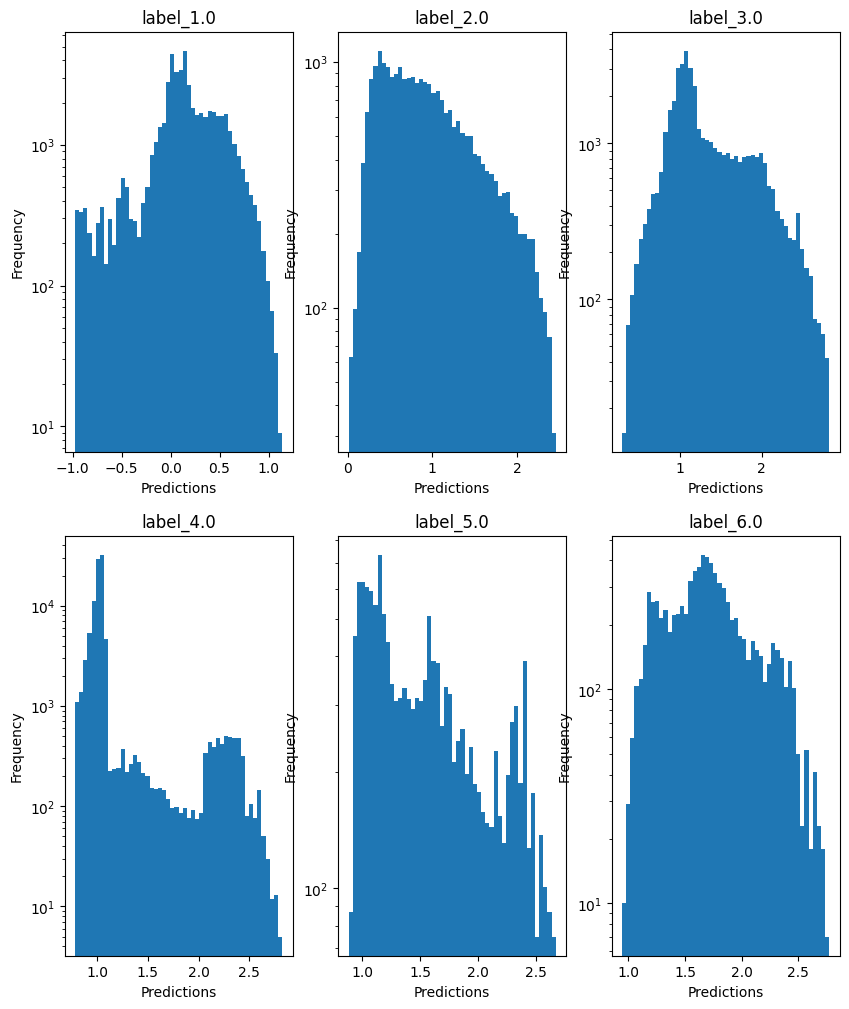

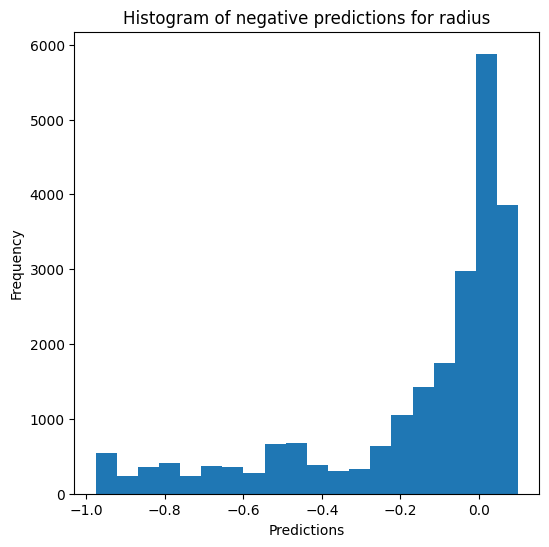

Saving predictions and results...


In [26]:
best_params_RF = {'n_jobs':10, 'n_estimators': 400, 'criterion': 'squared_error', 'max_depth': 100, 'min_samples_leaf': 1, 'min_samples_split': 2, 'max_features': 'sqrt', 'max_leaf_nodes': None}
# 'max_features': 'sqrt' gives better results for radius and for mass (except MAX_ER)
print(path_to_results)
dt_evaluator = Model_evaluator("random_forest", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)
dt_evaluator.evaluate_Kfold_results(RandomForestRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, **best_params_RF)

../../../../../../results/model_A_partial/fine_tuned_models/

mass_smaller_14 train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...

mass results for the label category with a value of 1.0
  value range :  0.09 - 13.943
  RVE :  0.9998872566406171
  RMSE :  0.032041659726837514
  MAE :  0.008471307861381745
  MedAE :  0.00027250000000006436
  CORR :  0.9999436475134186
  MAX_ER :  0.778342500000031
  Percentiles : 
    75th percentile :  0.003125000000002126
    90th percentile :  0.01868625000001145
    95th percentile :  0.043192500000017064
    99th percentile :  0.1467869375000045

mass results for the label category with a value of 2.0
  value range :  0.726 - 13.901
  RVE :  0.9999727506738502
  RMSE :  0.017516276616107832
  MAE :  0.006819018221327551
  MedAE :  0.0006074999999468034
  CORR :  0.9999864371315673
  MAX_ER :  0.5224425000000252
  Percentiles : 
    75th percentile :  0.006588125000014711
    90th percentile :  0.02135500000000075

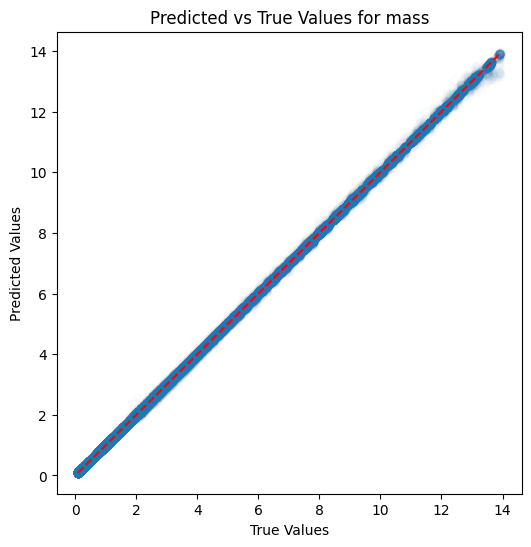

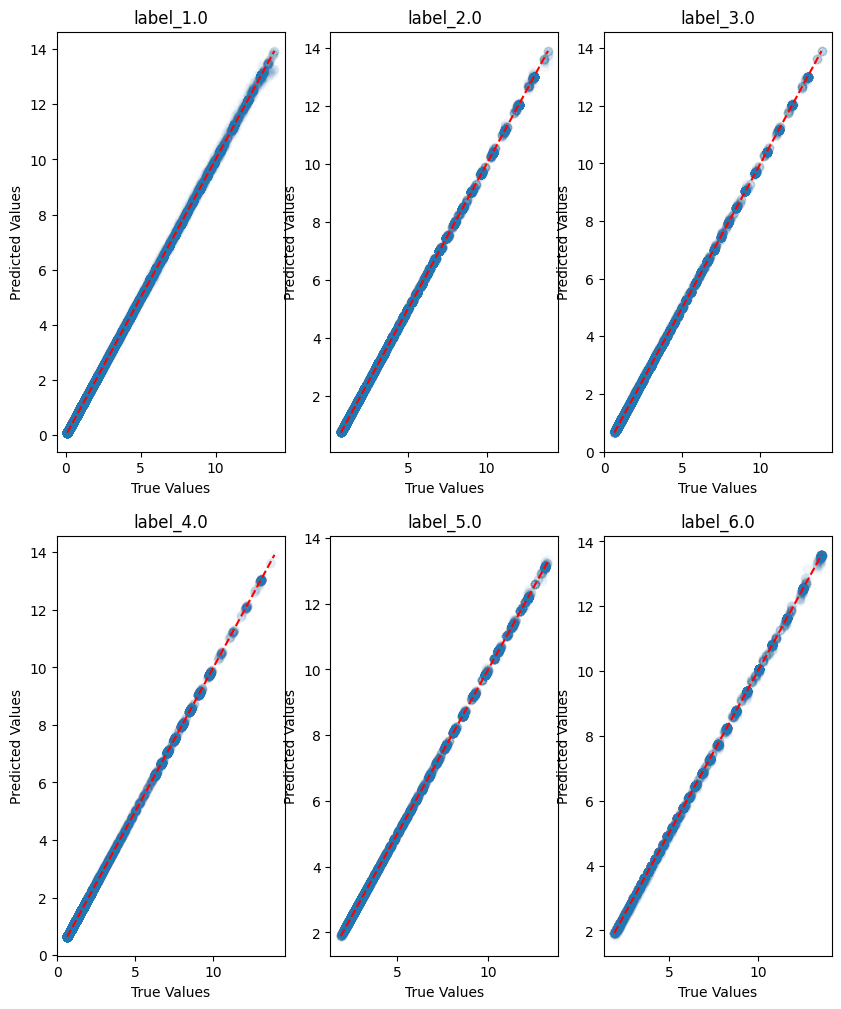

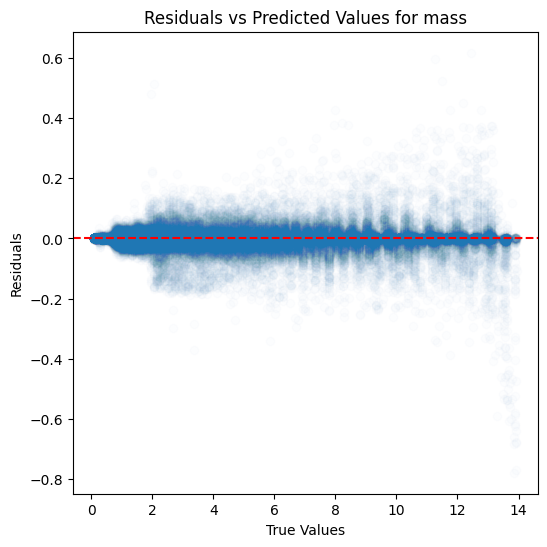

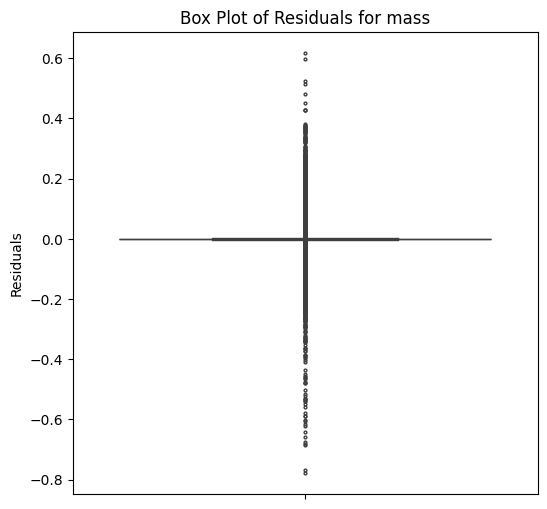

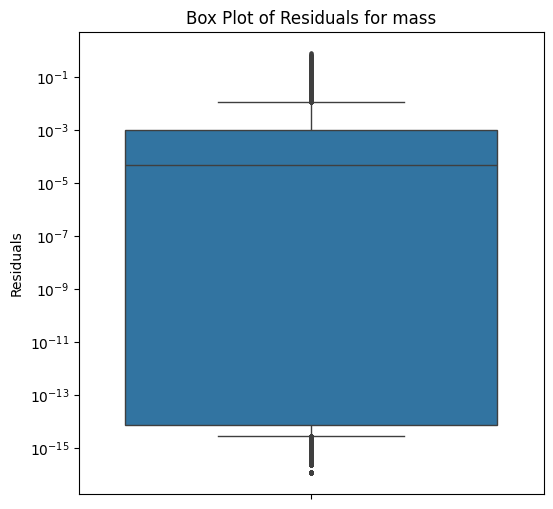

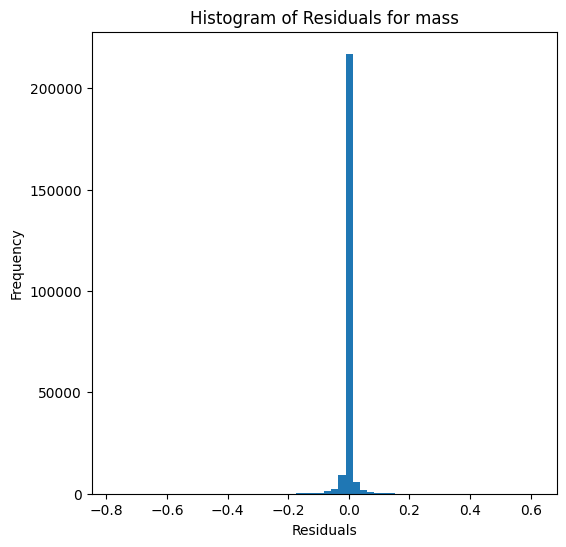

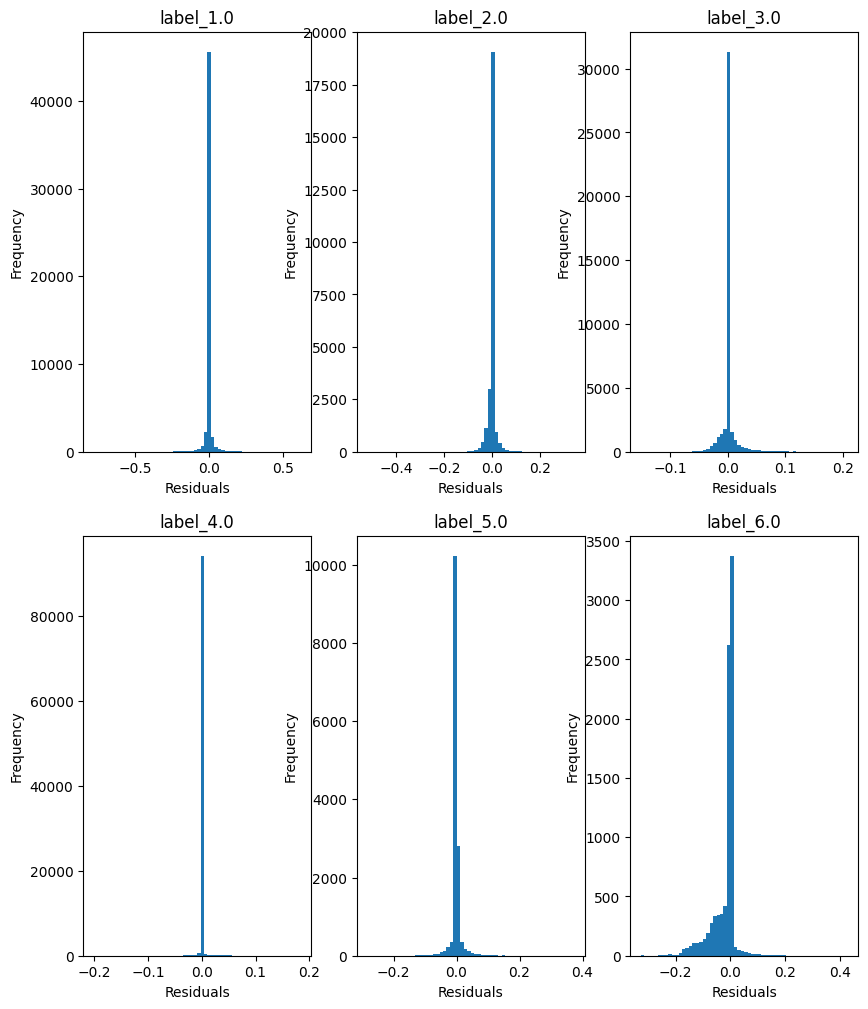

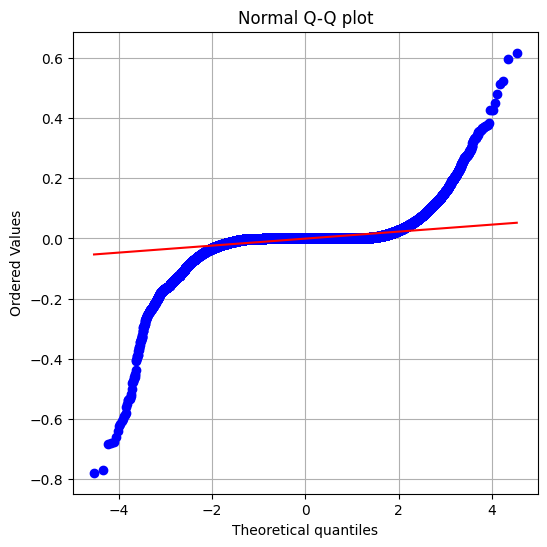

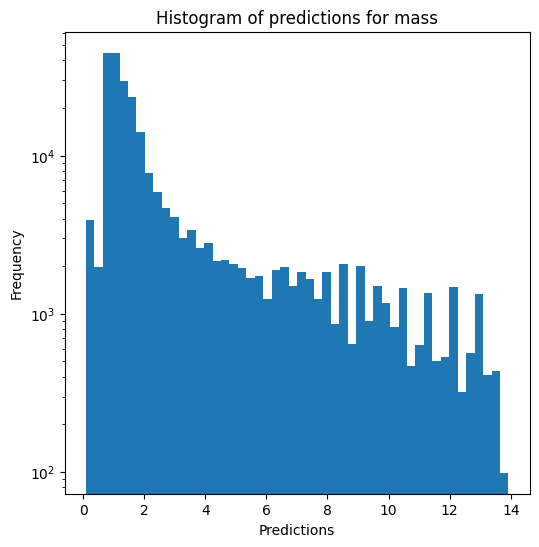

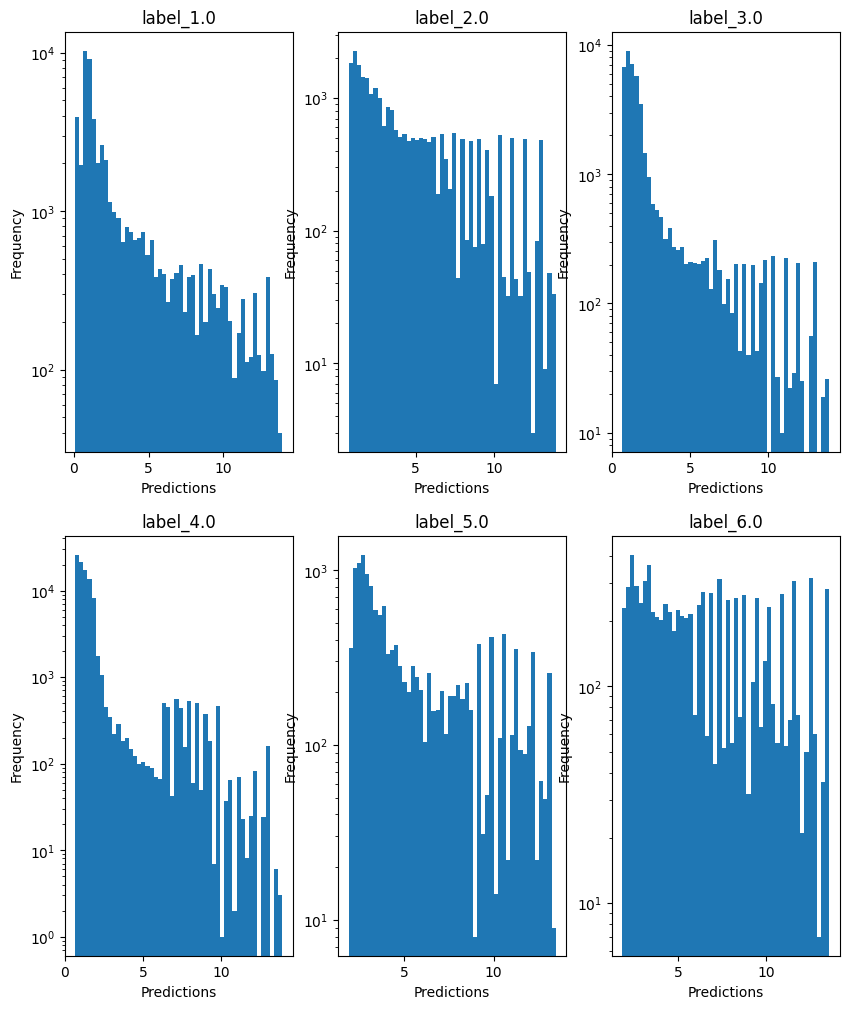

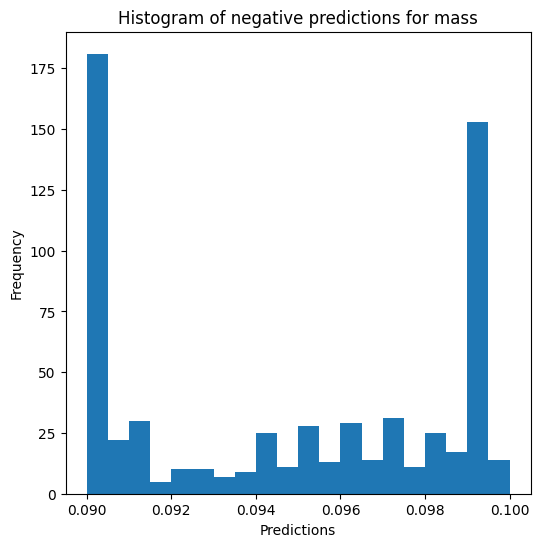


radius results for the label category with a value of 1.0
  value range :  -0.9763360818022064 - 1.1687920203141815
  RVE :  0.9999227763246632
  RMSE :  0.0032160711541943973
  MAE :  0.0012692238407340957
  MedAE :  0.00015482290066035076
  CORR :  0.9999614625146352
  MAX_ER :  0.06998590650205738
  Percentiles : 
    75th percentile :  0.0010415157589484247
    90th percentile :  0.0038293147370051517
    95th percentile :  0.006505864373053727
    99th percentile :  0.014245422313761972

radius results for the label category with a value of 2.0
  value range :  0.0199466816788423 - 2.458486763798206
  RVE :  0.9997715883199947
  RMSE :  0.00820975379495982
  MAE :  0.0027305308057261673
  MedAE :  0.00036061495653433306
  CORR :  0.9998901907911265
  MAX_ER :  0.2723215984527516
  Percentiles : 
    75th percentile :  0.0026099400072573387
    90th percentile :  0.007562199741607811
    95th percentile :  0.01165783173371119
    99th percentile :  0.028202745041554587

radius res

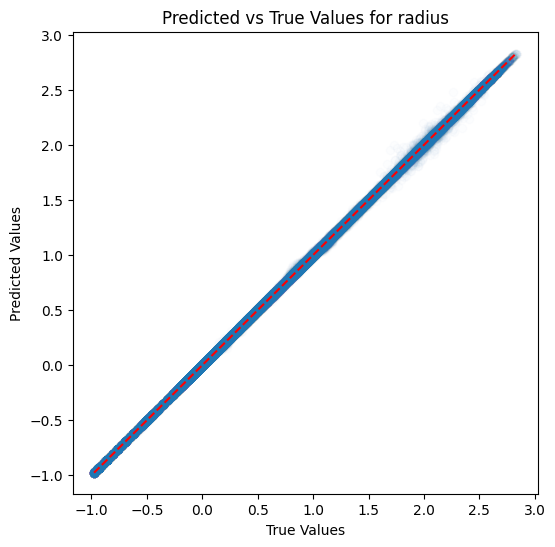

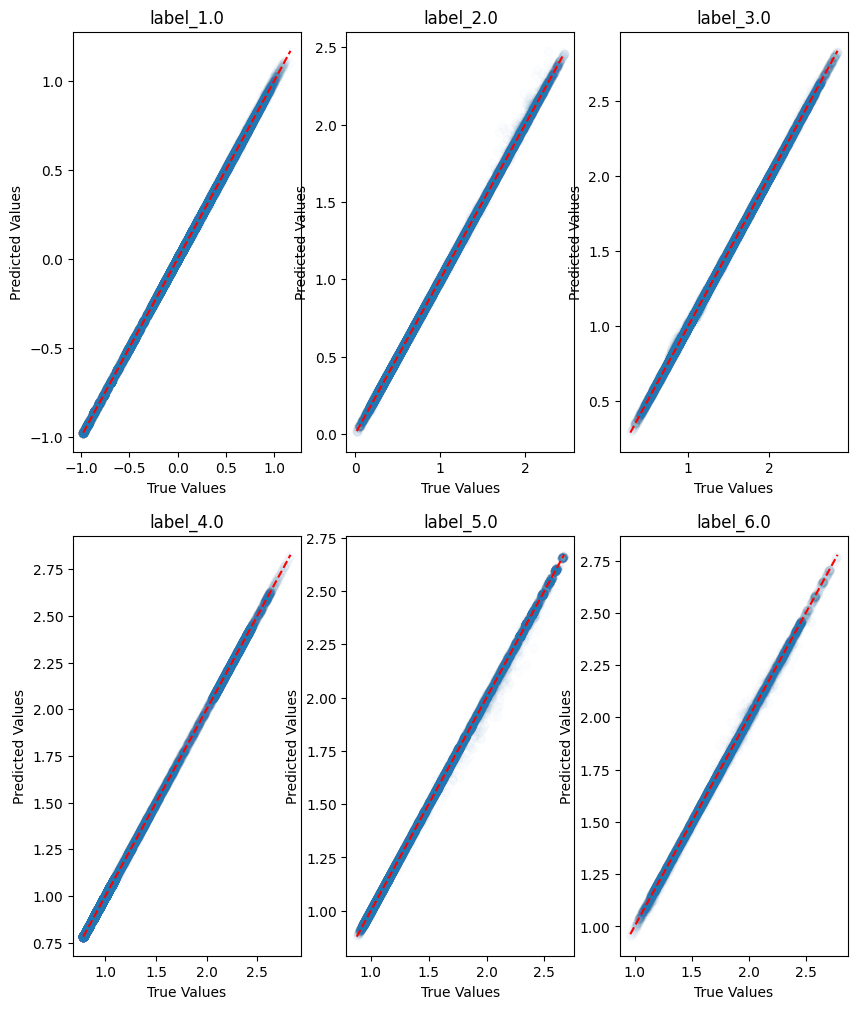

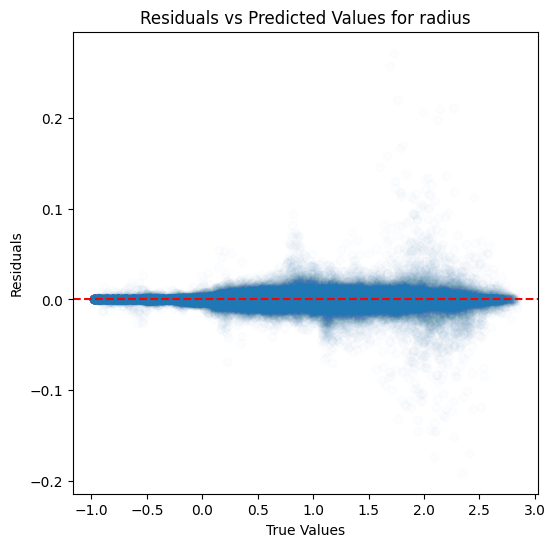

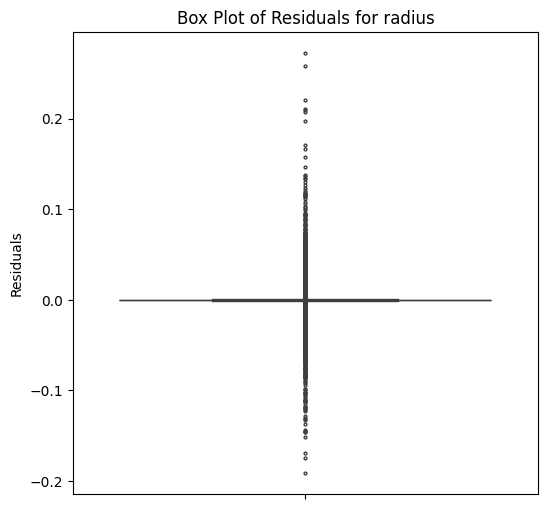

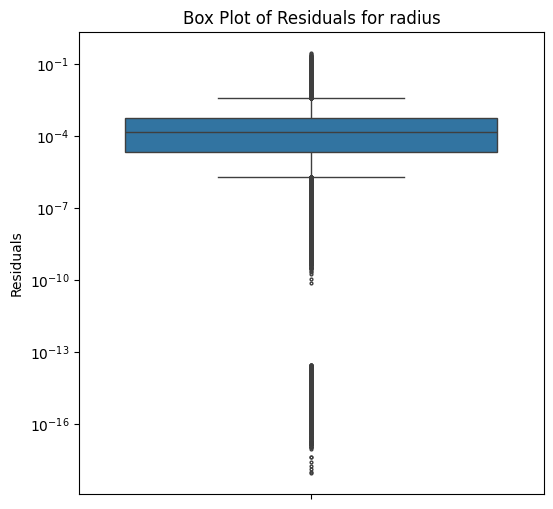

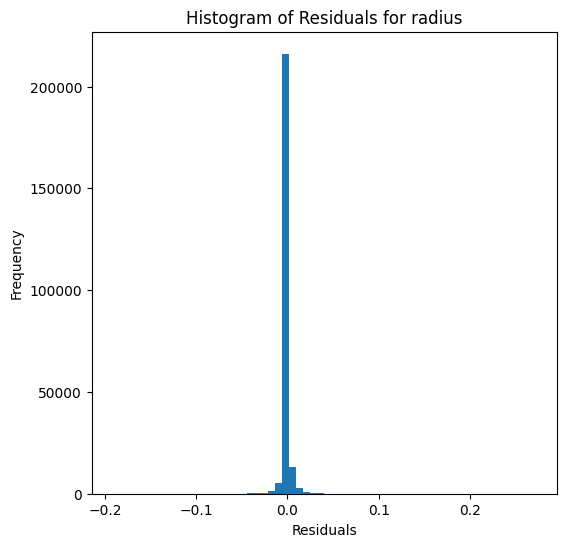

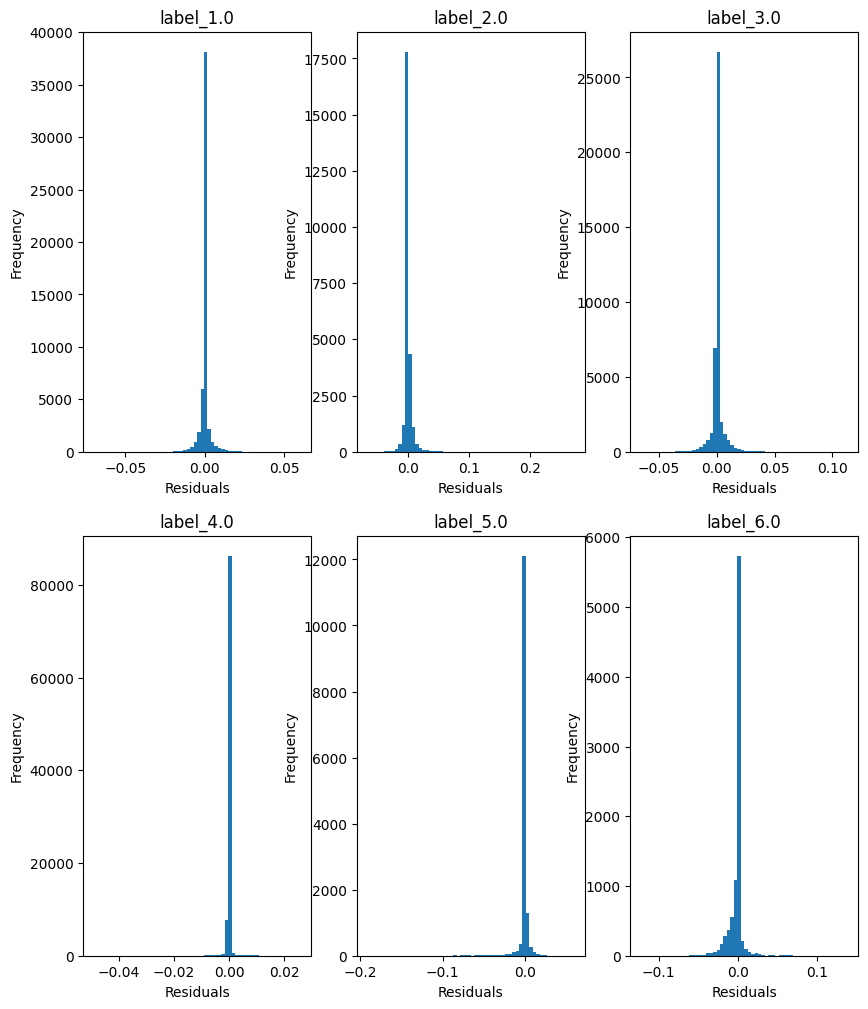

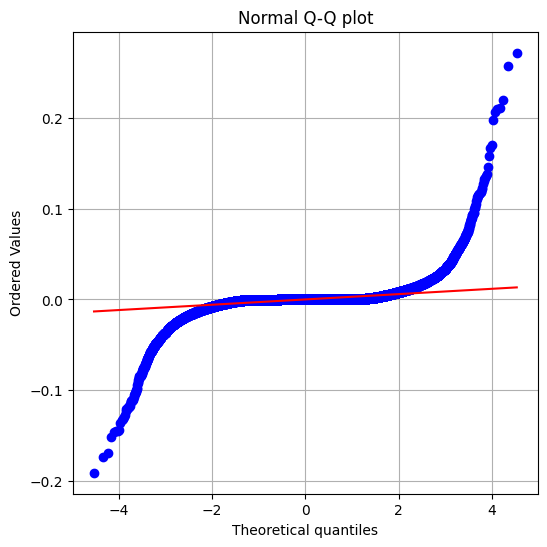

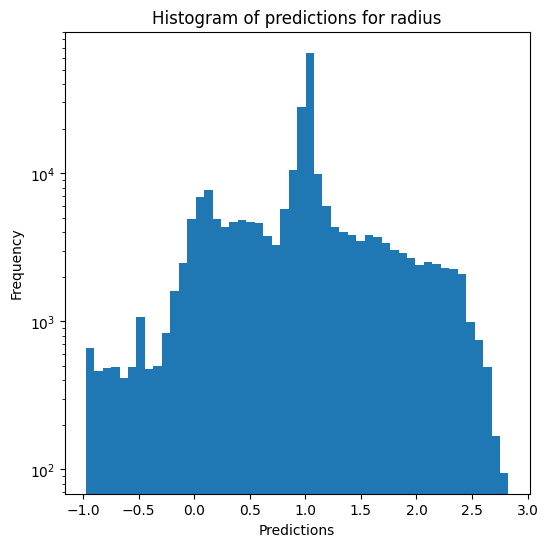

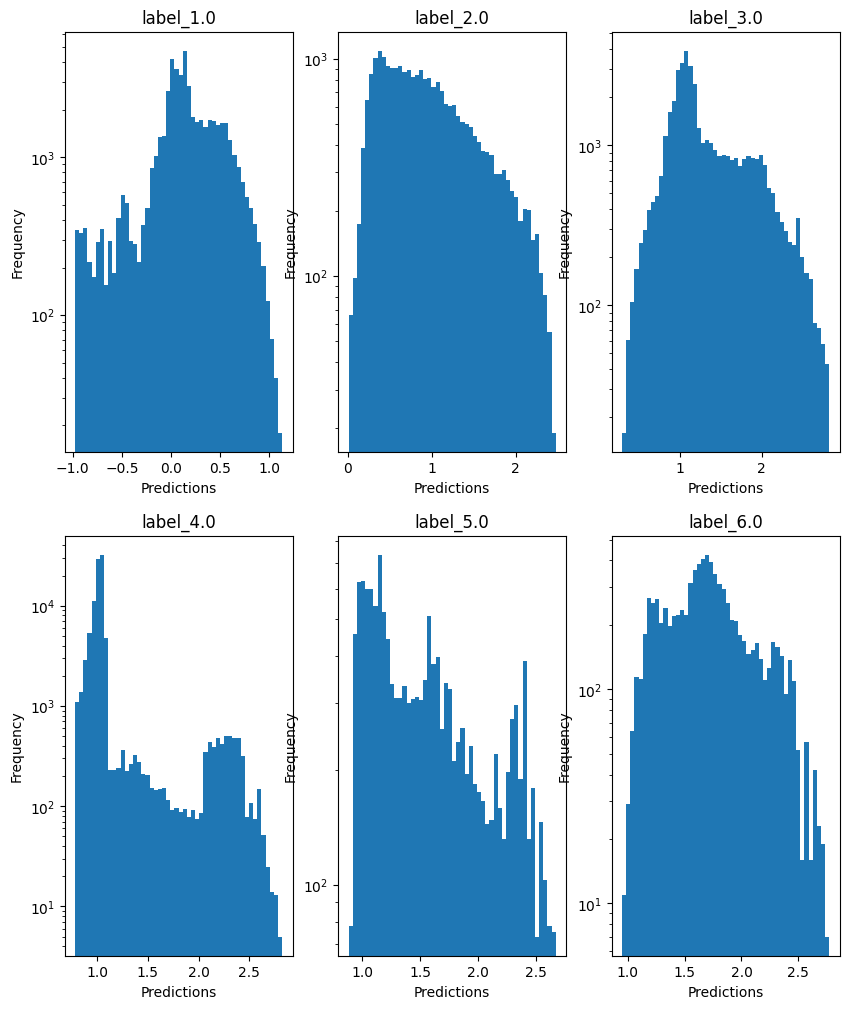

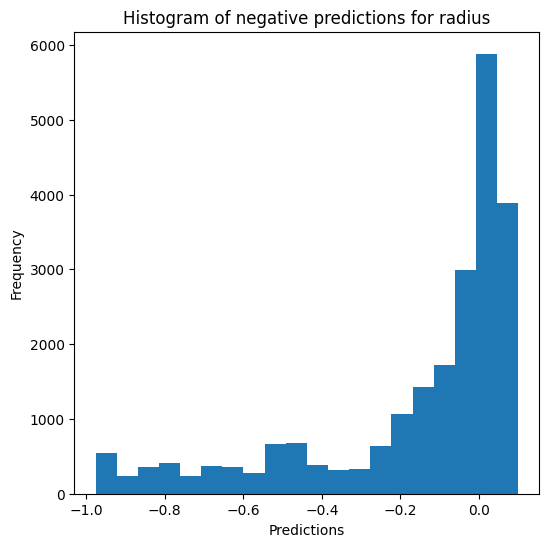

In [ ]:
# best_params_RF = {'n_jobs':10, 'n_estimators': 400, 'criterion': 'squared_error', 'max_depth': 100, 'min_samples_leaf': 1, 'min_samples_split': 2, 'max_features': None, 'max_leaf_nodes': None}

# print(path_to_results)
# dt_evaluator = Model_evaluator("random_forest", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)
# dt_evaluator.evaluate_Kfold_results(RandomForestRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, **best_params_RF)

### K nearest neighbours

In [ ]:
tag = "scale_standard"

#### Testing the uniform weights with brute strength

In [45]:
cv_params = {'n_neighbors' : [5, 10, 20, 30, 50],
             'weights' : ["uniform"],
             'algorithm' : ["brute"]
            }

gscv_rmse = GridSearchCV(KNeighborsRegressor(n_jobs = 10,
                                             ),
                         param_grid = cv_params,
                         scoring = scoring,
                         cv = 10,
                         verbose = 2,
                         refit="neg_root_mean_squared_error"
)

gscv_rmse.fit(X_train_standard, y_train)
display_grid_search(gscv_rmse)

Fitting 10 folds for each of 5 candidates, totalling 50 fits
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   3.7s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   1.7s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   1.7s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   1.8s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   1.7s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   1.7s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   1.7s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   1.8s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   1.7s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   1.8s
[CV] END ...algorithm=brute, n_neighbors=10, weights=uniform; total time=   1.7s
[CV] END ...algorithm=brute, n_neighbors=10, wei

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_algorithm,param_n_neighbors,param_weights,params,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,split3_test_neg_root_mean_squared_error,split4_test_neg_root_mean_squared_error,split5_test_neg_root_mean_squared_error,split6_test_neg_root_mean_squared_error,split7_test_neg_root_mean_squared_error,split8_test_neg_root_mean_squared_error,split9_test_neg_root_mean_squared_error,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,split0_test_neg_mean_absolute_error,split1_test_neg_mean_absolute_error,split2_test_neg_mean_absolute_error,split3_test_neg_mean_absolute_error,split4_test_neg_mean_absolute_error,split5_test_neg_mean_absolute_error,split6_test_neg_mean_absolute_error,split7_test_neg_mean_absolute_error,split8_test_neg_mean_absolute_error,split9_test_neg_mean_absolute_error,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
0,0.009206,0.005618,2.027691,0.582310,brute,5,uniform,"{'algorithm': 'brute', 'n_neighbors': 5, 'weig...",-0.044237,-0.044884,-0.044712,-0.043480,-0.043566,-0.044364,-0.042922,-0.045579,-0.043018,-0.043856,-0.044062,0.000809,1,-0.014535,-0.014688,-0.014606,-0.014651,-0.014559,-0.014730,-0.014555,-0.014901,-0.014416,-0.014801,-0.014644,0.000134,1
1,0.007277,0.000869,1.800282,0.030468,brute,10,uniform,"{'algorithm': 'brute', 'n_neighbors': 10, 'wei...",-0.049687,-0.049987,-0.051204,-0.048870,-0.049231,-0.050105,-0.048627,-0.050845,-0.048876,-0.050442,-0.049787,0.000839,2,-0.015640,-0.015777,-0.016041,-0.015672,-0.015801,-0.015822,-0.015545,-0.016033,-0.015570,-0.015989,-0.015789,0.000175,2
2,0.007011,0.001046,1.841902,0.043467,brute,20,uniform,"{'algorithm': 'brute', 'n_neighbors': 20, 'wei...",-0.062260,-0.063315,-0.064380,-0.062579,-0.063570,-0.064455,-0.062036,-0.064008,-0.061550,-0.064578,-0.063273,0.001047,3,-0.020150,-0.020606,-0.020797,-0.020305,-0.020735,-0.020607,-0.020329,-0.020612,-0.020247,-0.020790,-0.020518,0.000226,3
3,0.007466,0.000285,1.838180,0.030548,brute,30,uniform,"{'algorithm': 'brute', 'n_neighbors': 30, 'wei...",-0.071234,-0.072351,-0.073718,-0.072190,-0.073294,-0.074070,-0.072508,-0.073658,-0.071062,-0.073692,-0.072778,0.001018,4,-0.023708,-0.024247,-0.024457,-0.024184,-0.024593,-0.024280,-0.024093,-0.024294,-0.024124,-0.024376,-0.024236,0.000227,4
4,0.007128,0.000670,1.866608,0.031969,brute,50,uniform,"{'algorithm': 'brute', 'n_neighbors': 50, 'wei...",-0.083069,-0.085054,-0.085657,-0.084079,-0.085561,-0.085475,-0.084395,-0.084843,-0.083516,-0.085392,-0.084704,0.000862,5,-0.029709,-0.030612,-0.030205,-0.030209,-0.030725,-0.030198,-0.029978,-0.030140,-0.030205,-0.030226,-0.030221,0.000271,5


Best parameters {'algorithm': 'brute', 'n_neighbors': 5, 'weights': 'uniform'}
Best score -0.044061760310867955


In [46]:
cv_params = {'n_neighbors' : [5, 10, 20, 30, 50],
             'weights' : ["uniform"],
             'algorithm' : ["brute"]
            }

gscv_max_er = GridSearchCV(KNeighborsRegressor(n_jobs = 10,
                                             ),
                         param_grid = cv_params,
                         scoring = max_err_scorer,
                         cv = 10,
                         verbose = 2,
                         refit=True
)

gscv_max_er.fit(X_train_standard, y_train)
display_grid_search(gscv_max_er)

Fitting 10 folds for each of 5 candidates, totalling 50 fits
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   1.7s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   1.8s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   1.8s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   1.7s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   1.7s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   1.7s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   1.7s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   1.8s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   1.7s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   1.7s
[CV] END ...algorithm=brute, n_neighbors=10, weights=uniform; total time=   1.7s
[CV] END ...algorithm=brute, n_neighbors=10, wei

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_algorithm,param_n_neighbors,param_weights,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score,rank_test_score
0,0.006758,0.000814,1.825152,0.047699,brute,5,uniform,"{'algorithm': 'brute', 'n_neighbors': 5, 'weig...",-1.607400,-1.503600,-1.60760,-1.53180,-1.416200,-1.44060,-1.511000,-1.296000,-1.615000,-1.201200,-1.473040,0.131020,1
1,0.007022,0.000857,1.803934,0.035806,brute,10,uniform,"{'algorithm': 'brute', 'n_neighbors': 10, 'wei...",-1.715200,-1.831400,-1.70370,-1.88990,-2.227900,-1.45510,-1.520200,-1.821900,-1.712900,-1.738400,-1.761660,0.200758,2
2,0.007157,0.000799,1.606020,0.038477,brute,20,uniform,"{'algorithm': 'brute', 'n_neighbors': 20, 'wei...",-2.097700,-2.170200,-1.92645,-1.77180,-2.631000,-2.23120,-1.824750,-1.755050,-2.054450,-2.000900,-2.046350,0.248959,3
3,0.007165,0.000707,1.718846,0.139924,brute,30,uniform,"{'algorithm': 'brute', 'n_neighbors': 30, 'wei...",-2.152667,-2.200833,-2.06490,-1.88170,-2.459767,-2.31750,-1.934233,-2.082433,-2.077833,-2.166867,-2.133873,0.161196,4
4,0.007283,0.000855,1.869959,0.023075,brute,50,uniform,"{'algorithm': 'brute', 'n_neighbors': 50, 'wei...",-1.901960,-2.103600,-2.00664,-1.84868,-2.651620,-2.45364,-2.108500,-2.437760,-2.157900,-2.409200,-2.207950,0.252396,5


Best parameters {'algorithm': 'brute', 'n_neighbors': 5, 'weights': 'uniform'}
Best score -1.473040000000001


Best parameters {'algorithm': 'brute', 'n_neighbors': 5, 'weights': 'uniform'}

Best rmse -0.044061760310867955

Best parameters {'algorithm': 'brute', 'n_neighbors': 5, 'weights': 'uniform'}

Best score -1.473040000000001

#### Testing the uniform weights with algorithms

In [47]:
cv_params = {'n_neighbors' : [5, 10, 20, 30, 50],
             'weights' : ["uniform"],
             'algorithm' : ["ball_tree", "kd_tree"],
             'leaf_size' : [15, 30, 50, 75, 100]
            }

gscv_rmse = GridSearchCV(KNeighborsRegressor(n_jobs = 5,
                                             ),
                         param_grid = cv_params,
                         scoring = scoring,
                         cv = 10,
                         verbose = 2,
                         refit="neg_root_mean_squared_error"
)

gscv_rmse.fit(X_train_standard, y_train)
display_grid_search(gscv_rmse)

Fitting 10 folds for each of 50 candidates, totalling 500 fits
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   0.6s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   0.6s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   0.7s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   0.8s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   0.8s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   0.8s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   0.8s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   0.7s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   0.7s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total 

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_algorithm,param_leaf_size,param_n_neighbors,param_weights,params,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,split3_test_neg_root_mean_squared_error,split4_test_neg_root_mean_squared_error,split5_test_neg_root_mean_squared_error,split6_test_neg_root_mean_squared_error,split7_test_neg_root_mean_squared_error,split8_test_neg_root_mean_squared_error,split9_test_neg_root_mean_squared_error,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,split0_test_neg_mean_absolute_error,split1_test_neg_mean_absolute_error,split2_test_neg_mean_absolute_error,split3_test_neg_mean_absolute_error,split4_test_neg_mean_absolute_error,split5_test_neg_mean_absolute_error,split6_test_neg_mean_absolute_error,split7_test_neg_mean_absolute_error,split8_test_neg_mean_absolute_error,split9_test_neg_mean_absolute_error,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
0,0.137379,0.006770,0.701936,0.072172,ball_tree,15,5,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.044224,-0.044897,-0.044713,-0.043479,-0.043566,-0.044364,-0.042921,-0.045579,-0.043018,-0.043858,-0.044062,0.000810,8,-0.014528,-0.014693,-0.014608,-0.014650,-0.014559,-0.014731,-0.014555,-0.014902,-0.014415,-0.014803,-0.014644,0.000136,4
1,0.139269,0.008526,0.847917,0.059934,ball_tree,15,10,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.049687,-0.049986,-0.051204,-0.048869,-0.049231,-0.050106,-0.048627,-0.050844,-0.048875,-0.050442,-0.049787,0.000839,14,-0.015641,-0.015775,-0.016041,-0.015671,-0.015801,-0.015824,-0.015545,-0.016032,-0.015571,-0.015989,-0.015789,0.000175,20
2,0.139447,0.017049,0.929654,0.065982,ball_tree,15,20,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.062263,-0.063315,-0.064377,-0.062579,-0.063570,-0.064455,-0.062021,-0.064008,-0.061550,-0.064578,-0.063272,0.001048,28,-0.020153,-0.020607,-0.020794,-0.020307,-0.020735,-0.020607,-0.020327,-0.020612,-0.020246,-0.020789,-0.020518,0.000226,21
3,0.141487,0.014930,1.038157,0.076518,ball_tree,15,30,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.071231,-0.072351,-0.073717,-0.072190,-0.073294,-0.074071,-0.072508,-0.073660,-0.071062,-0.073693,-0.072777,0.001019,36,-0.023707,-0.024247,-0.024455,-0.024183,-0.024593,-0.024280,-0.024092,-0.024296,-0.024124,-0.024377,-0.024235,0.000227,36
4,0.147955,0.016755,1.171924,0.072084,ball_tree,15,50,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.083069,-0.085052,-0.085658,-0.084079,-0.085560,-0.085475,-0.084395,-0.084843,-0.083516,-0.085392,-0.084704,0.000861,43,-0.029709,-0.030611,-0.030205,-0.030209,-0.030725,-0.030198,-0.029977,-0.030140,-0.030205,-0.030225,-0.030220,0.000271,44
5,0.124642,0.008959,0.905173,0.057685,ball_tree,30,5,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 30, 'n...",-0.044224,-0.044897,-0.044713,-0.043479,-0.043566,-0.044364,-0.042921,-0.045579,-0.043018,-0.043858,-0.044062,0.000810,5,-0.014528,-0.014693,-0.014608,-0.014650,-0.014559,-0.014731,-0.014555,-0.014902,-0.014416,-0.014803,-0.014644,0.000136,5
6,0.124041,0.012903,0.961806,0.045982,ball_tree,30,10,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 30, 'n...",-0.049687,-0.049986,-0.051204,-0.048869,-0.049231,-0.050106,-0.048627,-0.050844,-0.048875,-0.050442,-0.049787,0.000839,17,-0.015641,-0.015775,-0.016041,-0.015671,-0.015801,-0.015824,-0.015545,-0.016032,-0.015571,-0.015989,-0.015789,0.000175,15
7,0.140996,0.014849,1.110245,0.041988,ball_tree,30,20,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 30, 'n...",-0.062263,-0.063315,-0.064377,-0.062579,-0.063570,-0.064455,-0.062021,-0.064008,-0.061550,-0.064578,-0.063272,0.001048,21,-0.020153,-0.020607,-0.020794,-0.020307,-0.020735,-0.020607,-0.020327,-0.020612,-0.020247,-0.020789,-0.020518,0.000226,23
8,0.135959,0.013291,1.253017,0.090886,

Best parameters {'algorithm': 'kd_tree', 'leaf_size': 75, 'n_neighbors': 5, 'weights': 'uniform'}
Best score -0.04406191750415397


In [49]:
df = pd.DataFrame.from_dict(gscv_rmse.cv_results_)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
display(df.sort_values("rank_test_neg_root_mean_squared_error"))

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_algorithm,param_leaf_size,param_n_neighbors,param_weights,params,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,split3_test_neg_root_mean_squared_error,split4_test_neg_root_mean_squared_error,split5_test_neg_root_mean_squared_error,split6_test_neg_root_mean_squared_error,split7_test_neg_root_mean_squared_error,split8_test_neg_root_mean_squared_error,split9_test_neg_root_mean_squared_error,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,split0_test_neg_mean_absolute_error,split1_test_neg_mean_absolute_error,split2_test_neg_mean_absolute_error,split3_test_neg_mean_absolute_error,split4_test_neg_mean_absolute_error,split5_test_neg_mean_absolute_error,split6_test_neg_mean_absolute_error,split7_test_neg_mean_absolute_error,split8_test_neg_mean_absolute_error,split9_test_neg_mean_absolute_error,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
40,0.145891,0.009865,0.136368,0.006762,kd_tree,75,5,uniform,"{'algorithm': 'kd_tree', 'leaf_size': 75, 'n_n...",-0.044224,-0.044897,-0.044713,-0.043479,-0.043566,-0.044364,-0.042921,-0.045579,-0.043018,-0.043858,-0.044062,0.000810,1,-0.014528,-0.014693,-0.014608,-0.014650,-0.014559,-0.014731,-0.014555,-0.014902,-0.014416,-0.014803,-0.014644,0.000136,7
45,0.198597,0.058192,0.158038,0.019217,kd_tree,100,5,uniform,"{'algorithm': 'kd_tree', 'leaf_size': 100, 'n_...",-0.044224,-0.044897,-0.044713,-0.043479,-0.043566,-0.044364,-0.042921,-0.045579,-0.043018,-0.043858,-0.044062,0.000810,1,-0.014528,-0.014693,-0.014608,-0.014650,-0.014559,-0.014731,-0.014555,-0.014902,-0.014416,-0.014803,-0.014644,0.000136,7
30,0.160026,0.007036,0.101162,0.007197,kd_tree,30,5,uniform,"{'algorithm': 'kd_tree', 'leaf_size': 30, 'n_n...",-0.044224,-0.044897,-0.044713,-0.043479,-0.043566,-0.044364,-0.042921,-0.045579,-0.043018,-0.043858,-0.044062,0.000810,3,-0.014528,-0.014693,-0.014608,-0.014650,-0.014559,-0.014731,-0.014555,-0.014902,-0.014415,-0.014803,-0.014644,0.000136,1
35,0.164651,0.005492,0.111341,0.007633,kd_tree,50,5,uniform,"{'algorithm': 'kd_tree', 'leaf_size': 50, 'n_n...",-0.044224,-0.044897,-0.044713,-0.043479,-0.043566,-0.044364,-0.042921,-0.045579,-0.043018,-0.043858,-0.044062,0.000810,3,-0.014528,-0.014693,-0.014608,-0.014650,-0.014559,-0.014731,-0.014555,-0.014902,-0.014415,-0.014803,-0.014644,0.000136,1
10,0.117993,0.004615,0.891587,0.068528,ball_tree,50,5,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 50, 'n...",-0.044224,-0.044897,-0.044713,-0.043479,-0.043566,-0.044364,-0.042921,-0.045579,-0.043018,-0.043858,-0.044062,0.000810,5,-0.014528,-0.014693,-0.014608,-0.014650,-0.014559,-0.014731,-0.014555,-0.014902,-0.014416,-0.014803,-0.014644,0.000136,5
5,0.124642,0.008959,0.905173,0.057685,ball_tree,30,5,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 30, 'n...",-0.044224,-0.044897,-0.044713,-0.043479,-0.043566,-0.044364,-0.042921,-0.045579,-0.043018,-0.043858,-0.044062,0.000810,5,-0.014528,-0.014693,-0.014608,-0.014650,-0.014559,-0.014731,-0.014555,-0.014902,-0.014416,-0.014803,-0.014644,0.000136,5
25,0.180144,0.004803,0.092339,0.013171,kd_tree,15,5,uniform,"{'algorithm': 'kd_tree', 'leaf_size': 15, 'n_n...",-0.044224,-0.044897,-0.044713,-0.043479,-0.043566,-0.044364,-0.042921,-0.045579,-0.043018,-0.043858,-0.044062,0.000810,7,-0.014528,-0.014693,-0.014608,-0.014650,-0.014559,-0.014731,-0.014555,-0.014902,-0.014416,-0.014803,-0.014644,0.000136,3
0,0.137379,0.006770,0.701936,0.072172,ball_tree,15,5,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.044224,-0.044897,-0.044713,-0.043479,-0.043566,-0.044364,-0.042921,-0.045579,-0.043018,-0.043858,-0.044062,0.000810,8,-0.014528,-0.014693,-0.014608,-0.014650,-0.014559,-0.014731,-0.014555,-0.014902,-0.014415,-0.014803,-0.014644,0.000136,4
15,0.119243,0.013961,1.302252,0.115094,ball_tree,75,5,unifo

In [48]:
cv_params = {'n_neighbors' : [5, 10, 20, 30, 50],
             'weights' : ["uniform"],
             'algorithm' : ["ball_tree", "kd_tree"],
             'leaf_size' : [15, 30, 50, 75, 100]
            }

gscv_max_er = GridSearchCV(KNeighborsRegressor(n_jobs = 5,
                                             ),
                         param_grid = cv_params,
                         scoring = max_err_scorer,
                         cv = 10,
                         verbose = 2,
                         refit=True
)

gscv_max_er.fit(X_train_standard, y_train)
display_grid_search(gscv_max_er)

Fitting 10 folds for each of 50 candidates, totalling 500 fits
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   0.8s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   0.8s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   0.7s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   0.9s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   0.9s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   1.0s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   0.7s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   0.7s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   0.8s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total 

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_algorithm,param_leaf_size,param_n_neighbors,param_weights,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score,rank_test_score
0,0.141234,0.010056,0.751309,0.091303,ball_tree,15,5,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-1.607400,-1.503600,-1.60760,-1.53180,-1.416200,-1.44060,-1.511000,-1.296000,-1.615000,-1.201200,-1.473040,0.131020,1
1,0.139318,0.015864,0.706641,0.078812,ball_tree,15,10,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-1.715200,-1.831400,-1.70370,-1.88990,-2.227900,-1.45510,-1.520200,-1.821900,-1.712900,-1.738400,-1.761660,0.200758,11
2,0.151859,0.026270,0.771898,0.018085,ball_tree,15,20,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-2.097700,-2.170200,-1.92645,-1.77180,-2.631000,-2.23120,-1.824750,-1.755050,-2.054450,-2.000900,-2.046350,0.248959,21
3,0.139956,0.013089,0.846908,0.010611,ball_tree,15,30,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-2.152667,-2.200833,-2.06490,-1.88170,-2.459767,-2.31750,-1.934233,-2.082433,-2.077833,-2.166867,-2.133873,0.161196,31
4,0.142096,0.011447,1.027749,0.091033,ball_tree,15,50,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-1.901960,-2.103600,-2.00664,-1.84868,-2.651620,-2.45364,-2.108500,-2.437760,-2.157900,-2.409200,-2.207950,0.252396,41
5,0.125885,0.011766,0.783483,0.031665,ball_tree,30,5,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 30, 'n...",-1.607400,-1.503600,-1.60760,-1.53180,-1.416200,-1.44060,-1.511000,-1.296000,-1.615000,-1.201200,-1.473040,0.131020,1
6,0.129682,0.015970,0.827819,0.016042,ball_tree,30,10,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 30, 'n...",-1.715200,-1.831400,-1.70370,-1.88990,-2.227900,-1.45510,-1.520200,-1.821900,-1.712900,-1.738400,-1.761660,0.200758,11
7,0.141474,0.015684,1.108049,0.102447,ball_tree,30,20,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 30, 'n...",-2.097700,-2.170200,-1.92645,-1.77180,-2.631000,-2.23120,-1.824750,-1.755050,-2.054450,-2.000900,-2.046350,0.248959,21
8,0.131045,0.011490,1.173031,0.101591,ball_tree,30,30,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 30, 'n...",-2.152667,-2.200833,-2.06490,-1.88170,-2.459767,-2.31750,-1.934233,-2.082433,-2.077833,-2.166867,-2.133873,0.161196,31
9,0.119587,0.006575,1.343481,0.077095,ball_tree,30,50,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 30, 'n...",-1.901960,-2.103600,-2.00664,-1.84868,-2.651620,-2.45364,-2.108500,-2.437760,-2.157900,-2.409200,-2.207950,0.252396,41


Best parameters {'algorithm': 'ball_tree', 'leaf_size': 15, 'n_neighbors': 5, 'weights': 'uniform'}
Best score -1.473040000000001


In [50]:
df = pd.DataFrame.from_dict(gscv_max_er.cv_results_)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
display(df.sort_values("rank_test_score"))

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_algorithm,param_leaf_size,param_n_neighbors,param_weights,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score,rank_test_score
0,0.141234,0.010056,0.751309,0.091303,ball_tree,15,5,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-1.607400,-1.503600,-1.60760,-1.53180,-1.416200,-1.44060,-1.511000,-1.296000,-1.615000,-1.201200,-1.473040,0.131020,1
5,0.125885,0.011766,0.783483,0.031665,ball_tree,30,5,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 30, 'n...",-1.607400,-1.503600,-1.60760,-1.53180,-1.416200,-1.44060,-1.511000,-1.296000,-1.615000,-1.201200,-1.473040,0.131020,1
15,0.120196,0.011520,1.236853,0.122863,ball_tree,75,5,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 75, 'n...",-1.607400,-1.503600,-1.60760,-1.53180,-1.416200,-1.44060,-1.511000,-1.296000,-1.615000,-1.201200,-1.473040,0.131020,1
10,0.116776,0.003456,0.853038,0.060049,ball_tree,50,5,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 50, 'n...",-1.607400,-1.503600,-1.60760,-1.53180,-1.416200,-1.44060,-1.511000,-1.296000,-1.615000,-1.201200,-1.473040,0.131020,1
25,0.180517,0.015504,0.095259,0.009346,kd_tree,15,5,uniform,"{'algorithm': 'kd_tree', 'leaf_size': 15, 'n_n...",-1.607400,-1.503600,-1.60760,-1.53180,-1.416200,-1.44060,-1.511000,-1.296000,-1.615000,-1.201200,-1.473040,0.131020,1
30,0.167332,0.014364,0.121485,0.019088,kd_tree,30,5,uniform,"{'algorithm': 'kd_tree', 'leaf_size': 30, 'n_n...",-1.607400,-1.503600,-1.60760,-1.53180,-1.416200,-1.44060,-1.511000,-1.296000,-1.615000,-1.201200,-1.473040,0.131020,1
20,0.118997,0.010561,1.294803,0.085991,ball_tree,100,5,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 100, '...",-1.607400,-1.503600,-1.60760,-1.53180,-1.416200,-1.44060,-1.511000,-1.296000,-1.615000,-1.201200,-1.473040,0.131020,1
35,0.161172,0.007181,0.110963,0.009867,kd_tree,50,5,uniform,"{'algorithm': 'kd_tree', 'leaf_size': 50, 'n_n...",-1.607400,-1.503600,-1.60760,-1.53180,-1.416200,-1.44060,-1.511000,-1.296000,-1.615000,-1.201200,-1.473040,0.131020,1
40,0.144147,0.005054,0.135255,0.011317,kd_tree,75,5,uniform,"{'algorithm': 'kd_tree', 'leaf_size': 75, 'n_n...",-1.607400,-1.503600,-1.60760,-1.53180,-1.416200,-1.44060,-1.511000,-1.296000,-1.615000,-1.201200,-1.473040,0.131020,1
45,0.143878,0.010160,0.138200,0.013079,kd_tree,100,5,uniform,"{'algorithm': 'kd_tree', 'leaf_size': 100, 'n_...",-1.607400,-1.503600,-1.60760,-1.53180,-1.416200,-1.44060,-1.511000,-1.296000,-1.615000,-1.201200,-1.473040,0.131020,1


Best parameters {'algorithm': 'kd_tree', 'leaf_size': 75, 'n_neighbors': 5, 'weights': 'uniform'}

Best rmse -0.04406191750415397

Best parameters {'algorithm': 'ball_tree', 'leaf_size': 15, 'n_neighbors': 5, 'weights': 'uniform'} (kd_tree, 75, 5 gives the same results)

Best MAX_ER -1.473040000000001

Chosen parameters {'algorithm': 'kd_tree', 'leaf_size': 75, 'n_neighbors': 5, 'weights': 'uniform'}

the algorithms give almost the same results then brute force with much less time. It is better to use them with distance calculation

#### Testing the distance weights with algorithms

In [51]:
cv_params = {'n_neighbors' : [5, 25, 50],
             'weights' : ["distance", gaussian],
             'algorithm' : ["ball_tree", "kd_tree"],
             'leaf_size' : [15, 50, 100],
             'p' : [1.0, 1.3, 1.6, 2.0]
            }

gscv_rmse = GridSearchCV(KNeighborsRegressor(n_jobs = 5,
                                             ),
                         param_grid = cv_params,
                         scoring = scoring,
                         cv = 10,
                         verbose = 2,
                         refit="neg_root_mean_squared_error"
)

gscv_rmse.fit(X_train_standard, y_train)
display_grid_search(gscv_rmse)

Fitting 10 folds for each of 144 candidates, totalling 1440 fits
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   0.6s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   0.7s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   0.5s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   0.6s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   0.6s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   0.6s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   0.8s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   0.8s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   0.7s
[CV] END

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_algorithm,param_leaf_size,param_n_neighbors,param_p,param_weights,params,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,split3_test_neg_root_mean_squared_error,split4_test_neg_root_mean_squared_error,split5_test_neg_root_mean_squared_error,split6_test_neg_root_mean_squared_error,split7_test_neg_root_mean_squared_error,split8_test_neg_root_mean_squared_error,split9_test_neg_root_mean_squared_error,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,split0_test_neg_mean_absolute_error,split1_test_neg_mean_absolute_error,split2_test_neg_mean_absolute_error,split3_test_neg_mean_absolute_error,split4_test_neg_mean_absolute_error,split5_test_neg_mean_absolute_error,split6_test_neg_mean_absolute_error,split7_test_neg_mean_absolute_error,split8_test_neg_mean_absolute_error,split9_test_neg_mean_absolute_error,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
0,0.152819,0.028270,0.617201,0.081770,ball_tree,15,5,1.0,distance,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.036853,-0.037446,-0.036672,-0.035715,-0.036897,-0.037320,-0.034032,-0.037132,-0.034881,-0.035969,-0.036292,0.001070,2,-0.011397,-0.011435,-0.011444,-0.011483,-0.011432,-0.011644,-0.011061,-0.011672,-0.011139,-0.011550,-0.011426,0.000185,1
1,0.140313,0.011703,0.652873,0.050500,ball_tree,15,5,1.0,<function gaussian at 0x000001EE63BE5260>,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.042468,-0.042539,-0.042299,-0.041324,-0.042555,-0.042878,-0.039970,-0.042570,-0.040245,-0.041514,-0.041836,0.000981,26,-0.014011,-0.013987,-0.014035,-0.014059,-0.014017,-0.014231,-0.013777,-0.014256,-0.013614,-0.014069,-0.014006,0.000181,25
2,0.283084,0.006493,1.544353,0.082278,ball_tree,15,5,1.3,distance,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.037507,-0.038167,-0.038241,-0.037052,-0.037716,-0.037756,-0.035693,-0.038362,-0.036330,-0.037237,-0.037406,0.000816,11,-0.011509,-0.011679,-0.011792,-0.011794,-0.011634,-0.011850,-0.011411,-0.011975,-0.011430,-0.011840,-0.011691,0.000182,12
3,0.280288,0.007764,1.543550,0.088794,ball_tree,15,5,1.3,<function gaussian at 0x000001EE63BE5260>,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.042772,-0.043240,-0.043867,-0.042421,-0.043414,-0.043017,-0.041761,-0.043797,-0.041536,-0.042607,-0.042843,0.000748,36,-0.013999,-0.014160,-0.014330,-0.014302,-0.014227,-0.014326,-0.014097,-0.014497,-0.013875,-0.014319,-0.014213,0.000174,36
4,0.285929,0.018493,1.714919,0.092525,ball_tree,15,5,1.6,distance,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.038200,-0.039022,-0.038431,-0.037502,-0.037509,-0.038193,-0.036477,-0.039519,-0.036778,-0.037404,-0.037904,0.000904,17,-0.011789,-0.011921,-0.011978,-0.011944,-0.011772,-0.011974,-0.011728,-0.012224,-0.011651,-0.011983,-0.011896,0.000157,15
5,0.279961,0.010449,1.661135,0.080189,ball_tree,15,5,1.6,<function gaussian at 0x000001EE63BE5260>,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.043325,-0.044156,-0.043834,-0.042738,-0.043200,-0.043242,-0.042626,-0.044966,-0.042080,-0.042704,-0.043287,0.000801,41,-0.014253,-0.014421,-0.014437,-0.014393,-0.014339,-0.014356,-0.014415,-0.014722,-0.014156,-0.014412,-0.014390,0.000138,40
6,0.137222,0.007981,0.706382,0.060911,ball_tree,15,5,2.0,distance,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.038984,-0.039561,-0.039140,-0.038192,-0.037782,-0.039131,-0.036761,-0.040035,-0.037696,-0.038387,-0.038567,0.000937,23,-0.012021,-0.012147,-0.012142,-0.012171,-0.011971,-0.012296,-0.011882,-0.012390,-0.011902,-0.012304,-0.012123,0.000167,20
7,0.142086,0.014701,0.720824,0.046281,ball_tree,15,5,2.0,<function gaussian at 0x000001EE63BE5260>,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.044095,-0.044762,-0.044552,-0.043350,-0.043414,-0.044228,-0.042767,-0.045425,-0.042892,-0.043714,-0.043

Best parameters {'algorithm': 'kd_tree', 'leaf_size': 100, 'n_neighbors': 5, 'p': 1.0, 'weights': 'distance'}
Best score -0.03629167001932966


In [55]:
df = pd.DataFrame.from_dict(gscv_rmse.cv_results_)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
display(df.sort_values("rank_test_neg_root_mean_squared_error"))

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_algorithm,param_leaf_size,param_n_neighbors,param_p,param_weights,params,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,split3_test_neg_root_mean_squared_error,split4_test_neg_root_mean_squared_error,split5_test_neg_root_mean_squared_error,split6_test_neg_root_mean_squared_error,split7_test_neg_root_mean_squared_error,split8_test_neg_root_mean_squared_error,split9_test_neg_root_mean_squared_error,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,split0_test_neg_mean_absolute_error,split1_test_neg_mean_absolute_error,split2_test_neg_mean_absolute_error,split3_test_neg_mean_absolute_error,split4_test_neg_mean_absolute_error,split5_test_neg_mean_absolute_error,split6_test_neg_mean_absolute_error,split7_test_neg_mean_absolute_error,split8_test_neg_mean_absolute_error,split9_test_neg_mean_absolute_error,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
120,0.147468,0.013995,0.164800,0.013716,kd_tree,100,5,1.0,distance,"{'algorithm': 'kd_tree', 'leaf_size': 100, 'n_...",-0.036853,-0.037446,-0.036672,-0.035715,-0.036897,-0.037320,-0.034032,-0.037132,-0.034881,-0.035969,-0.036292,0.001070,1,-0.011397,-0.011435,-0.011444,-0.011483,-0.011431,-0.011644,-0.011061,-0.011672,-0.011139,-0.011550,-0.011426,0.000185,2
0,0.152819,0.028270,0.617201,0.081770,ball_tree,15,5,1.0,distance,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.036853,-0.037446,-0.036672,-0.035715,-0.036897,-0.037320,-0.034032,-0.037132,-0.034881,-0.035969,-0.036292,0.001070,2,-0.011397,-0.011435,-0.011444,-0.011483,-0.011432,-0.011644,-0.011061,-0.011672,-0.011139,-0.011550,-0.011426,0.000185,1
96,0.156910,0.006381,0.124318,0.011867,kd_tree,50,5,1.0,distance,"{'algorithm': 'kd_tree', 'leaf_size': 50, 'n_n...",-0.036853,-0.037446,-0.036673,-0.035715,-0.036897,-0.037320,-0.034032,-0.037132,-0.034881,-0.035969,-0.036292,0.001070,3,-0.011397,-0.011435,-0.011444,-0.011483,-0.011432,-0.011644,-0.011061,-0.011672,-0.011139,-0.011550,-0.011426,0.000185,6
48,0.126069,0.020786,1.342989,0.121862,ball_tree,100,5,1.0,distance,"{'algorithm': 'ball_tree', 'leaf_size': 100, '...",-0.036853,-0.037446,-0.036673,-0.035715,-0.036897,-0.037320,-0.034032,-0.037132,-0.034881,-0.035969,-0.036292,0.001070,4,-0.011397,-0.011435,-0.011444,-0.011483,-0.011432,-0.011644,-0.011061,-0.011672,-0.011139,-0.011550,-0.011426,0.000185,5
24,0.123801,0.006574,0.801303,0.037436,ball_tree,50,5,1.0,distance,"{'algorithm': 'ball_tree', 'leaf_size': 50, 'n...",-0.036854,-0.037446,-0.036673,-0.035715,-0.036897,-0.037320,-0.034032,-0.037132,-0.034881,-0.035969,-0.036292,0.001070,5,-0.011397,-0.011435,-0.011444,-0.011483,-0.011432,-0.011644,-0.011061,-0.011672,-0.011139,-0.011550,-0.011426,0.000185,4
72,0.181920,0.016013,0.104906,0.015473,kd_tree,15,5,1.0,distance,"{'algorithm': 'kd_tree', 'leaf_size': 15, 'n_n...",-0.036853,-0.037446,-0.036673,-0.035715,-0.036897,-0.037320,-0.034032,-0.037132,-0.034881,-0.035969,-0.036292,0.001070,6,-0.011397,-0.011435,-0.011444,-0.011483,-0.011432,-0.011644,-0.011061,-0.011672,-0.011139,-0.011550,-0.011426,0.000185,3
122,0.149018,0.015742,0.344847,0.022278,kd_tree,100,5,1.3,distance,"{'algorithm': 'kd_tree', 'leaf_size': 100, 'n_...",-0.037507,-0.038167,-0.038241,-0.037052,-0.037716,-0.037756,-0.035693,-0.038362,-0.036330,-0.037237,-0.037406,0.000816,7,-0.011510,-0.011679,-0.011792,-0.011794,-0.011634,-0.011850,-0.011411,-0.011975,-0.011430,-0.011840,-0.011691,0.000182,9
98,0.185189,0.025890,0.253023,0.013282,kd_tree,50,5,1.3,distance,"{'algorithm': 'kd_tree', 'leaf_size': 50, 'n_n...",-0.037507,-0.038167,-0.038241,-0.037052,-0.037716,-0.037756,-0.035693,-0.038362,-0.036330,-0.037237,-0.037406,0.000816,8,-0.011510,-0.011679,-0.011792,-0.011794,-0.011634,-0.011850,-0.011411,-0.011975,-0.011430,-0.011840,-0.011691,0.000182,8
74,0.1

In [52]:
cv_params = {'n_neighbors' : [5, 25, 50],
             'weights' : ["distance", gaussian],
             'algorithm' : ["ball_tree", "kd_tree"],
             'leaf_size' : [15, 50, 100],
             'p' : [1.0, 1.3, 1.6, 2.0]
            }

gscv_max_er = GridSearchCV(KNeighborsRegressor(n_jobs = 5,
                                             ),
                         param_grid = cv_params,
                         scoring = max_err_scorer,
                         cv = 10,
                         verbose = 2,
                         refit=True
)

gscv_max_er.fit(X_train_standard, y_train)
display_grid_search(gscv_max_er)

Fitting 10 folds for each of 144 candidates, totalling 1440 fits
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   0.7s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   0.7s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   0.7s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   0.7s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   0.7s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   0.7s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   0.7s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   0.7s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   0.7s
[CV] END

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_algorithm,param_leaf_size,param_n_neighbors,param_p,param_weights,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score,rank_test_score
0,0.141258,0.026552,0.654314,0.024512,ball_tree,15,5,1.0,distance,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-1.804996,-1.842640,-1.244076,-1.284734,-1.722224,-1.389069,-1.137871,-1.321317,-1.227701,-1.311745,-1.428637,0.246105,19
1,0.135129,0.014429,0.662950,0.022244,ball_tree,15,5,1.0,<function gaussian at 0x000001EE63BE5260>,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-1.927406,-1.868049,-1.487019,-1.372275,-1.725460,-1.457942,-1.195179,-1.411591,-1.234025,-1.392658,-1.507161,0.238685,43
2,0.256577,0.009177,1.530327,0.026746,ball_tree,15,5,1.3,distance,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-1.673622,-1.503624,-1.225541,-1.284613,-1.839773,-1.221012,-1.215590,-1.290828,-1.461549,-1.285772,-1.400193,0.204342,7
3,0.275202,0.015112,1.507999,0.045619,ball_tree,15,5,1.3,<function gaussian at 0x000001EE63BE5260>,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-1.673601,-1.503602,-1.341867,-1.372816,-1.844938,-1.339543,-1.196839,-1.411376,-1.461589,-1.392781,-1.453895,0.175367,31
4,0.308950,0.021756,1.607790,0.021891,ball_tree,15,5,1.6,distance,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-1.476451,-1.503613,-1.251482,-1.488280,-1.358202,-1.215760,-1.220116,-1.264730,-1.461824,-1.179707,-1.342017,0.123089,1
5,0.333816,0.029187,1.617216,0.045225,ball_tree,15,5,1.6,<function gaussian at 0x000001EE63BE5260>,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-1.621554,-1.503601,-1.343427,-1.525503,-1.411974,-1.340156,-1.197400,-1.410561,-1.461452,-1.229410,-1.404504,0.125031,13
6,0.138968,0.012383,0.790817,0.022276,ball_tree,15,5,2.0,distance,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-1.542090,-1.503604,-1.542610,-1.505894,-1.362257,-1.434266,-1.500915,-1.136182,-1.615000,-1.181412,-1.432423,0.151113,25
7,0.136489,0.008010,0.856415,0.030385,ball_tree,15,5,2.0,<function gaussian at 0x000001EE63BE5260>,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-1.603282,-1.503600,-1.603509,-1.528215,-1.413086,-1.439957,-1.510152,-1.282412,-1.615000,-1.196774,-1.469599,0.132938,37
8,0.145978,0.014318,0.957398,0.048109,ball_tree,15,25,1.0,distance,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-2.106363,-2.064178,-1.755277,-1.721762,-2.275690,-1.946515,-1.666764,-1.817405,-1.832012,-1.933375,-1.911934,0.181960,49
9,0.134451,0.007410,0.907189,0.047113,ball_tree,15,25,1.0,<function gaussian at 0x000001EE63BE5260>,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-2.145321,-2.085681,-1.870118,-1.860198,-2.285662,-2.158284,-1.957451,-2.152555,-2.067052,-2.146996,-2.072932,0.130202,97


Best parameters {'algorithm': 'ball_tree', 'leaf_size': 15, 'n_neighbors': 5, 'p': 1.6, 'weights': 'distance'}
Best score -1.3420165222634357


In [53]:
df = pd.DataFrame.from_dict(gscv_max_er.cv_results_)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
display(df.sort_values("rank_test_score"))

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_algorithm,param_leaf_size,param_n_neighbors,param_p,param_weights,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score,rank_test_score
4,0.308950,0.021756,1.607790,0.021891,ball_tree,15,5,1.6,distance,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-1.476451,-1.503613,-1.251482,-1.488280,-1.358202,-1.215760,-1.220116,-1.264730,-1.461824,-1.179707,-1.342017,0.123089,1
28,0.260206,0.033008,2.026167,0.101826,ball_tree,50,5,1.6,distance,"{'algorithm': 'ball_tree', 'leaf_size': 50, 'n...",-1.476451,-1.503613,-1.251482,-1.488280,-1.358202,-1.215760,-1.220116,-1.264730,-1.461824,-1.179707,-1.342017,0.123089,1
52,0.238677,0.012325,2.993423,0.116416,ball_tree,100,5,1.6,distance,"{'algorithm': 'ball_tree', 'leaf_size': 100, '...",-1.476451,-1.503613,-1.251482,-1.488280,-1.358202,-1.215760,-1.220116,-1.264730,-1.461824,-1.179707,-1.342017,0.123089,1
76,0.173133,0.004782,0.157340,0.006828,kd_tree,15,5,1.6,distance,"{'algorithm': 'kd_tree', 'leaf_size': 15, 'n_n...",-1.476451,-1.503613,-1.251482,-1.488280,-1.358202,-1.215760,-1.220116,-1.264730,-1.461824,-1.179707,-1.342017,0.123089,1
100,0.158064,0.006457,0.217472,0.011484,kd_tree,50,5,1.6,distance,"{'algorithm': 'kd_tree', 'leaf_size': 50, 'n_n...",-1.476451,-1.503613,-1.251482,-1.488280,-1.358202,-1.215760,-1.220116,-1.264730,-1.461824,-1.179707,-1.342017,0.123089,1
124,0.147848,0.016025,0.311769,0.017959,kd_tree,100,5,1.6,distance,"{'algorithm': 'kd_tree', 'leaf_size': 100, 'n_...",-1.476451,-1.503613,-1.251482,-1.488280,-1.358202,-1.215760,-1.220116,-1.264730,-1.461824,-1.179707,-1.342017,0.123089,1
50,0.238144,0.018582,2.985368,0.068612,ball_tree,100,5,1.3,distance,"{'algorithm': 'ball_tree', 'leaf_size': 100, '...",-1.673622,-1.503624,-1.225541,-1.284613,-1.839773,-1.221012,-1.215590,-1.290828,-1.461549,-1.285772,-1.400193,0.204342,7
26,0.264592,0.022083,1.950133,0.087525,ball_tree,50,5,1.3,distance,"{'algorithm': 'ball_tree', 'leaf_size': 50, 'n...",-1.673622,-1.503624,-1.225541,-1.284613,-1.839773,-1.221012,-1.215590,-1.290828,-1.461549,-1.285772,-1.400193,0.204342,7
74,0.175323,0.003523,0.156338,0.007017,kd_tree,15,5,1.3,distance,"{'algorithm': 'kd_tree', 'leaf_size': 15, 'n_n...",-1.673622,-1.503624,-1.225541,-1.284613,-1.839773,-1.221012,-1.215590,-1.290828,-1.461549,-1.285772,-1.400193,0.204342,7
2,0.256577,0.009177,1.530327,0.026746,ball_tree,15,5,1.3,distance,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-1.673622,-1.503624,-1.225541,-1.284613,-1.839773,-1.221012,-1.215590,-1.290828,-1.461549,-1.285772,-1.400193,0.204342,7


Best parameters {'algorithm': 'kd_tree', 'leaf_size': 100, 'n_neighbors': 5, 'p': 1.0, 'weights': 'distance'} (kd_tree, 100, 5, 1.3  distance is 7th)

Best rmse -0.03629167001932966

Best parameters {'algorithm': 'ball_tree/kd_tree', 'leaf_size': 15/50/100, 'n_neighbors': 5, 'p': 1.6, 'weights': 'distance'} (kd_tree, 100, 5, 1.3  distance is 7th)

Best MAX_ER -1.3420165222634357

Chose parameters {'algorithm': 'kd_tree', 'leaf_size': 100, 'n_neighbors': 5, 'p': 1.3, 'weights': 'distance'}

#### Training the model with all the fine-tuned parameters and checking the results

../../../../../../results/model_A_partial/fine_tuned_models/

scale_standard_14 train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...


c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:4671: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)



mass results for the label category with a value of 1.0
  value range :  0.09 - 13.943
  RVE :  0.9995060083121903
  RMSE :  0.06706873621158715
  MAE :  0.02521428703038813
  MedAE :  0.005572634298101911
  CORR :  0.9997555287874492
  MAX_ER :  1.5036241489368845
  Percentiles : 
    75th percentile :  0.02046121921142667
    90th percentile :  0.06561525966687176
    95th percentile :  0.11733367009005113
    99th percentile :  0.2925521843117248

mass results for the label category with a value of 2.0
  value range :  0.726 - 13.901
  RVE :  0.998469419068568
  RMSE :  0.13236590140153892
  MAE :  0.05926869864020788
  MedAE :  0.018823532748454497
  CORR :  0.999304231173153
  MAX_ER :  1.7102447581627267
  Percentiles : 
    75th percentile :  0.0608271114174761
    90th percentile :  0.14551985479501858
    95th percentile :  0.24210388432606714
    99th percentile :  0.6566257006031576

mass results for the label category with a value of 3.0
  value range :  0.655 - 13.903
  R

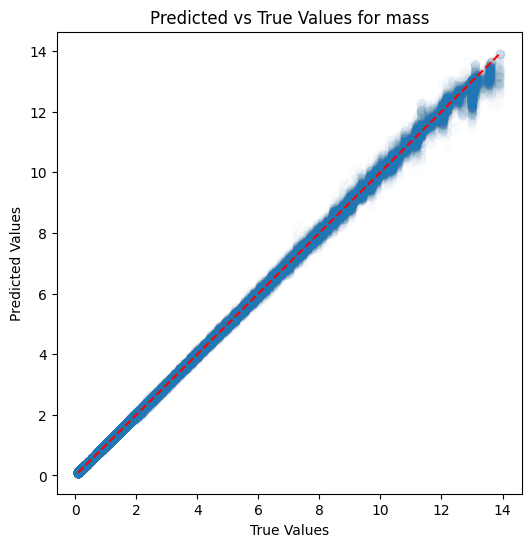

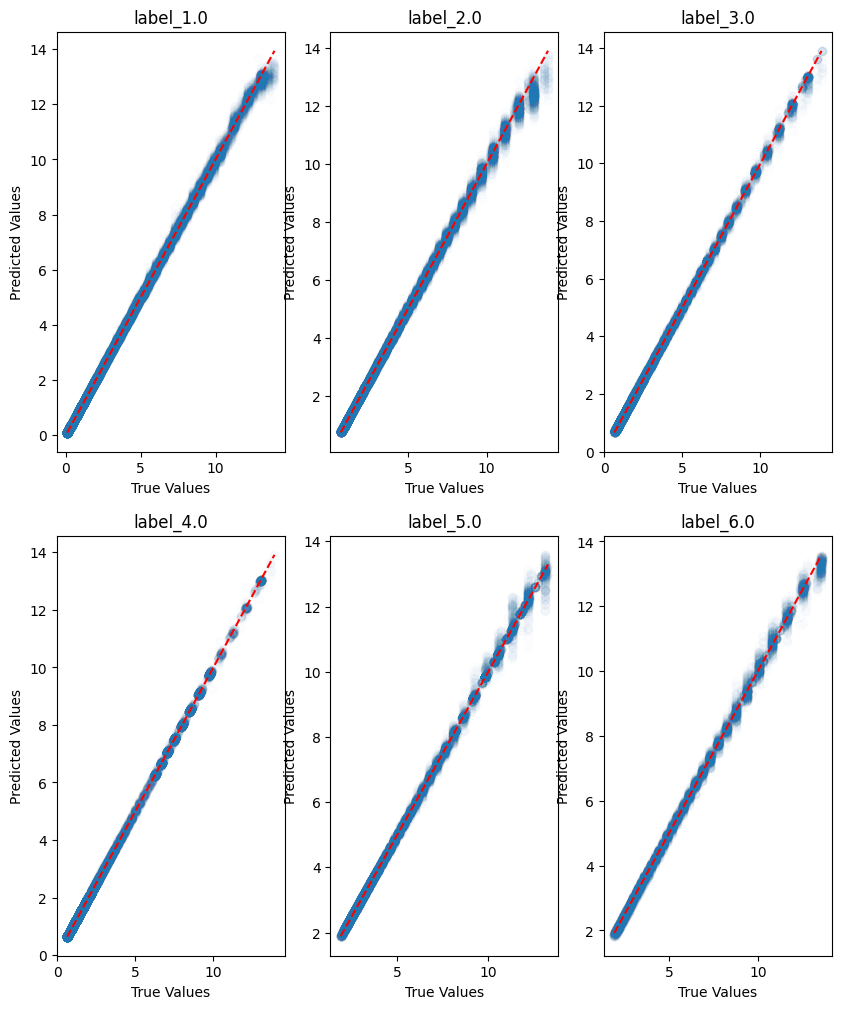

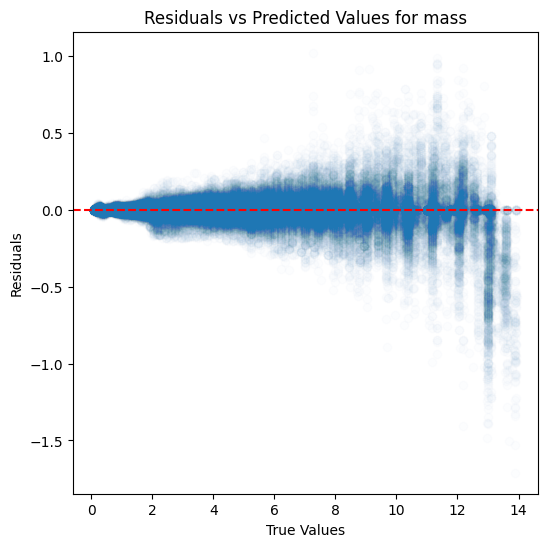

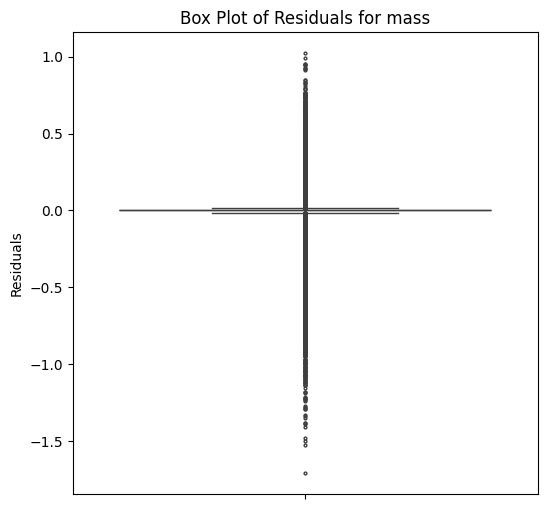

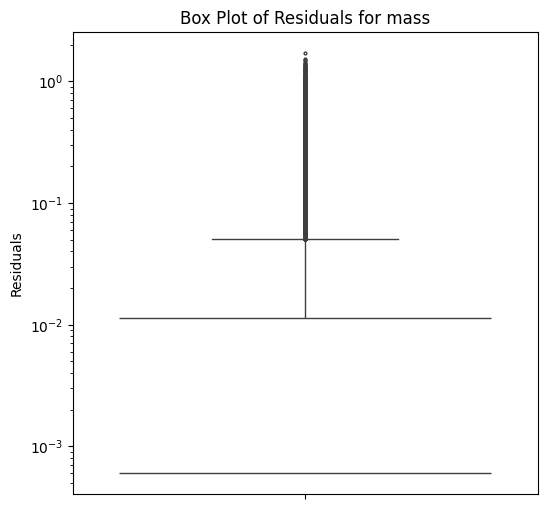

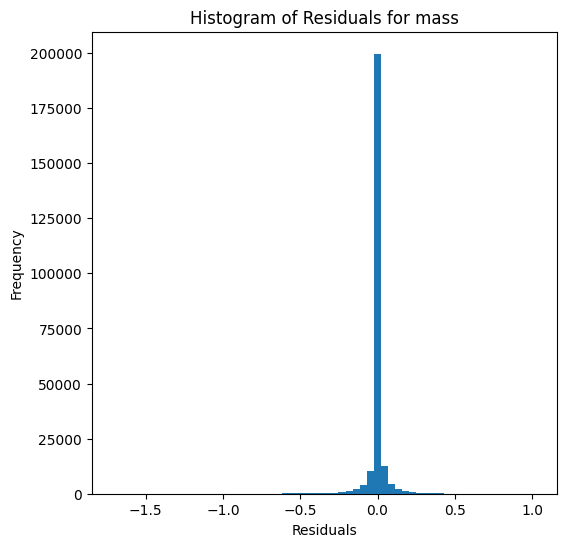

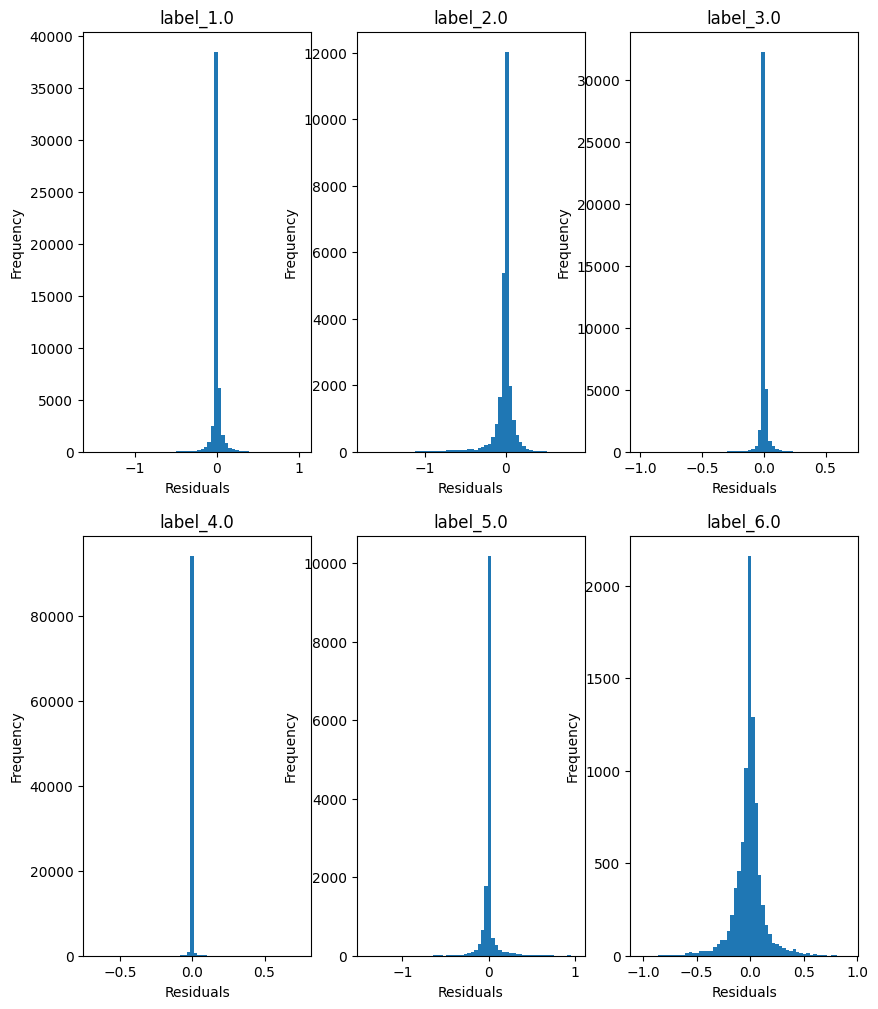

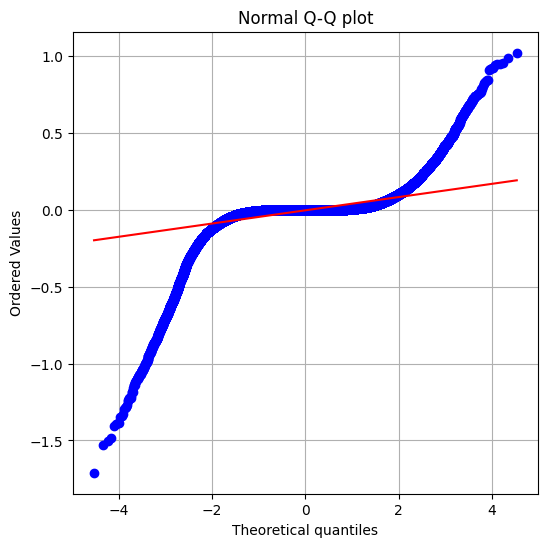

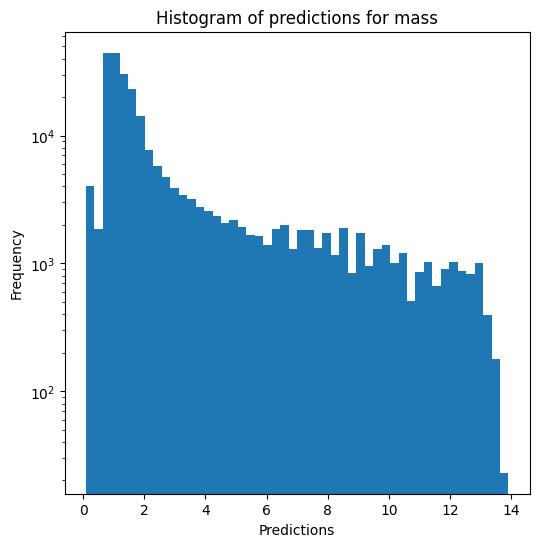

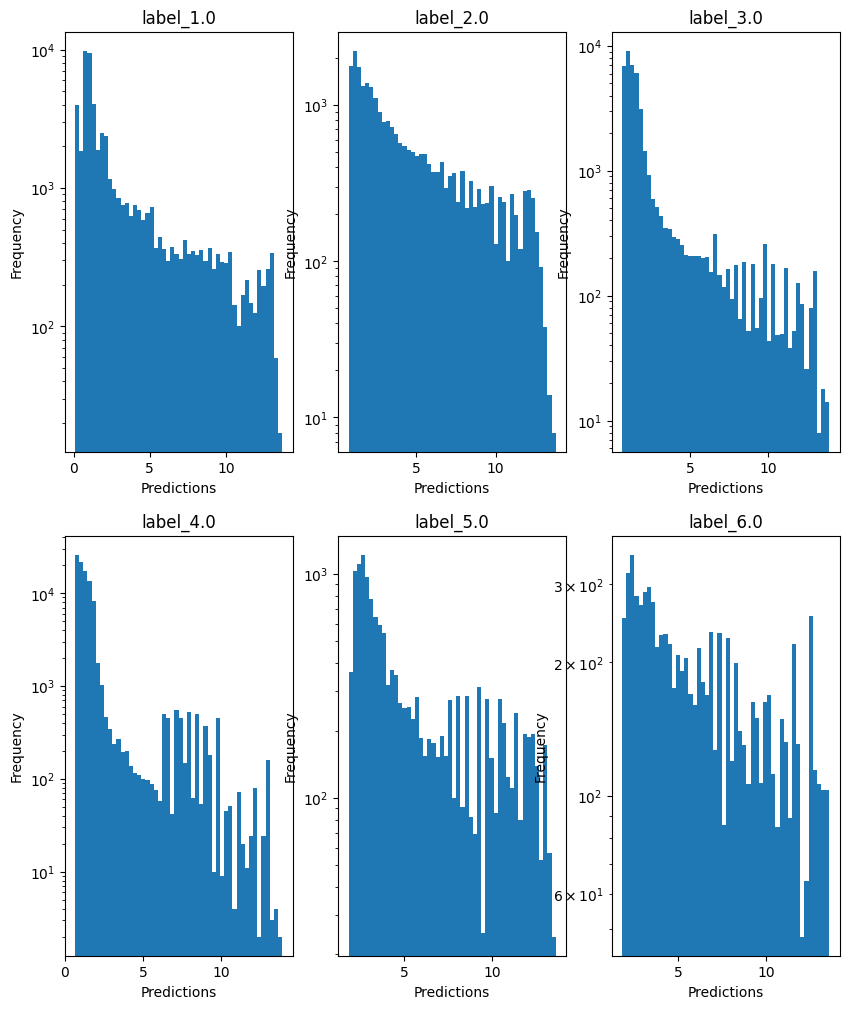

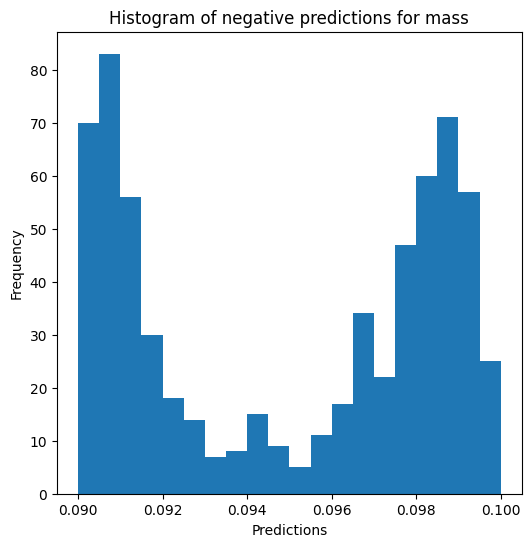


radius results for the label category with a value of 1.0
  value range :  -0.9763360818022064 - 1.1687920203141815
  RVE :  0.9996759032217194
  RMSE :  0.006608507807213548
  MAE :  0.00412829962754537
  MedAE :  0.002323110988540447
  CORR :  0.9998380886912739
  MAX_ER :  0.06126977494378094
  Percentiles : 
    75th percentile :  0.005721914250223441
    90th percentile :  0.010559973153539487
    95th percentile :  0.014413484923543968
    99th percentile :  0.023589351821689135

radius results for the label category with a value of 2.0
  value range :  0.0199466816788423 - 2.458486763798206
  RVE :  0.9995387212017063
  RMSE :  0.011620516890835294
  MAE :  0.00754094377726237
  MedAE :  0.005162918181874643
  CORR :  0.9997765170853631
  MAX_ER :  0.1992574388237216
  Percentiles : 
    75th percentile :  0.009538000616839626
    90th percentile :  0.015938528447280723
    95th percentile :  0.02163824477850824
    99th percentile :  0.03948907042505645

radius results for the

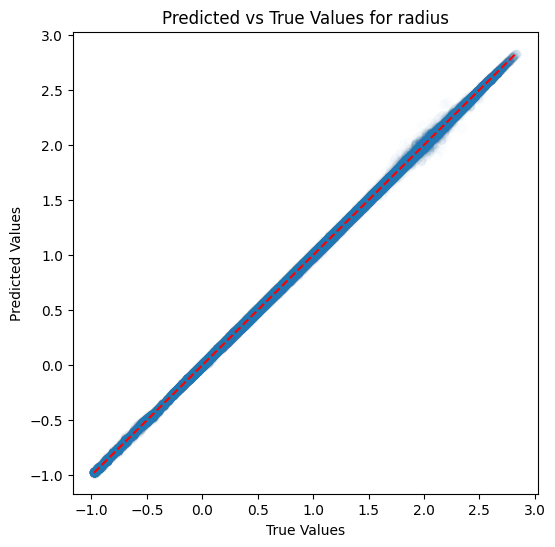

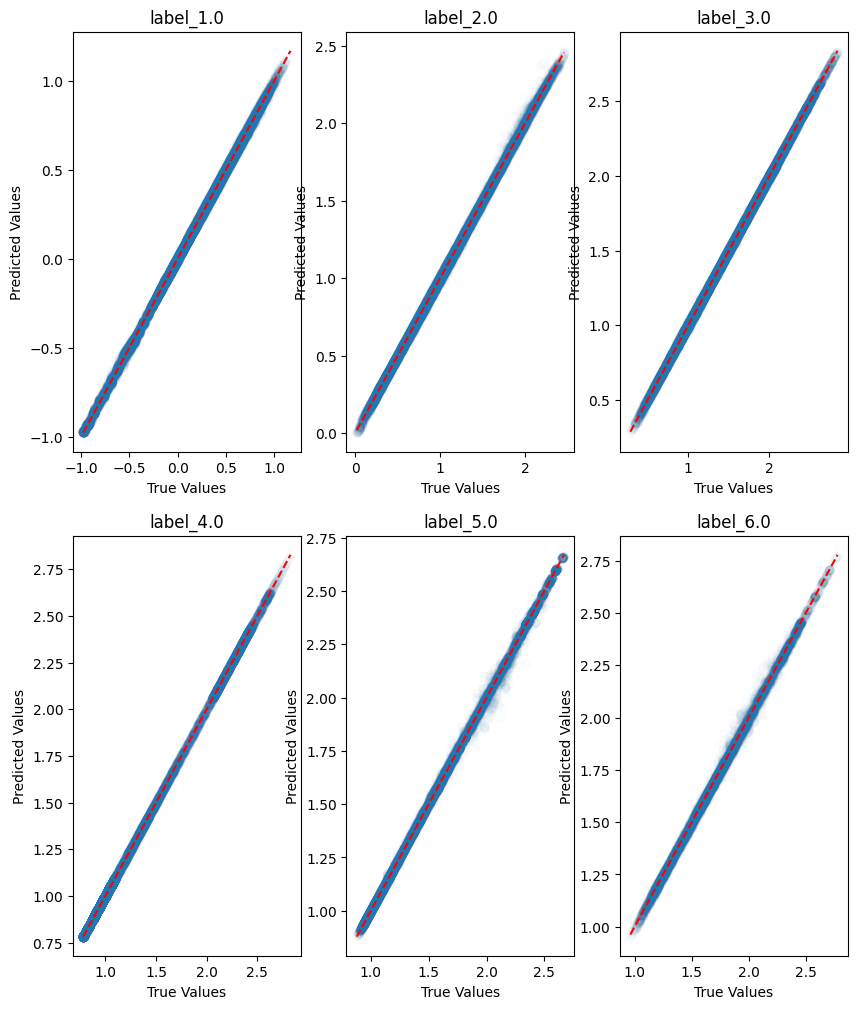

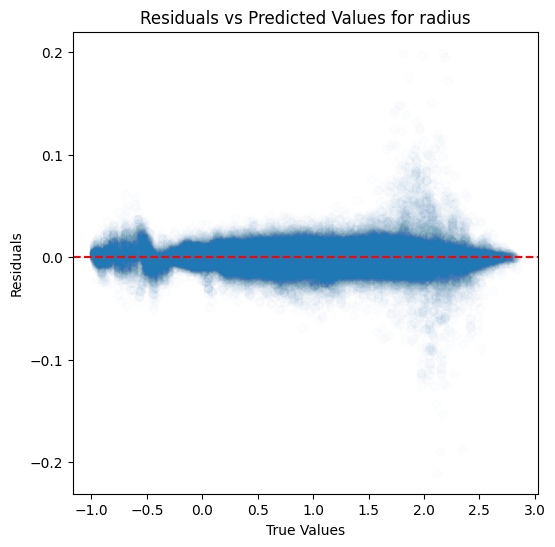

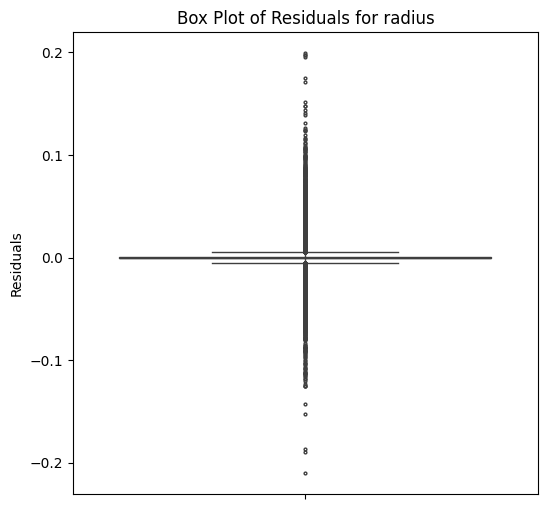

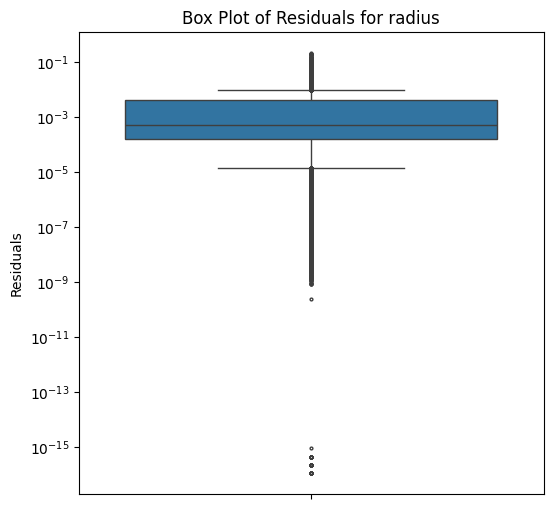

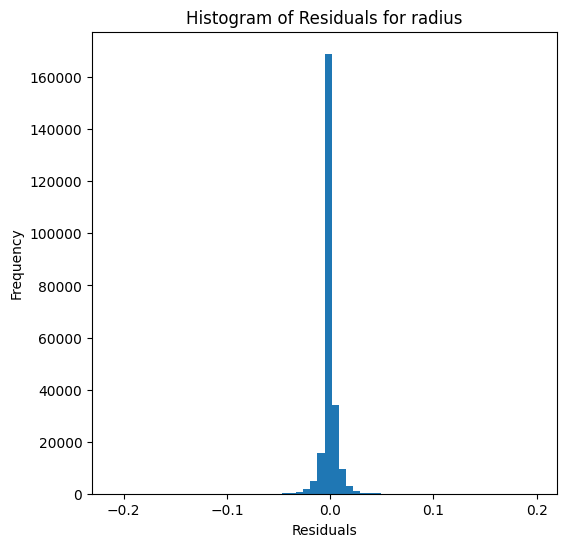

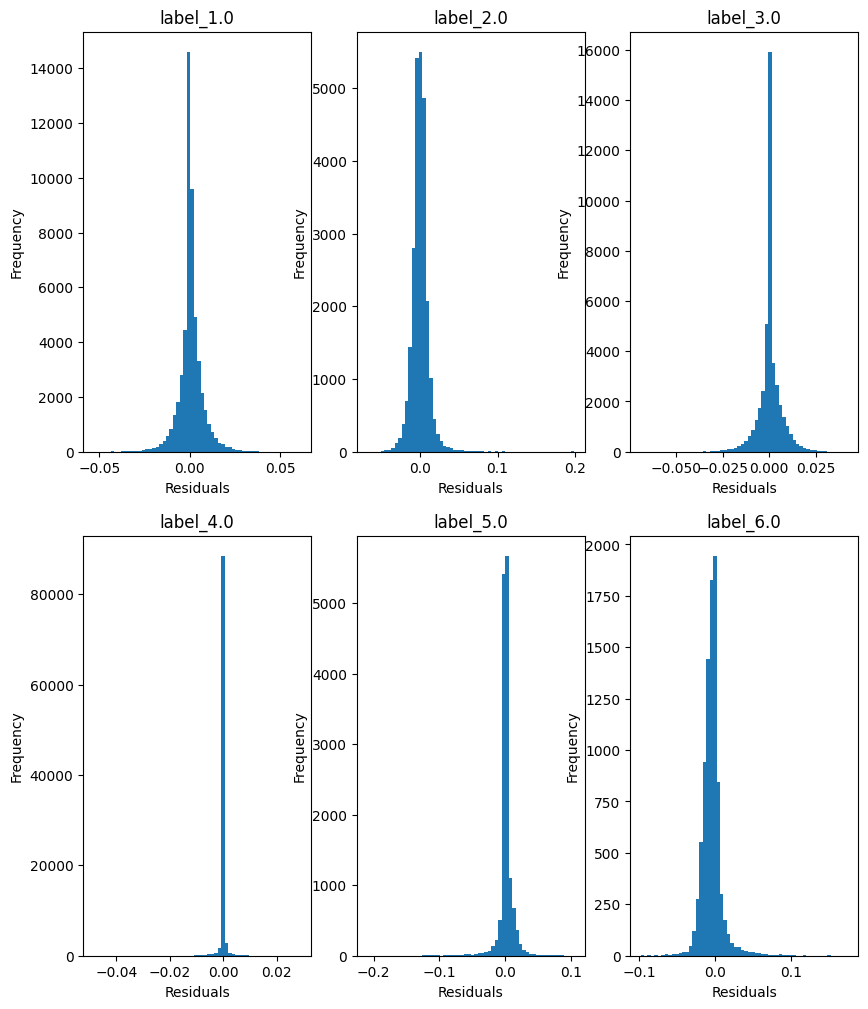

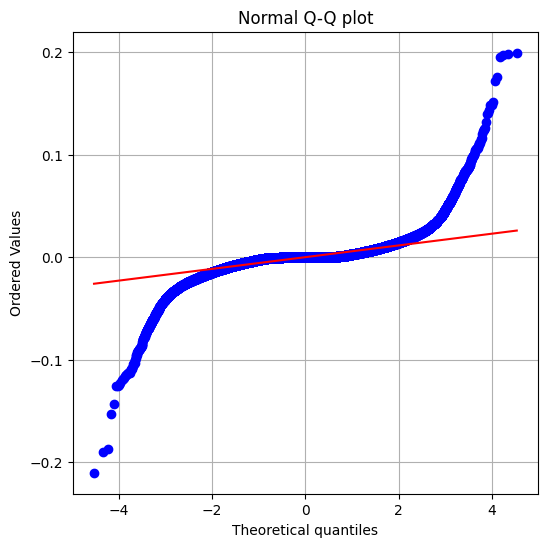

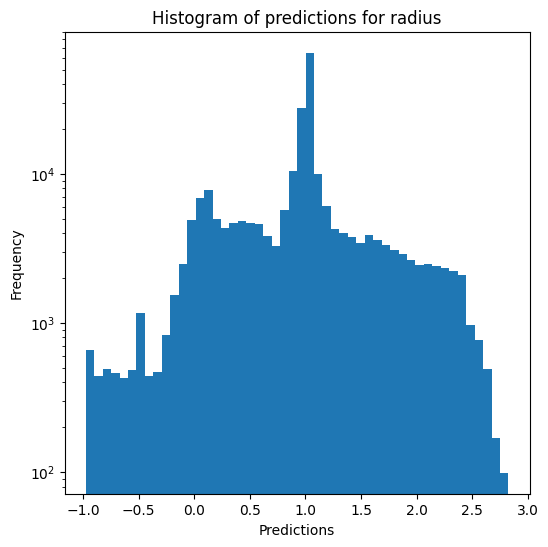

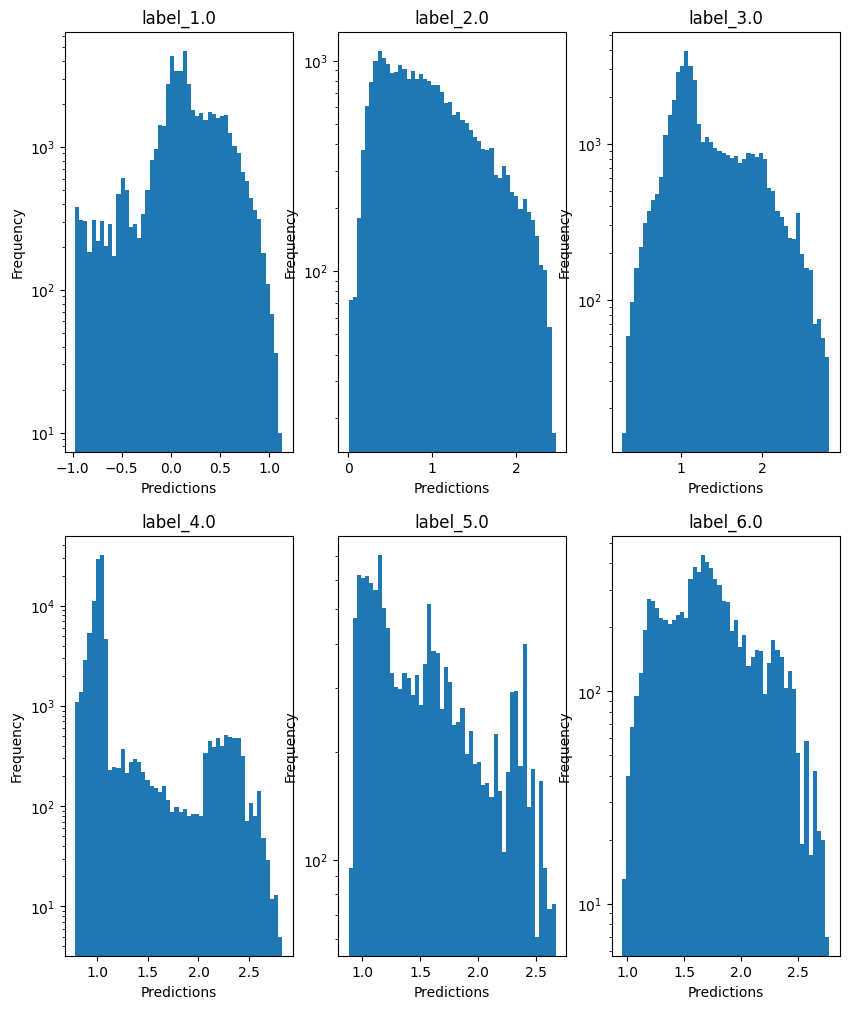

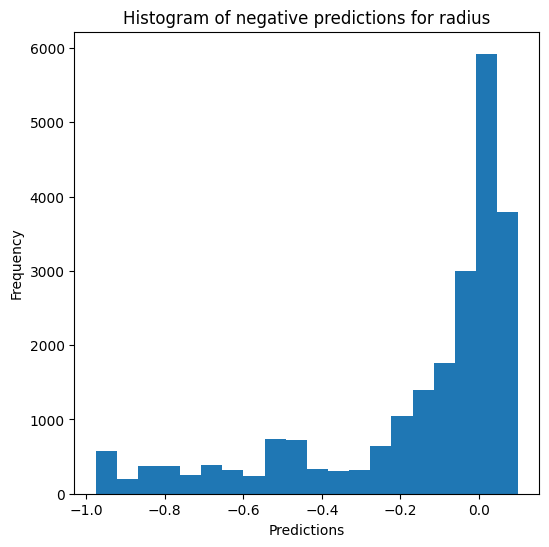

Saving predictions and results...


In [57]:
best_params_KNN = {'n_jobs':10, 'algorithm': 'kd_tree', 'leaf_size': 100, 'n_neighbors': 5, 'p': 1.3, 'weights': 'distance'}

print(path_to_results)
dt_evaluator = Model_evaluator("KNN", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)
dt_evaluator.evaluate_Kfold_results(KNeighborsRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name="standard", **best_params_KNN)